# XGBoost Multilabel Cascade Prediction
**Binary Relevance with `scale_pos_weight` for class imbalance**

This notebook trains one XGBoost binary classifier per cascade label and provides
visibility into every stage: data exploration, class imbalance, training curves,
feature importance, threshold tuning, and final evaluation.

In [5]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from xgboost import XGBClassifier

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, hamming_loss, jaccard_score,
    precision_recall_curve, confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

%matplotlib inline

In [6]:
# ── Feature Toggle ──────────────────────────────────────────────────
# Set to True to EXCLUDE p(secondary | primary) features and
# total_cascade_probability. This lets you compare feature importance
# with and without these engineered conditional-probability features.
EXCLUDE_CASCADE_PROB_FEATURES = True

## 1. Load Prepared Data

In [7]:
DATA_DIR = Path('../data/chronological_prepared_data')

X_train = np.load(DATA_DIR / 'X_train.npy')
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy')

with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

feature_names = metadata['feature_names']
target_names  = metadata['target_names']

print(f"Train : {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Test  : {X_test.shape[0]:,}  samples")
print(f"Labels: {len(target_names)}")
print(f"Split : {metadata.get('split_type', 'unknown')}")


# ── Optionally remove cascade-probability features ──────────────────
if EXCLUDE_CASCADE_PROB_FEATURES:
    keep_mask = []
    removed = []
    for i, name in enumerate(feature_names):
        if (name.startswith('p_') and name.endswith('_given_primary')) or name == 'total_cascade_probability':
            removed.append(name)
            keep_mask.append(False)
        else:
            keep_mask.append(True)
    keep_mask = np.array(keep_mask)
    X_train = X_train[:, keep_mask]
    X_test  = X_test[:, keep_mask]
    feature_names = [n for n, k in zip(feature_names, keep_mask) if k]
    print(f"\n⚠ Excluded {len(removed)} cascade-probability features:")
    for r in removed:
        print(f"  - {r}")
    print(f"Remaining features: {len(feature_names)}")

Train : 773,952 samples, 165 features
Test  : 193,489  samples
Labels: 16
Split : chronological

⚠ Excluded 30 cascade-probability features:
  - p_Avalanche_given_primary
  - p_Blizzard_given_primary
  - p_Coastal_Flood_given_primary
  - p_Cold_Wind_Chill_given_primary
  - p_Debris_Flow_given_primary
  - p_Dense_Fog_given_primary
  - p_Dust_Storm_given_primary
  - p_Excessive_Heat_given_primary
  - p_Extreme_Cold_Wind_Chill_given_primary
  - p_Flash_Flood_given_primary
  - p_Flood_given_primary
  - p_Frost_Freeze_given_primary
  - p_Hail_given_primary
  - p_Heat_given_primary
  - p_Heavy_Rain_given_primary
  - p_Heavy_Snow_given_primary
  - p_High_Surf_given_primary
  - p_High_Wind_given_primary
  - p_Ice_Storm_given_primary
  - p_Lightning_given_primary
  - p_Marine_Hail_given_primary
  - p_Marine_Thunderstorm_Wind_given_primary
  - p_Rip_Current_given_primary
  - p_Storm_Surge_Tide_given_primary
  - p_Thunderstorm_Wind_given_primary
  - p_Tornado_given_primary
  - p_Waterspout_given_

## 2. Explore Label Distributions & Class Imbalance
Understanding how skewed each label is drives the choice of `scale_pos_weight`.

The bar chart below shows the prevalence of each secondary cascade label in the training set.
Labels with very low prevalence (< 1%) are particularly challenging: classifiers tend to predict
the majority class, so we use `scale_pos_weight` to up-weight the rare positives during training.
**Look for**: how many labels are severely imbalanced (> 100:1 ratio), and which labels dominate.

In [8]:
train_counts = y_train.sum(axis=0)
test_counts  = y_test.sum(axis=0)
train_total  = y_train.shape[0]
test_total   = y_test.shape[0]

label_df = pd.DataFrame({
    'label': target_names,
    'train_pos': train_counts.astype(int),
    'test_pos':  test_counts.astype(int),
    'train_pct': train_counts / train_total * 100,
    'test_pct':  test_counts / test_total * 100,
    'imbalance_ratio': (train_total - train_counts) / np.maximum(train_counts, 1)
}).sort_values('train_pos', ascending=False).reset_index(drop=True)

label_df.style.format({
    'train_pos': '{:,.0f}', 'test_pos': '{:,.0f}',
    'train_pct': '{:.2f}%', 'test_pct': '{:.2f}%',
    'imbalance_ratio': '{:.1f}:1'
}).bar(subset=['train_pct'], color='#5fba7d')

,label,train_pos,test_pos,train_pct,test_pct,imbalance_ratio
0,Thunderstorm Wind,"38,123","9,688",4.93%,5.01%,19.3:1
1,Hail,"37,092","9,749",4.79%,5.04%,19.9:1
2,Flash Flood,"34,048","9,973",4.40%,5.15%,21.7:1
3,Flood,"8,760","1,869",1.13%,0.97%,87.4:1
4,Tornado,"8,409","3,125",1.09%,1.62%,91.0:1
5,Lightning,"5,386","1,101",0.70%,0.57%,142.7:1
6,Excessive Heat,"2,212","3,070",0.29%,1.59%,348.9:1
7,Heat,"1,788","2,406",0.23%,1.24%,431.9:1
8,Extreme Cold/Wind Chill,"1,517",169,0.20%,0.09%,509.2:1
9,Debris Flow,"1,277",292,0.16%,0.15%,605.1:1


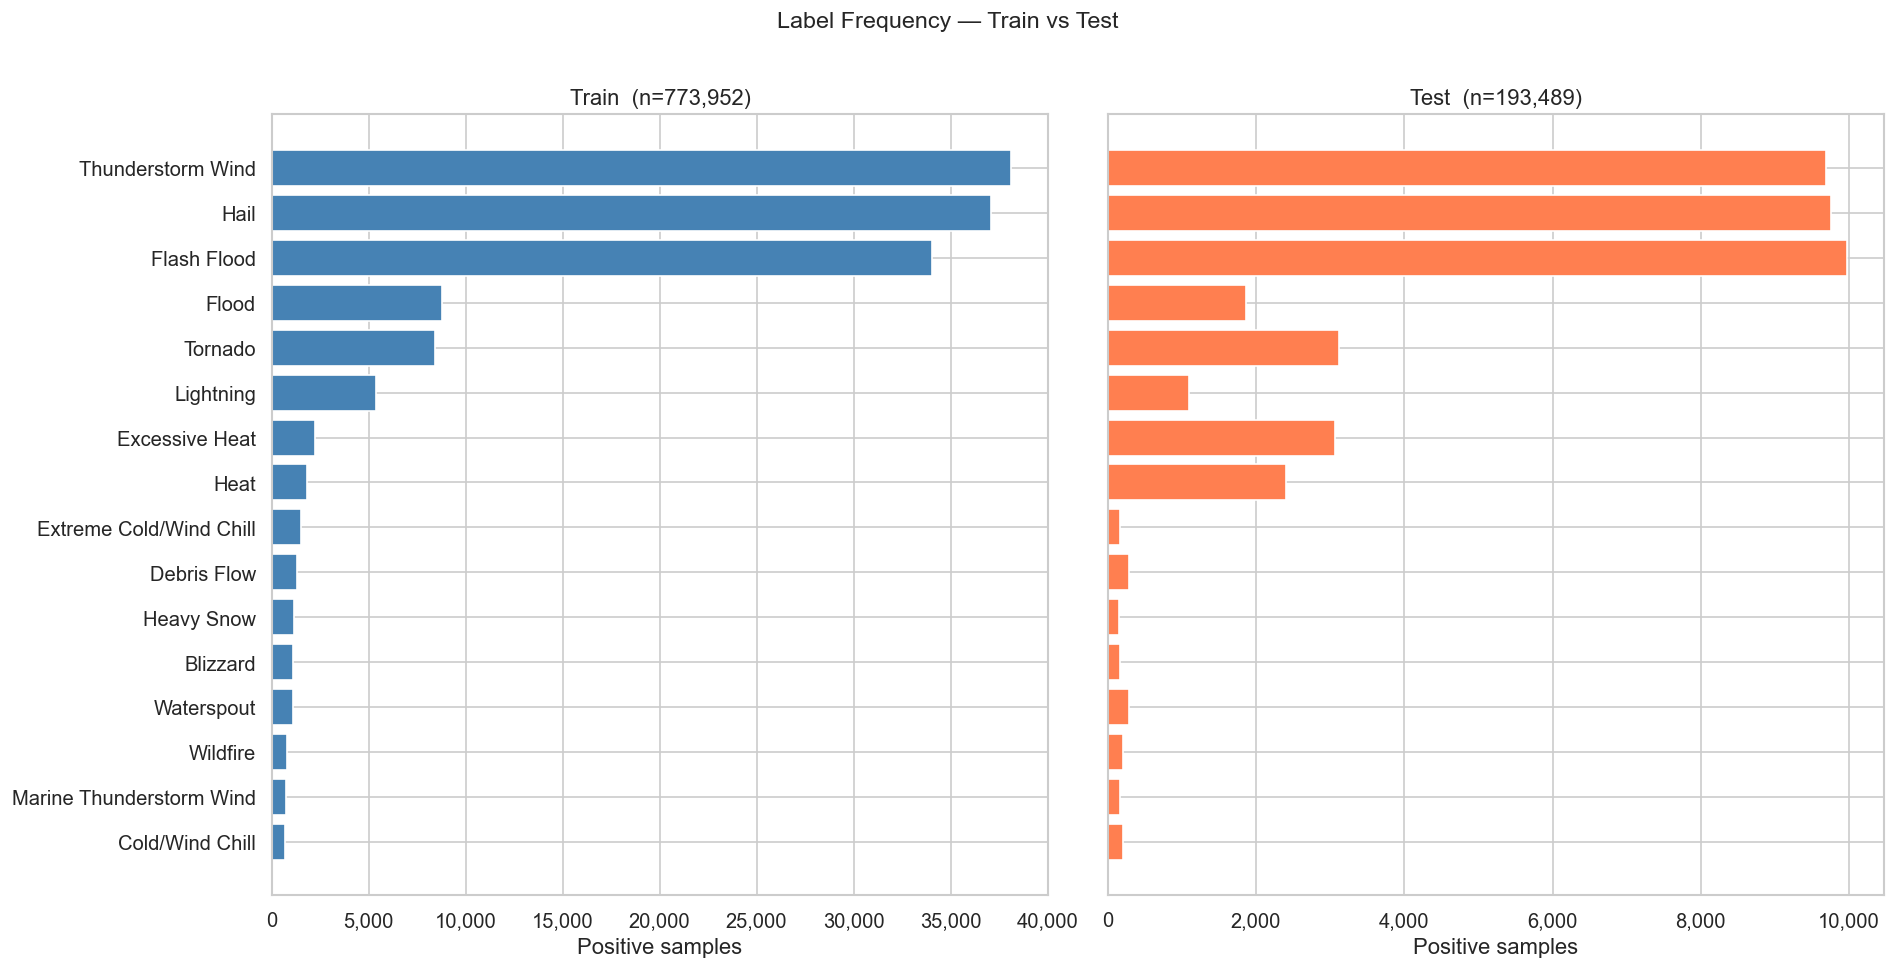

In [9]:
# --- Label frequency: train vs test side-by-side ---
sorted_df = label_df.sort_values('train_pos', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

axes[0].barh(sorted_df['label'], sorted_df['train_pos'], color='steelblue')
axes[0].set_xlabel('Positive samples')
axes[0].set_title(f'Train  (n={train_total:,})')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].barh(sorted_df['label'], sorted_df['test_pos'], color='coral')
axes[1].set_xlabel('Positive samples')
axes[1].set_title(f'Test  (n={test_total:,})')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('Label Frequency — Train vs Test', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

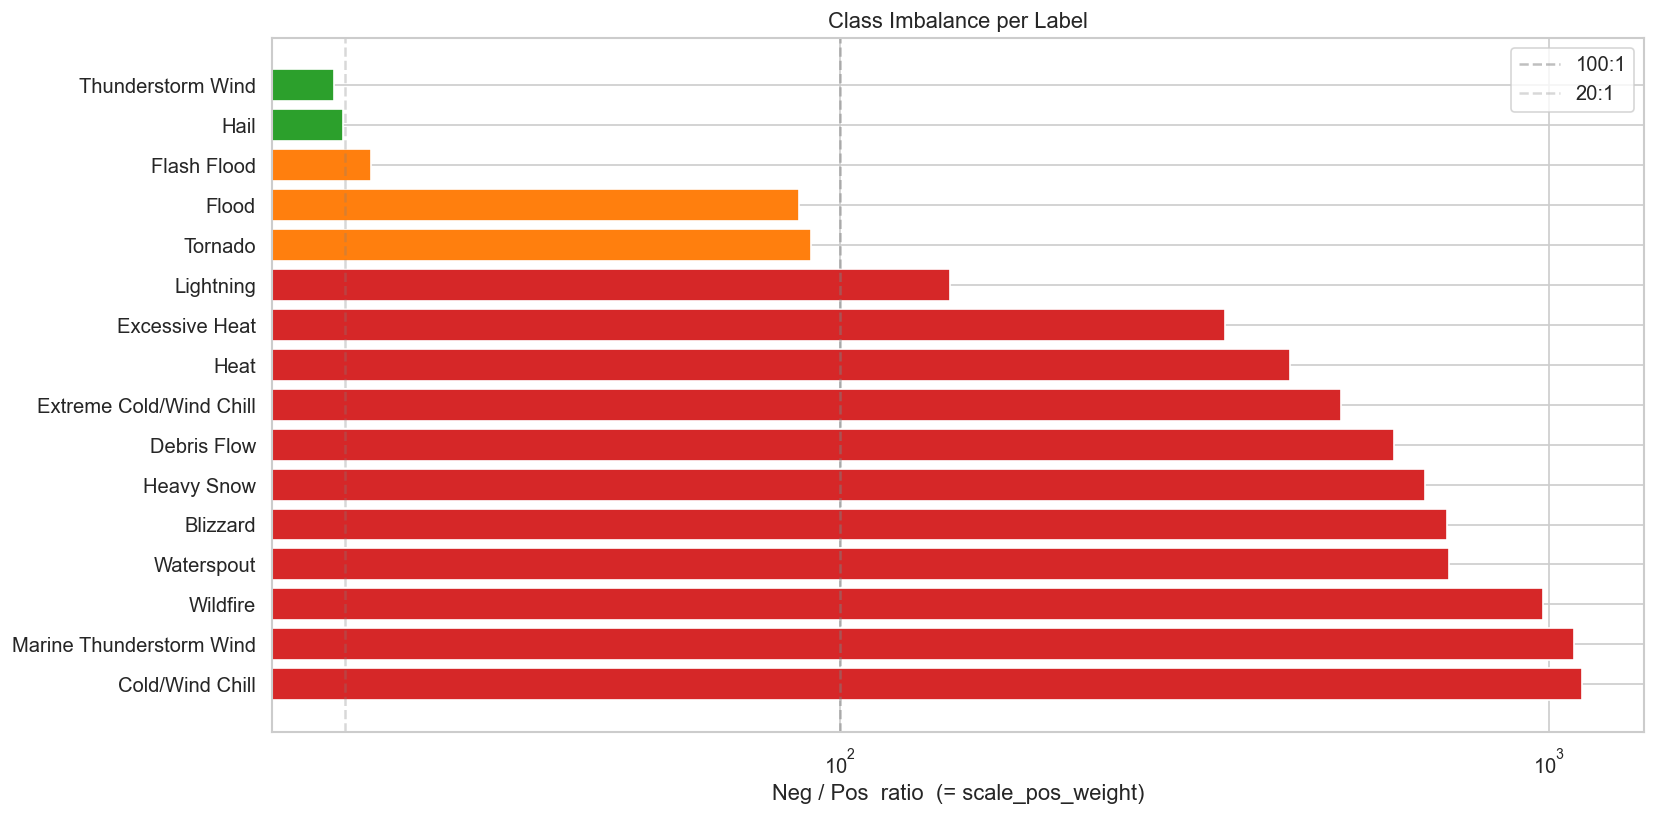

In [10]:
# --- Imbalance ratio (= scale_pos_weight that will be used) ---
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#d62728' if r > 100 else '#ff7f0e' if r > 20 else '#2ca02c'
          for r in sorted_df['imbalance_ratio']]
ax.barh(sorted_df['label'], sorted_df['imbalance_ratio'], color=colors)
ax.set_xlabel('Neg / Pos  ratio  (= scale_pos_weight)')
ax.set_title('Class Imbalance per Label')
ax.set_xscale('log')
ax.axvline(x=100, ls='--', color='gray', alpha=.5, label='100:1')
ax.axvline(x=20,  ls='--', color='gray', alpha=.3, label='20:1')
ax.legend()
plt.tight_layout()
plt.show()

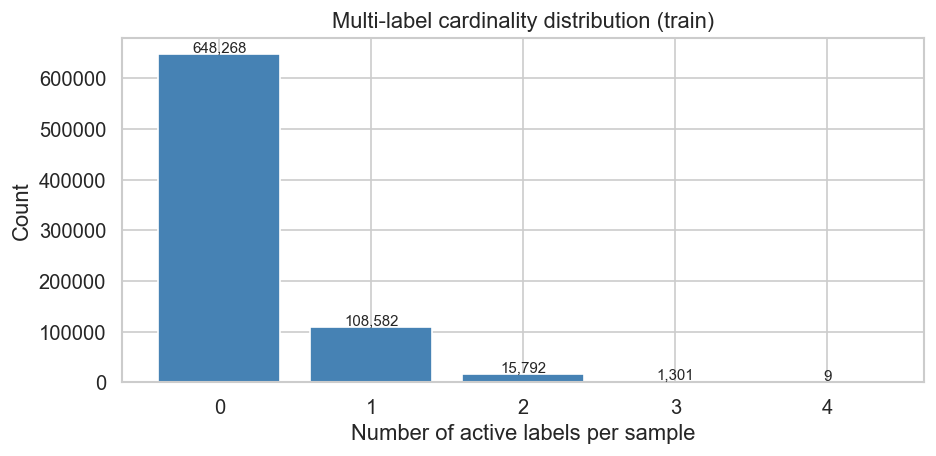

Mean labels per sample: 0.19
Samples with 0 labels : 648,268  (83.8%)


In [11]:
# --- Multi-label co-occurrence ---
labels_per_sample = y_train.sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
counts = pd.Series(labels_per_sample).value_counts().sort_index()
ax.bar(counts.index.astype(int), counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of active labels per sample')
ax.set_ylabel('Count')
ax.set_title('Multi-label cardinality distribution (train)')
for i, (x, v) in enumerate(zip(counts.index, counts.values)):
    ax.text(x, v + train_total * 0.005, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Mean labels per sample: {labels_per_sample.mean():.2f}")
print(f"Samples with 0 labels : {(labels_per_sample == 0).sum():,}  "
      f"({(labels_per_sample == 0).mean()*100:.1f}%)")

## 3. Hyperparameter Tuning + Training

**Approach**: Quick randomized search on the top-2 labels (most training
positives), then train all labels with the best-found hyperparameters.

**Key design decisions:**
- **Chronological val split**: The last 10% of training data forms the
  validation set — strictly after the training period, no future leakage.
- **Capped SPW**: `scale_pos_weight = min(n_neg/n_pos, 30)` prevents
  over-prediction of rare labels.
- Rare labels already filtered in `prepare_data.py` (< 0.05% threshold).
- **Negative subsampling**: For each label, negatives are down-sampled to 5× the
  positives for faster, more balanced training (full data still used for eval).
- **Per-label threshold tuning on val set** — each label gets its own optimal
  threshold that maximises its F1. Never tuned on test data.

**Timeline**: `[--- Train ---][-- Val --][---- Test ----]`

**Note on chronological shift**: The test set covers more recent years where
heat events are significantly more prevalent (Excessive Heat: ~1.8% train
→ ~8.7% test). This is realistic but harder.

In [12]:
from sklearn.model_selection import ParameterSampler

MAX_SPW = 30              # cap scale_pos_weight to avoid over-predicting rare labels
NEG_SUBSAMPLE_RATIO = 5   # keep at most 5× negatives per positive during training

# Shared (fixed) params
FIXED_PARAMS = dict(
    objective='binary:logistic',
    eval_metric=['logloss', 'aucpr'],
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
)

# Hyperparameter search grid
PARAM_GRID = {
    'max_depth':        [4, 5, 6, 7, 8],
    'learning_rate':    [0.01, 0.05, 0.1],
    'n_estimators':     [300, 500],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.7, 0.8],
    'min_child_weight': [1, 5, 10],
    'gamma':            [0.0, 1.0, 2.0],
    'reg_alpha':        [0.0, 0.1, 1.0],
    'reg_lambda':       [1.0, 2.0, 5.0],
}

N_SEARCH_ITER = 12  # fast search

In [13]:
# --- Chronological validation split (tail-end of training data) ---
# Since prepare_data already sorted train chronologically, the last 10%
# of X_train IS the most recent slice — no future leakage possible.
val_size = 0.1
split_idx = int(len(X_train) * (1 - val_size))

X_tr  = X_train[:split_idx]
y_tr  = y_train[:split_idx]
X_val = X_train[split_idx:]
y_val = y_train[split_idx:]

print(f"Training   : {X_tr.shape[0]:,}  (earliest events)")
print(f"Validation : {X_val.shape[0]:,}  (tail-end of train period)")
print(f"Test       : {X_test.shape[0]:,}  (most recent events)")
print(f"Features   : {X_tr.shape[1]}")
print(f"\nTimeline:  [--- Train ---][-- Val --][---- Test ----]")
print(f"           No data leakage: val & test are strictly after train.")

Training   : 696,556  (earliest events)
Validation : 77,396  (tail-end of train period)
Test       : 193,489  (most recent events)
Features   : 135

Timeline:  [--- Train ---][-- Val --][---- Test ----]
           No data leakage: val & test are strictly after train.


In [16]:
import time, json

if EXCLUDE_CASCADE_PROB_FEATURES:
    MODEL_DIR = Path('../models/baseline/xgb_models_no_cascade_prob')
else:
    MODEL_DIR = Path('../models/baseline/xgb_models')
CHECKPOINT = MODEL_DIR / '_checkpoint.pkl'


# ── Helper: sanitize label name for filesystem ────────────────────────
def sanitize_label(label):
    """Replace path-problematic characters in label names."""
    return label.replace('/', '_').replace('\\', '_').replace(':', '_')

def unsanitize_label(sanitized):
    """Reverse mapping: this is used when loading from checkpoint."""
    return sanitized  # For now, we store mappings in checkpoint metadata

# ── Helper: subsample negatives for a single label ─────────────────────
def subsample_negatives(X, y_col, ratio=NEG_SUBSAMPLE_RATIO, seed=42):
    """Keep all positives + up to `ratio` × n_pos negatives."""
    pos_idx = np.where(y_col == 1)[0]
    neg_idx = np.where(y_col == 0)[0]
    n_keep = min(len(neg_idx), ratio * len(pos_idx))
    rng = np.random.RandomState(seed)
    neg_keep = rng.choice(neg_idx, size=int(n_keep), replace=False)
    keep = np.sort(np.concatenate([pos_idx, neg_keep]))
    return X[keep], y_col[keep]

# ── Try loading cached models ──────────────────────────────────────────
if CHECKPOINT.exists():
    print(f"Found checkpoint at {CHECKPOINT}")
    with open(CHECKPOINT, 'rb') as f:
        ckpt = pickle.load(f)
    best_params       = ckpt['best_params']
    training_summary  = ckpt['training_summary']
    eval_histories    = ckpt['eval_histories']
    trainable         = ckpt['trainable']
    label_map         = ckpt.get('label_map', {})  # maps sanitized -> original
    
    # -- Verify consistency with current data --
    ckpt_labels = [t[1] for t in trainable]
    if len(ckpt_labels) != len(target_names) or set(ckpt_labels) != set(target_names):
        print(f"  ⚠️ Warning: Checkpoint labels ({len(ckpt_labels)}) do not match current data ({len(target_names)})")
        print("  Ignoring cached checkpoint and retraining to avoid index errors.")
        # Reset state to force 'else' block or cautious loading
        # For simplicity, we can just delete 'ckpt' variable or set a flag
        # But here we'll just force retraining by making the code skip this block
        # Actually, let's just update 'trainable' to match current target_names indices
        trainable = [(i, label, int(y_tr[:, i].sum())) for i, label in enumerate(target_names)]
        print(f"  (Refreshed 'trainable' list with current {len(trainable)} labels)")

    models = {}
    for model_file in sorted(MODEL_DIR.glob('*.pkl')):
        if model_file.name.startswith('_'): continue
        sanitized = model_file.stem
        with open(model_file, 'rb') as f:
            models[sanitized] = pickle.load(f)

    print(f"  Loaded {len(models)} cached models — skipping training.")
    print(f"  Loaded per-label best params for {len(best_params)} labels.")
    print(f"  (Delete {MODEL_DIR}/ to retrain from scratch)\n")

else:
    # ── Step 1: Identify trainable labels ──────────────────────────────
    # All labels are trainable (rare labels already dropped in prepare_data.py)
    trainable = [(i, label, int(y_tr[:, i].sum())) for i, label in enumerate(target_names)]
    print(f"Trainable labels: {len(trainable)} / {len(target_names)}") 

    # ── Step 2+3: Per-label HP search + training ──────────────────────────
    sampled_params = list(ParameterSampler(PARAM_GRID, n_iter=N_SEARCH_ITER, random_state=42))

    models = {}
    eval_histories = {}
    training_summary = []
    label_map = {}
    best_params = {}  # dict: label -> best HP dict

    n_total_tr = len(y_tr)
    print(f"\nPer-label HP search ({N_SEARCH_ITER} configs each) + training")
    print(f"  Negative subsampling ratio: {NEG_SUBSAMPLE_RATIO}:1")
    print(f"  Full train set: {n_total_tr:,} rows\n")
    print(f"  {'Label':30s}  {'pos':>6s}  {'best_aucpr':>10s}  {'round':>5s}  {'time':>6s}")
    print("  " + "-" * 70)

    t0_all = time.time()
    for idx, label, n_pos in trainable:
        t0_label = time.time()
        y_i_tr  = y_tr[:, idx]
        y_i_val = y_val[:, idx]

        # ── HP search for this label ──
        best_label_score = -1
        best_label_params = None
        for p in sampled_params:
            X_sub, y_sub = subsample_negatives(X_tr, y_i_tr)
            spw = min(int((y_sub == 0).sum()) / max(int((y_sub == 1).sum()), 1), MAX_SPW)
            clf = XGBClassifier(**p, **FIXED_PARAMS, scale_pos_weight=spw)
            clf.fit(X_sub, y_sub, eval_set=[(X_val, y_i_val)], verbose=False)
            score = clf.evals_result()['validation_0']['aucpr'][clf.best_iteration]
            if score > best_label_score:
                best_label_score = score
                best_label_params = p

        best_params[label] = best_label_params

        # ── Train final model with best params ──
        n_neg_orig = int((y_i_tr == 0).sum())
        X_sub, y_sub = subsample_negatives(X_tr, y_i_tr)
        n_neg_sub = int((y_sub == 0).sum())
        n_pos_sub = int((y_sub == 1).sum())
        spw = min(n_neg_sub / max(n_pos_sub, 1), MAX_SPW)

        model = XGBClassifier(**best_label_params, **FIXED_PARAMS, scale_pos_weight=spw)
        model.fit(
            X_sub, y_sub,
            eval_set=[(X_sub, y_sub), (X_val, y_i_val)],
            verbose=False
        )

        evals = model.evals_result()
        eval_histories[label] = evals
        sanitized = sanitize_label(label)
        models[sanitized] = model
        label_map[sanitized] = label

        best_round = model.best_iteration if hasattr(model, 'best_iteration') else len(evals['validation_1']['aucpr']) - 1
        best_aucpr = evals['validation_1']['aucpr'][best_round]

        training_summary.append(dict(
            label=label, n_pos=n_pos, n_neg_orig=n_neg_orig, n_neg_sub=n_neg_sub,
            n_train_rows=len(y_sub), scale_pos_weight=round(spw, 1),
            best_round=best_round, best_val_aucpr=round(best_aucpr, 4),
            best_hp=best_label_params, status='trained'
        ))

        elapsed_label = time.time() - t0_label
        print(f"  {label:30s}  {n_pos_sub:>6,}  {best_aucpr:>10.4f}  {best_round:>5d}  {elapsed_label:>5.1f}s")

    # Add any labels that were skipped/dropped (status check)
    trained_labels = [label_map[s] for s in models.keys()]
    for idx, label, n_pos in trainable:
        if label not in trained_labels:
            training_summary.append(dict(
                label=label, n_pos=n_pos, n_train_rows=0, 
                scale_pos_weight=None, best_round=None, 
                best_val_aucpr=None, best_hp=None, status='skipped'
            ))

    elapsed_all = time.time() - t0_all
    print(f"\nTrained {len(models)}/{len(target_names)} models in {elapsed_all:.0f}s")

    # ── Save checkpoint and models using pickle ─────────────────────────
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    for sanitized, mdl in models.items():
        with open(MODEL_DIR / f'{sanitized}.pkl', 'wb') as f:
            pickle.dump(mdl, f)

    with open(CHECKPOINT, 'wb') as f:
        pickle.dump({
            'best_params': best_params,
            'training_summary': training_summary,
            'eval_histories': eval_histories,
            'trainable': trainable,
            'label_map': label_map,  # Store mapping of sanitized -> original names
        }, f)
    print(f"  Saved models + checkpoint to {MODEL_DIR}/")


Trainable labels: 16 / 16

Per-label HP search (12 configs each) + training
  Negative subsampling ratio: 5:1
  Full train set: 696,556 rows

  Label                              pos  best_aucpr  round    time
  ----------------------------------------------------------------------
  Blizzard                           893      0.1940     44   67.4s
  Cold/Wind Chill                    664      0.1683     20   49.6s
  Debris Flow                        941      0.4414     67   76.4s
  Excessive Heat                   1,723      0.4828     41   61.9s
  Extreme Cold/Wind Chill          1,357      0.3000     52   45.5s
  Flash Flood                     32,029      0.4332    206  213.5s
  Flood                            8,111      0.4721     93  213.1s
  Hail                            34,133      0.5504    229  301.7s
  Heat                             1,288      0.6835    126   78.8s
  Heavy Snow                       1,031      0.0560    147   43.0s
  Lightning                        5,

In [17]:
summary_df = pd.DataFrame(training_summary)
summary_df.sort_values('best_val_aucpr', ascending=False, na_position='last')

,label,n_pos,n_neg_orig,n_neg_sub,n_train_rows,scale_pos_weight,best_round,best_val_aucpr,best_hp,status
12,Thunderstorm Wind,35227,661329,176135,211362,5.0,69,0.7300,"{'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alp...",trained
8,Heat,1288,695268,6440,7728,5.0,126,0.6835,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",trained
7,Hail,34133,662423,170665,204798,5.0,229,0.5504,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",trained
11,Marine Thunderstorm Wind,640,695916,3200,3840,5.0,149,0.5464,"{'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alp...",trained
14,Waterspout,982,695574,4910,5892,5.0,113,0.5016,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alp...",trained
3,Excessive Heat,1723,694833,8615,10338,5.0,41,0.4828,"{'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alp...",trained
6,Flood,8111,688445,40555,48666,5.0,93,0.4721,"{'subsample': 0.9, 'reg_lambda': 2.0, 'reg_alp...",trained
2,Debris Flow,941,695615,4705,5646,5.0,67,0.4414,"{'subsample': 0.9, 'reg_lambda': 2.0, 'reg_alp...",trained
5,Flash Flood,32029,664527,160145,192174,5.0,206,0.4332,"{'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alp...",trained
4,Extreme Cold/Wind Chill,1357,695199,6785,8142,5.0,52,0.3000,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",trained


## 4. Training Curves
Logloss and AUCPR on train vs. validation across boosting rounds.

**How to interpret**: The gap between training and validation curves indicates overfitting.
If both curves plateau at similar levels, the model generalises well. If the training curve
continues to improve while validation stagnates or degrades, early stopping was correctly applied.
Labels with very few positives may show noisy validation curves.

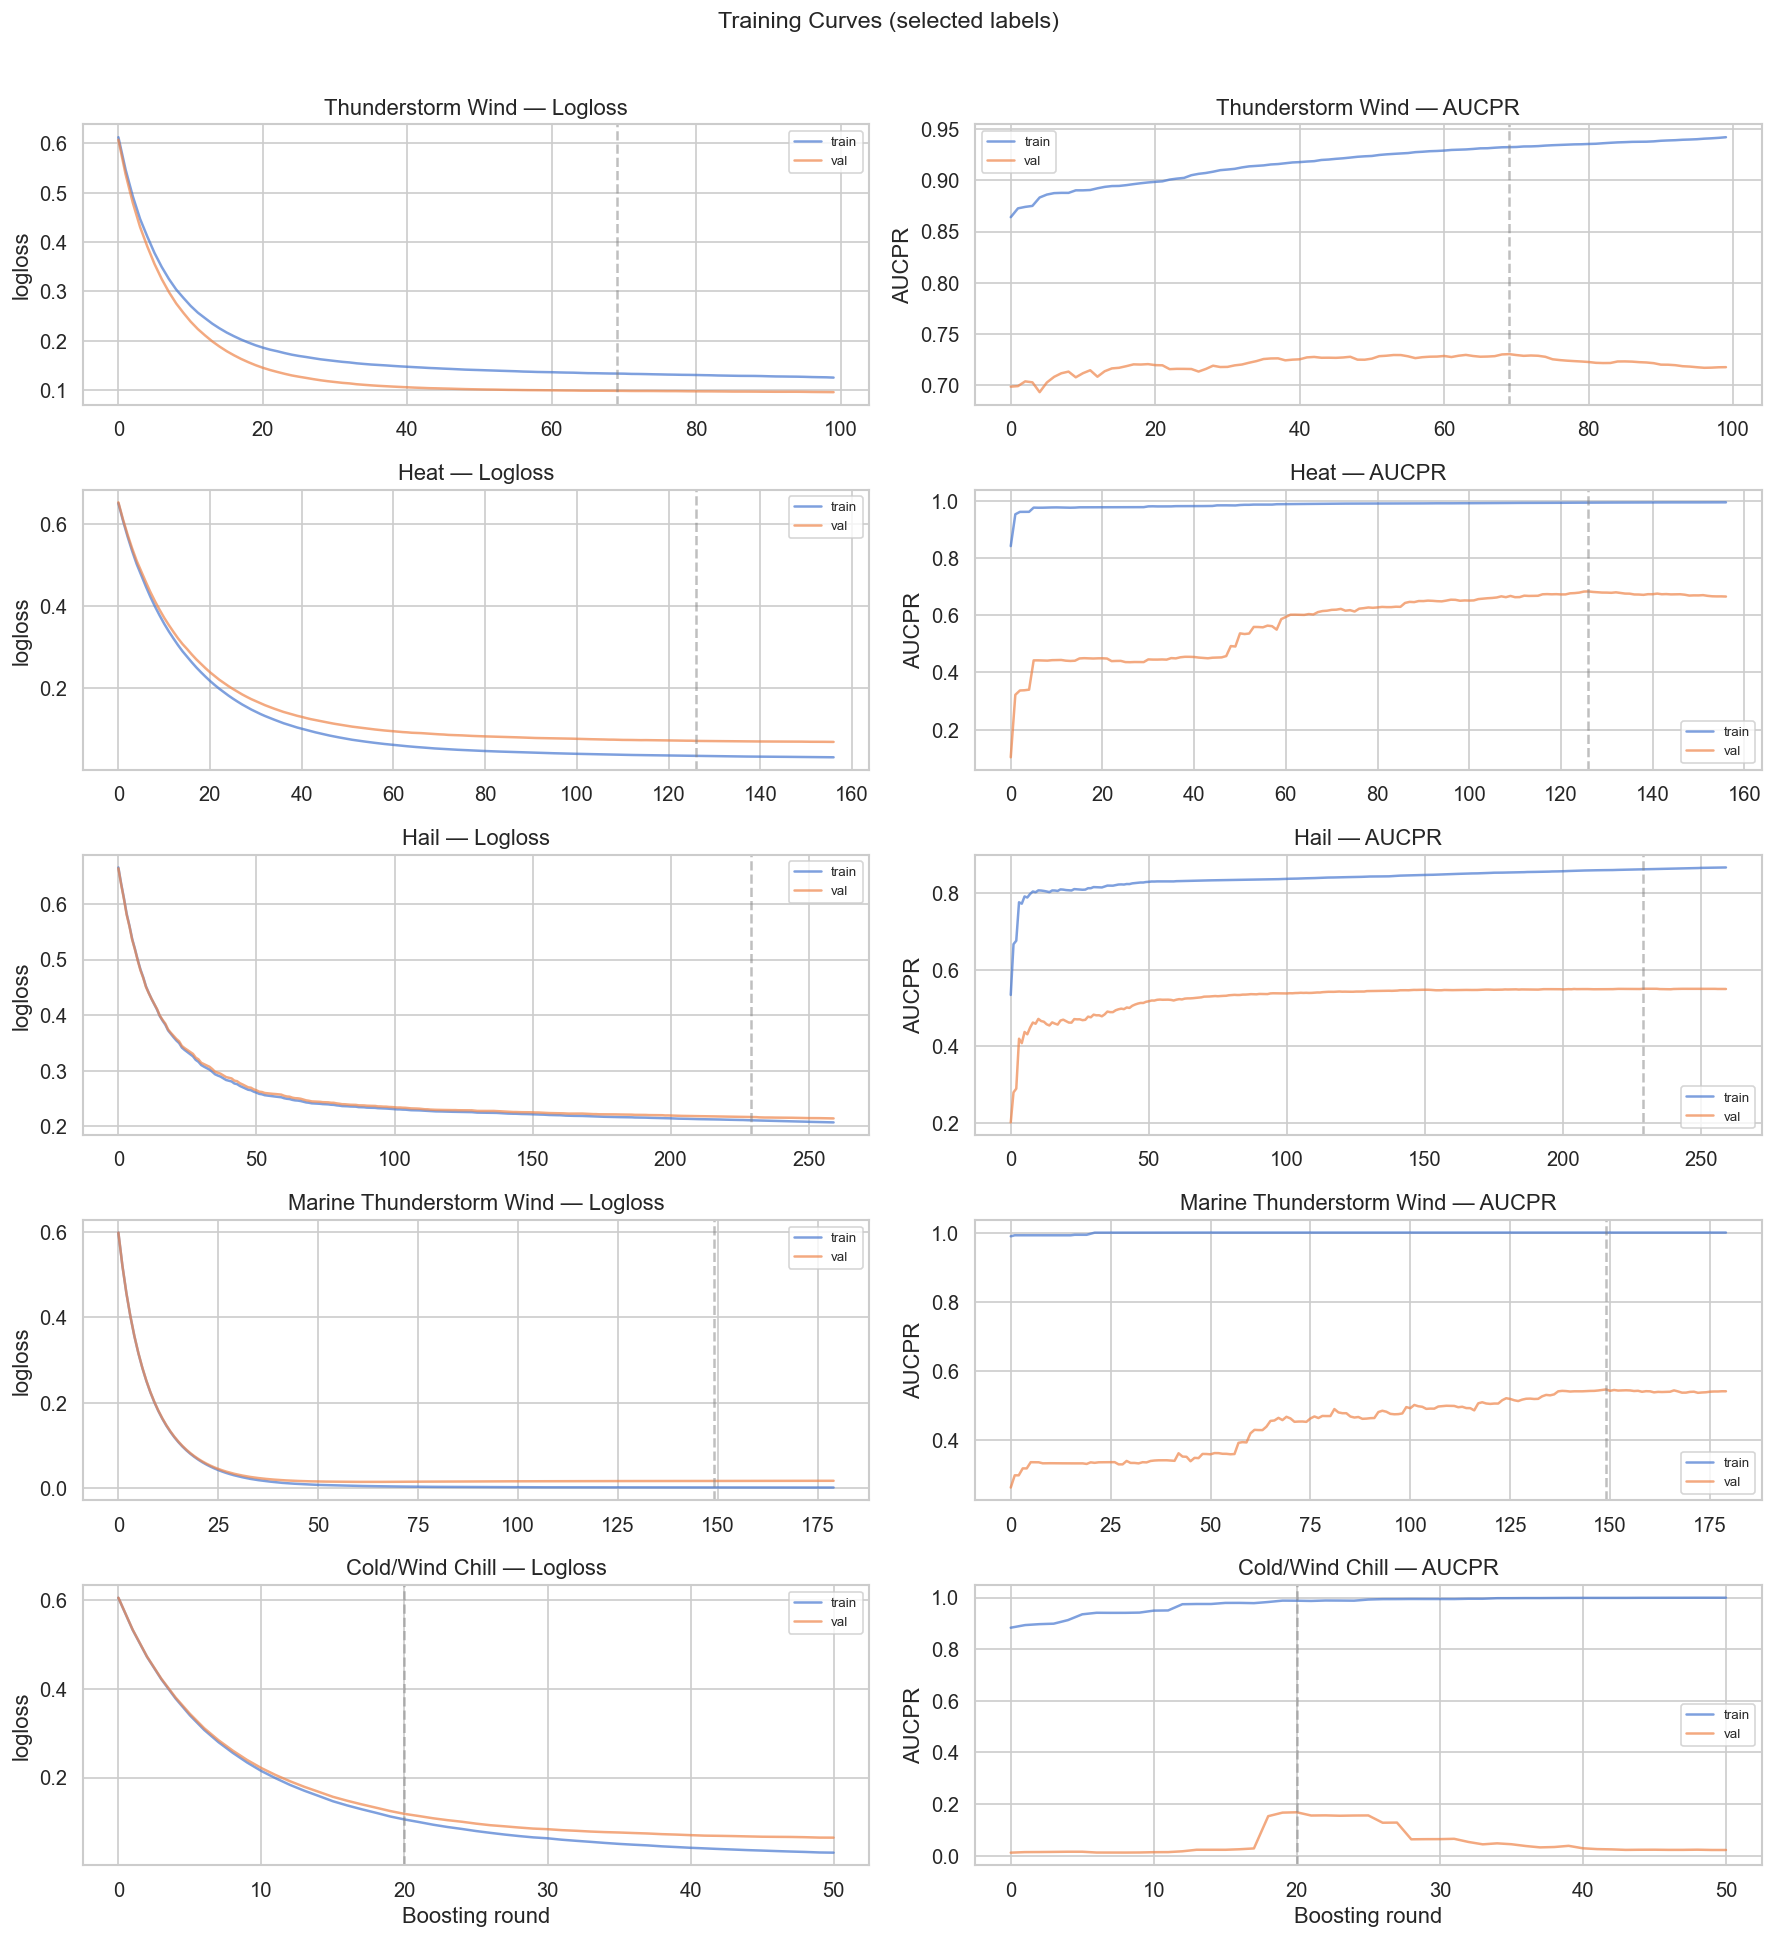

In [18]:
# Pick labels with highest val AUCPR to visualise (plus a few rare ones)
trained = summary_df[summary_df['status'] == 'trained'].copy()
top_labels   = trained.nlargest(4, 'best_val_aucpr')['label'].tolist()
rare_labels  = trained.nsmallest(2, 'n_pos')['label'].tolist()
plot_labels  = list(dict.fromkeys(top_labels + rare_labels))  # dedupe, keep order

n = len(plot_labels)
fig, axes = plt.subplots(n, 2, figsize=(15, 3.2 * n), sharex=False)
if n == 1:
    axes = axes.reshape(1, -1)

for row, label in enumerate(plot_labels):
    h = eval_histories[label]
    rounds = np.arange(len(h['validation_0']['logloss']))
    best_r = summary_df.loc[summary_df['label'] == label, 'best_round'].values[0]

    # Logloss
    ax = axes[row, 0]
    ax.plot(rounds, h['validation_0']['logloss'], label='train', alpha=.7)
    ax.plot(rounds, h['validation_1']['logloss'], label='val', alpha=.7)
    ax.axvline(best_r, ls='--', color='gray', alpha=.5)
    ax.set_ylabel('logloss')
    ax.set_title(f'{label} — Logloss')
    ax.legend(fontsize=8)

    # AUCPR
    ax = axes[row, 1]
    ax.plot(rounds, h['validation_0']['aucpr'], label='train', alpha=.7)
    ax.plot(rounds, h['validation_1']['aucpr'], label='val', alpha=.7)
    ax.axvline(best_r, ls='--', color='gray', alpha=.5)
    ax.set_ylabel('AUCPR')
    ax.set_title(f'{label} — AUCPR')
    ax.legend(fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel('Boosting round')

fig.suptitle('Training Curves (selected labels)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature Importance
Averaged across all trained per-label models, plus a per-label breakdown for the top labels.

**How to interpret**: Features with high average importance contribute consistently across multiple
labels. The per-label heatmap reveals whether certain features are *shared* predictors (important
for many labels) or *label-specific* (important for only one label). Cascade-probability features
(`p_*_given_primary`) tend to be label-specific, while temporal/spatial features are often shared.

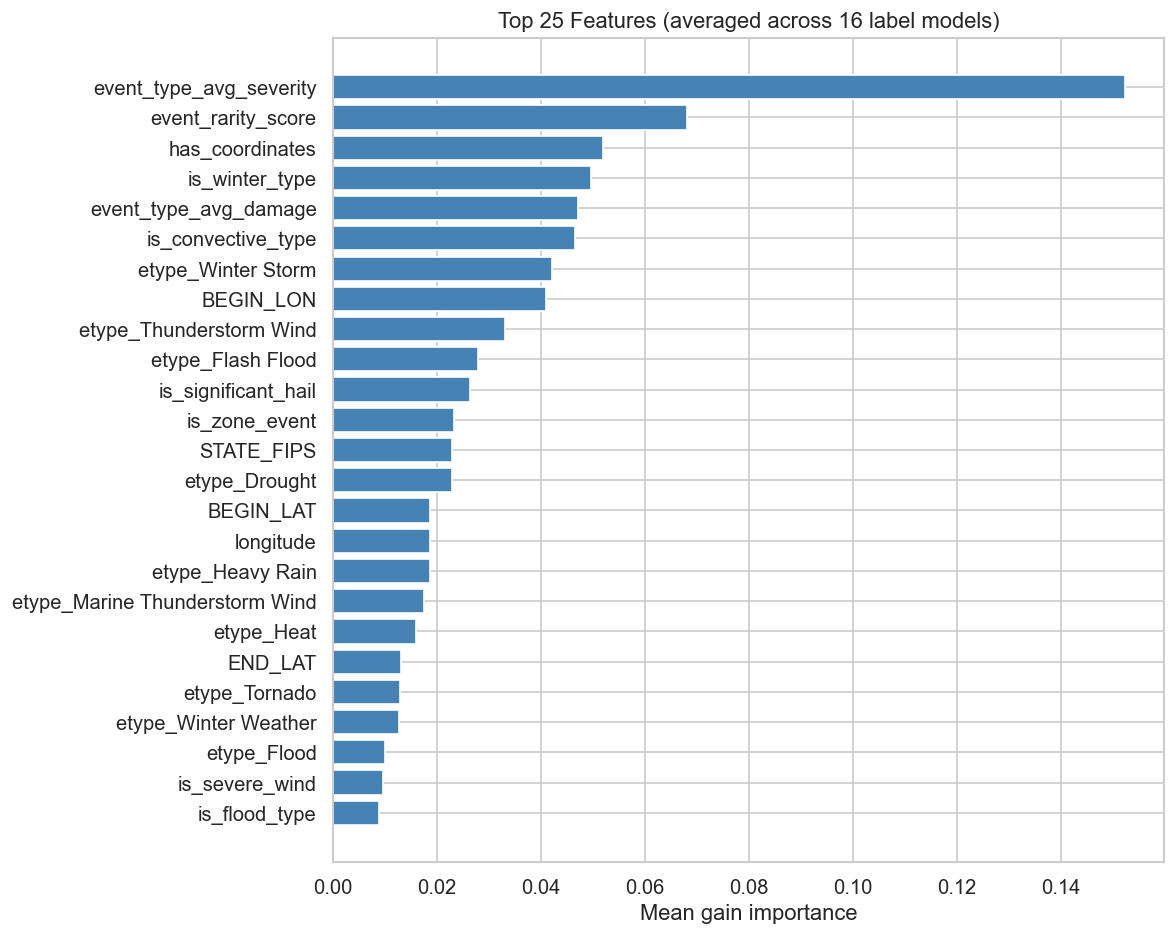

In [19]:
# --- Global average importance ---
reverse_label_map = {v: k for k, v in label_map.items()} if 'label_map' in dir() else {}

imp_matrix = np.zeros((len(models), len(feature_names)))
for j, sanitized in enumerate(sorted(models.keys())):
    mdl = models[sanitized]
    imp_matrix[j] = mdl.feature_importances_

avg_imp = imp_matrix.mean(axis=0)
top_k = 25
top_idx = np.argsort(avg_imp)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    [feature_names[i] for i in reversed(top_idx)],
    [avg_imp[i] for i in reversed(top_idx)],
    color='steelblue'
)
ax.set_xlabel('Mean gain importance')
ax.set_title(f'Top {top_k} Features (averaged across {len(models)} label models)')
plt.tight_layout()
plt.show()


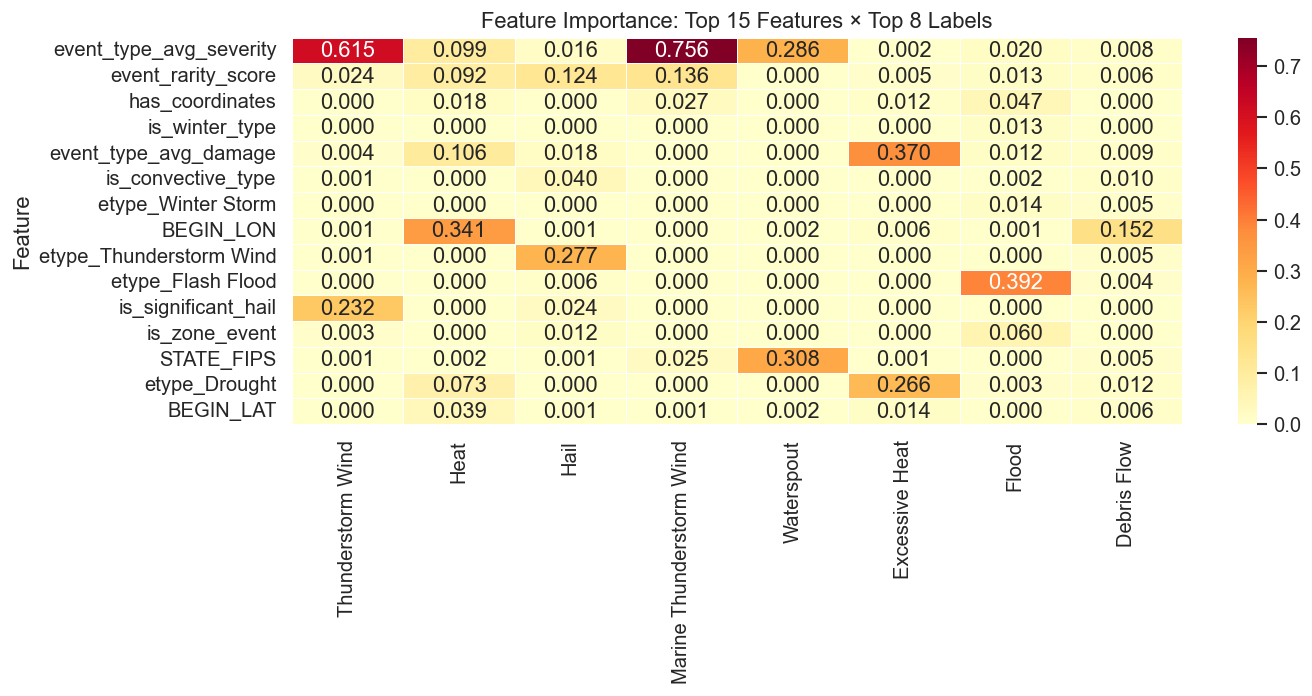

In [20]:
# --- Per-label importance heatmap (top features × top labels) ---
reverse_label_map = {v: k for k, v in label_map.items()} if 'label_map' in dir() else {}

top_labels_for_heatmap = trained.nlargest(8, 'best_val_aucpr')['label'].tolist()
top_feat_idx = top_idx[:15]

heat_data_dict = {}
for lbl in top_labels_for_heatmap:
    sanitized = reverse_label_map.get(lbl, sanitize_label(lbl))
    if sanitized in models:
        heat_data_dict[lbl] = models[sanitized].feature_importances_[top_feat_idx]

heat_data = pd.DataFrame(
    heat_data_dict,
    index=[feature_names[i] for i in top_feat_idx]
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, linewidths=.5)
ax.set_title('Feature Importance: Top 15 Features × Top 8 Labels')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


## 6. Predict, Tune Thresholds & Evaluate
Predict probabilities on validation and test sets, tune per-label thresholds
on the **validation set** (maximise each label's F1 independently), then apply
tuned thresholds to the **test set** and report all metrics.

In [21]:
# ── 6a. Predict probabilities on val + test ────────────────────────────
n_labels = len(target_names)
y_prob = np.zeros((X_test.shape[0], n_labels))
y_prob_val = np.zeros((X_val.shape[0], n_labels))

# Reverse the label map: original label -> sanitized
reverse_label_map = {v: k for k, v in label_map.items()} if 'label_map' in dir() else {}

for i, label in enumerate(target_names):
    sanitized = reverse_label_map.get(label, sanitize_label(label))
    if sanitized in models:
        y_prob[:, i] = models[sanitized].predict_proba(X_test)[:, 1]
        y_prob_val[:, i] = models[sanitized].predict_proba(X_val)[:, 1]

# ── 6b. Per-label threshold tuning on validation set ───────────────────
MIN_THRESH = 0.05  # floor to prevent hyper-aggressive thresholds
optimal_thresholds = np.full(n_labels, 0.5)

print("Per-label threshold tuning (maximise F1 per label on val set):\n")
print(f"  {'Label':30s}  {'Thresh':>7s}  {'Val F1@0.5':>10s} -> {'Val F1@opt':>10s}")
print("  " + "-" * 68)

for i, label in enumerate(target_names):
    sanitized = reverse_label_map.get(label, sanitize_label(label))
    if sanitized not in models:
        continue
    if int(y_val[:, i].sum()) == 0:
        continue

    precs, recs, threshs = precision_recall_curve(y_val[:, i], y_prob_val[:, i])
    f1s = 2 * precs * recs / (precs + recs + 1e-8)
    best = np.argmax(f1s)
    if best < len(threshs):
        optimal_thresholds[i] = max(threshs[best], MIN_THRESH)

    f1_def = f1_score(y_val[:, i], (y_prob_val[:, i] >= 0.5).astype(int), zero_division=0)
    f1_opt = f1_score(y_val[:, i], (y_prob_val[:, i] >= optimal_thresholds[i]).astype(int), zero_division=0)
    delta = "+" if f1_opt > f1_def else ""
    print(f"  {label:30s}  {optimal_thresholds[i]:7.4f}  {f1_def:10.4f} -> {f1_opt:10.4f}  {delta}")

# ── 6c. Apply tuned thresholds to test set ─────────────────────────────
y_pred = (y_prob >= optimal_thresholds).astype(int)
print(f"\nApplied tuned thresholds to test set ({X_test.shape[0]:,} samples).")


Per-label threshold tuning (maximise F1 per label on val set):

  Label                            Thresh  Val F1@0.5 -> Val F1@opt
  --------------------------------------------------------------------
  Blizzard                         0.9697      0.0681 ->     0.3245  +
  Cold/Wind Chill                  0.9266      0.0250 ->     0.4000  +
  Debris Flow                      0.9939      0.1690 ->     0.4679  +
  Excessive Heat                   0.9840      0.2733 ->     0.5018  +
  Extreme Cold/Wind Chill          0.9482      0.1891 ->     0.3333  +
  Flash Flood                      0.8625      0.2274 ->     0.4208  +
  Flood                            0.9438      0.2797 ->     0.4800  +
  Hail                             0.8776      0.3912 ->     0.5574  +
  Heat                             0.9848      0.3331 ->     0.6314  +
  Heavy Snow                       0.9742      0.0582 ->     0.1169  +
  Lightning                        0.8830      0.0612 ->     0.1453  +
  Marine Thunder

In [22]:
reverse_label_map = {v: k for k, v in label_map.items()} if 'label_map' in dir() else {}

# Build list of trained labels from the label map (original label names)
trained_labels = sorted([label_map.get(s, s) for s in models.keys()]) if 'label_map' in dir() else sorted(models.keys())
trained_idx = [i for i, lbl in enumerate(target_names) if lbl in trained_labels]

def compute_all_metrics(y_true, y_pred, y_prob, label_names, col_idx):
    """Compute overall + per-label metrics for the given label columns only."""
    yt = y_true[:, col_idx]
    yp = y_pred[:, col_idx]
    ypr = y_prob[:, col_idx]

    overall = {
        'f1_weighted':        f1_score(yt, yp, average='weighted', zero_division=0),
        'precision_weighted': precision_score(yt, yp, average='weighted', zero_division=0),
        'recall_weighted':    recall_score(yt, yp, average='weighted', zero_division=0),
        'aucpr_weighted':     average_precision_score(yt, ypr, average='weighted'),
        'f1_macro':           f1_score(yt, yp, average='macro',    zero_division=0),
        'f1_micro':           f1_score(yt, yp, average='micro',    zero_division=0),
        'precision_macro':    precision_score(yt, yp, average='macro', zero_division=0),
        'recall_macro':       recall_score(yt, yp, average='macro',    zero_division=0),
        'hamming_loss':       hamming_loss(yt, yp),
        'subset_accuracy':    (yt == yp).all(axis=1).mean(),
    }

    per_label = []
    for j, lbl in enumerate(label_names):
        sup = int(yt[:, j].sum())
        if sup == 0:
            per_label.append(dict(label=lbl, support=0, f1=0, precision=0, recall=0, pr_auc=0))
            continue
        f1   = f1_score(yt[:, j], yp[:, j], zero_division=0)
        prec = precision_score(yt[:, j], yp[:, j], zero_division=0)
        rec  = recall_score(yt[:, j], yp[:, j], zero_division=0)
        try:
            prauc = average_precision_score(yt[:, j], ypr[:, j])
        except Exception:
            prauc = 0.0
        per_label.append(dict(label=lbl, support=sup, f1=f1, precision=prec, recall=rec, pr_auc=prauc))

    return overall, pd.DataFrame(per_label)

overall, perlabel = compute_all_metrics(y_test, y_pred, y_prob, trained_labels, trained_idx)

print(f'=== Overall (tuned thresholds on test set, {len(trained_labels)} trained labels) ===')
print('  ── Weighted (by label support) ──')
for k in ['f1_weighted', 'precision_weighted', 'recall_weighted', 'aucpr_weighted']:
    print(f'  {k:25s} {overall[k]:.4f}')
print('  ── Macro / Micro ──')
for k in ['f1_macro', 'f1_micro', 'precision_macro', 'recall_macro',
          'hamming_loss', 'subset_accuracy']:
    print(f'  {k:25s} {overall[k]:.4f}')

print('\n=== Per-label ===')
perlabel.sort_values('f1', ascending=False).style.format({
    'support': '{:,}', 'f1': '{:.3f}', 'precision': '{:.3f}',
    'recall': '{:.3f}', 'pr_auc': '{:.3f}'
}).bar(subset=['f1'], color='#5fba7d')


=== Overall (tuned thresholds on test set, 16 trained labels) ===
  ── Weighted (by label support) ──
  f1_weighted               0.3845
  precision_weighted        0.4599
  recall_weighted           0.3823
  aucpr_weighted            0.4549
  ── Macro / Micro ──
  f1_macro                  0.2142
  f1_micro                  0.4222
  precision_macro           0.2586
  recall_macro              0.2346
  hamming_loss              0.0144
  subset_accuracy           0.8088

=== Per-label ===


,label,support,f1,precision,recall,pr_auc
12,Thunderstorm Wind,"9,688",0.688,0.605,0.798,0.708
14,Waterspout,286,0.517,0.464,0.584,0.450
11,Marine Thunderstorm Wind,169,0.441,0.327,0.680,0.316
7,Hail,"9,749",0.412,0.598,0.314,0.516
6,Flood,"1,869",0.388,0.444,0.345,0.407
5,Flash Flood,"9,973",0.362,0.378,0.348,0.353
3,Excessive Heat,"3,070",0.297,0.445,0.222,0.376
10,Lightning,"1,101",0.166,0.108,0.354,0.090
2,Debris Flow,292,0.128,0.209,0.092,0.087
15,Wildfire,206,0.023,0.059,0.015,0.020


## 7. Predicted-Probability Distributions
Histograms of predicted P(positive) for actual positives vs negatives.

**How to interpret**: A well-calibrated model pushes these distributions apart — negatives
cluster near 0 and positives cluster near 1. Overlapping distributions indicate the model
struggles to separate the classes. The degree of separation directly affects the precision-recall
trade-off and the optimal threshold chosen in Section 6.

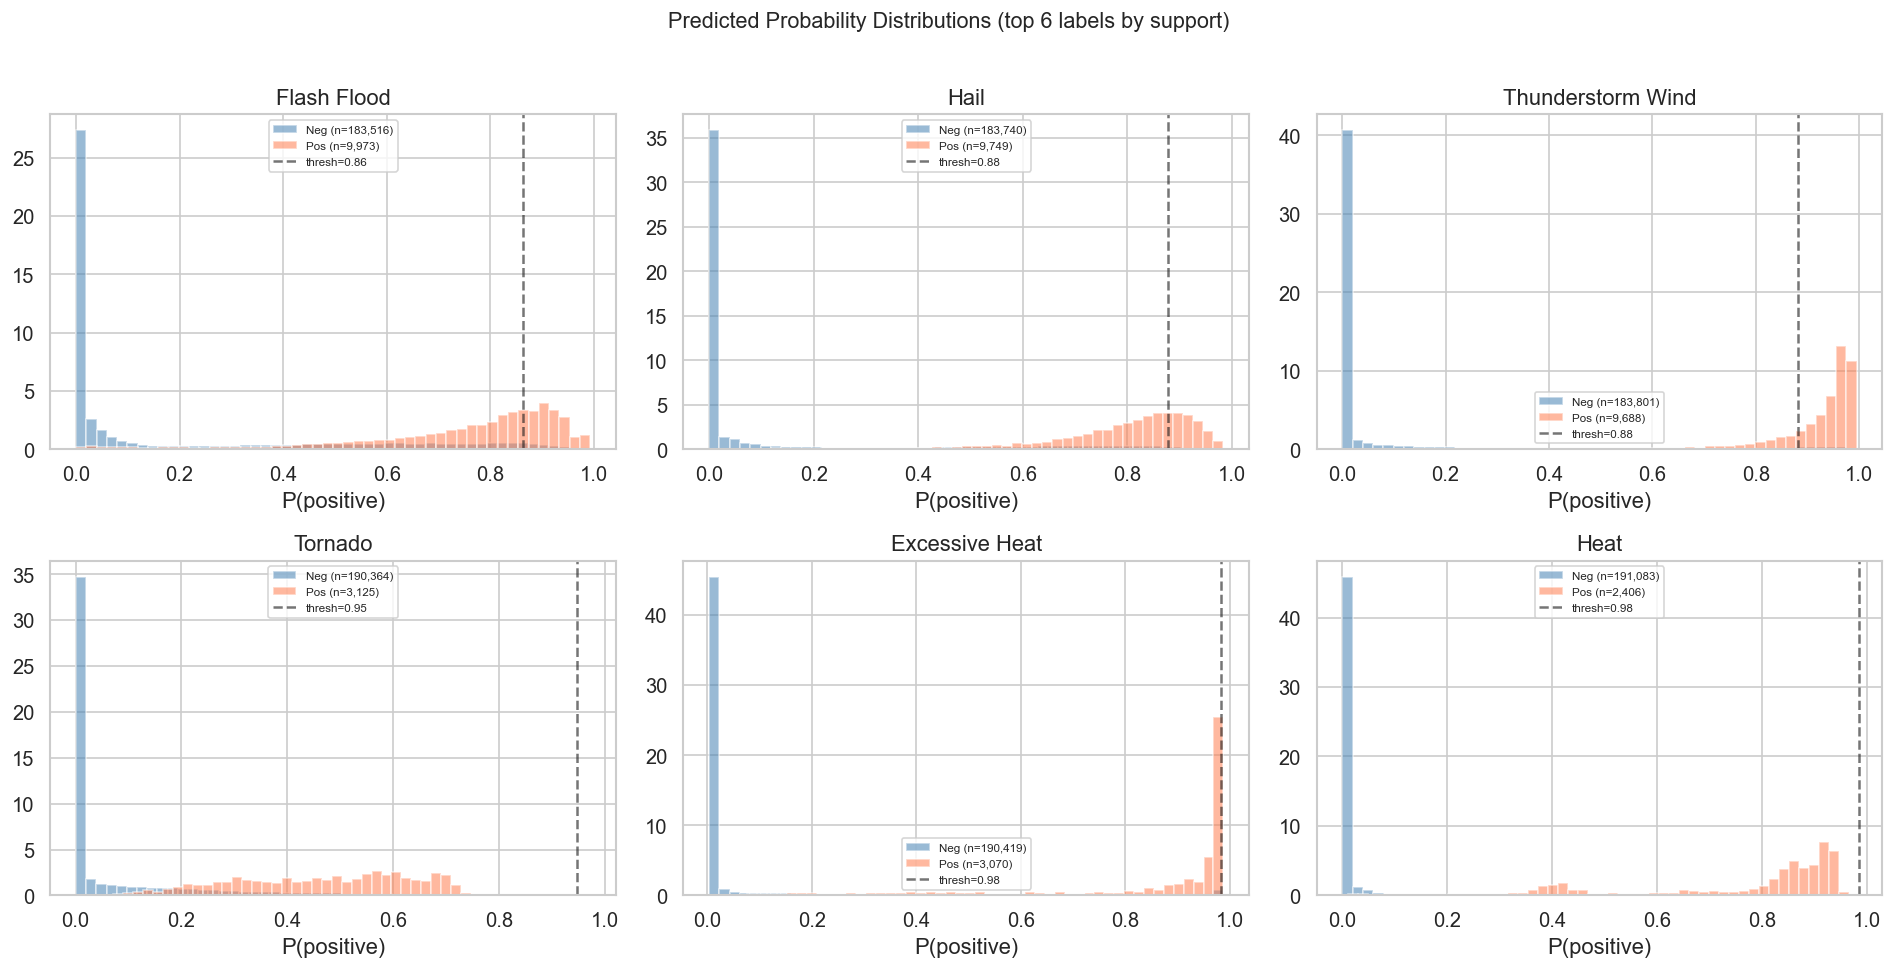

In [23]:
show_labels = perlabel.nlargest(6, 'support')['label'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, label in zip(axes.flat, show_labels):
    idx = target_names.index(label)
    pos_probs = y_prob[y_test[:, idx] == 1, idx]
    neg_probs = y_prob[y_test[:, idx] == 0, idx]

    ax.hist(neg_probs, bins=50, alpha=.55, label=f'Neg (n={len(neg_probs):,})', color='steelblue', density=True)
    ax.hist(pos_probs, bins=50, alpha=.55, label=f'Pos (n={len(pos_probs):,})', color='coral', density=True)
    ax.axvline(optimal_thresholds[idx], ls='--', color='k', alpha=.6, label=f'thresh={optimal_thresholds[idx]:.2f}')
    ax.set_title(label)
    ax.set_xlabel('P(positive)')
    ax.legend(fontsize=7)

fig.suptitle('Predicted Probability Distributions (top 6 labels by support)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Tuned Threshold Visualization
The thresholds were tuned in Section 6 above. This chart shows the per-label
decision thresholds vs. the default 0.5.

**How to interpret**: Labels with low prevalence typically have optimal thresholds well below 0.5,
because the model outputs lower probabilities for rare events. If a threshold is very low (< 0.1),
the model is trading precision for recall — it predicts more positives to catch the few true ones.
Compare this chart with the per-label F1 results to see whether threshold tuning helped.

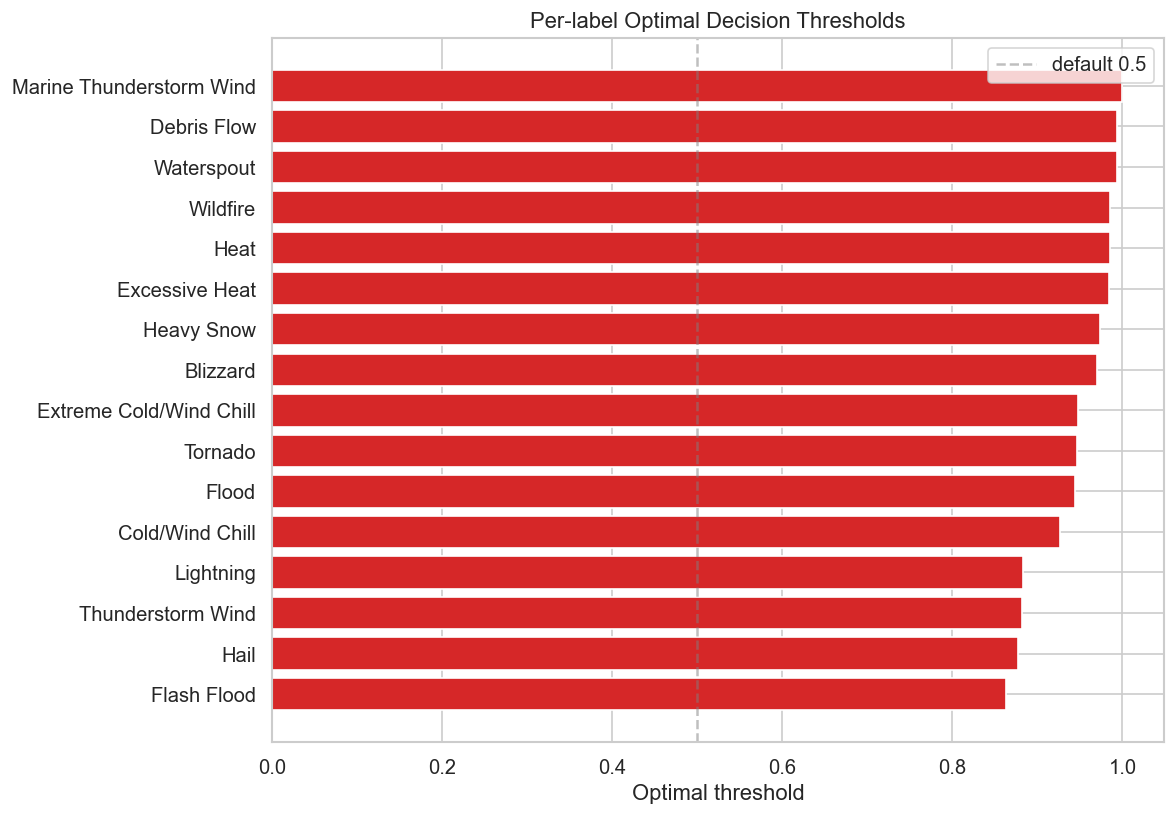

In [24]:
# --- Visualise optimal thresholds (trained labels only) ---
thresh_df = pd.DataFrame({
    'label': [target_names[i] for i in trained_idx],
    'threshold': [optimal_thresholds[i] for i in trained_idx]
})
thresh_df = thresh_df.sort_values('threshold', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ca02c' if t < 0.4 else '#ff7f0e' if t < 0.6 else '#d62728'
          for t in thresh_df['threshold']]
ax.barh(thresh_df['label'], thresh_df['threshold'], color=colors)
ax.axvline(0.5, ls='--', color='gray', alpha=.5, label='default 0.5')
ax.set_xlabel('Optimal threshold')
ax.set_title('Per-label Optimal Decision Thresholds')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Precision-Recall Curves

Precision-Recall (PR) curves show the trade-off between precision and recall at every possible
threshold. The area under the PR curve (AUCPR or Average Precision) is the primary metric for
this task because it is robust to class imbalance.

**How to interpret**: A curve hugging the top-right corner indicates strong performance.
Labels with high AUCPR can achieve both high precision and high recall simultaneously.
Labels with low AUCPR (curve close to the diagonal) struggle to identify positives without
generating many false positives. Compare across labels to identify which disaster types
the model handles well vs. poorly.

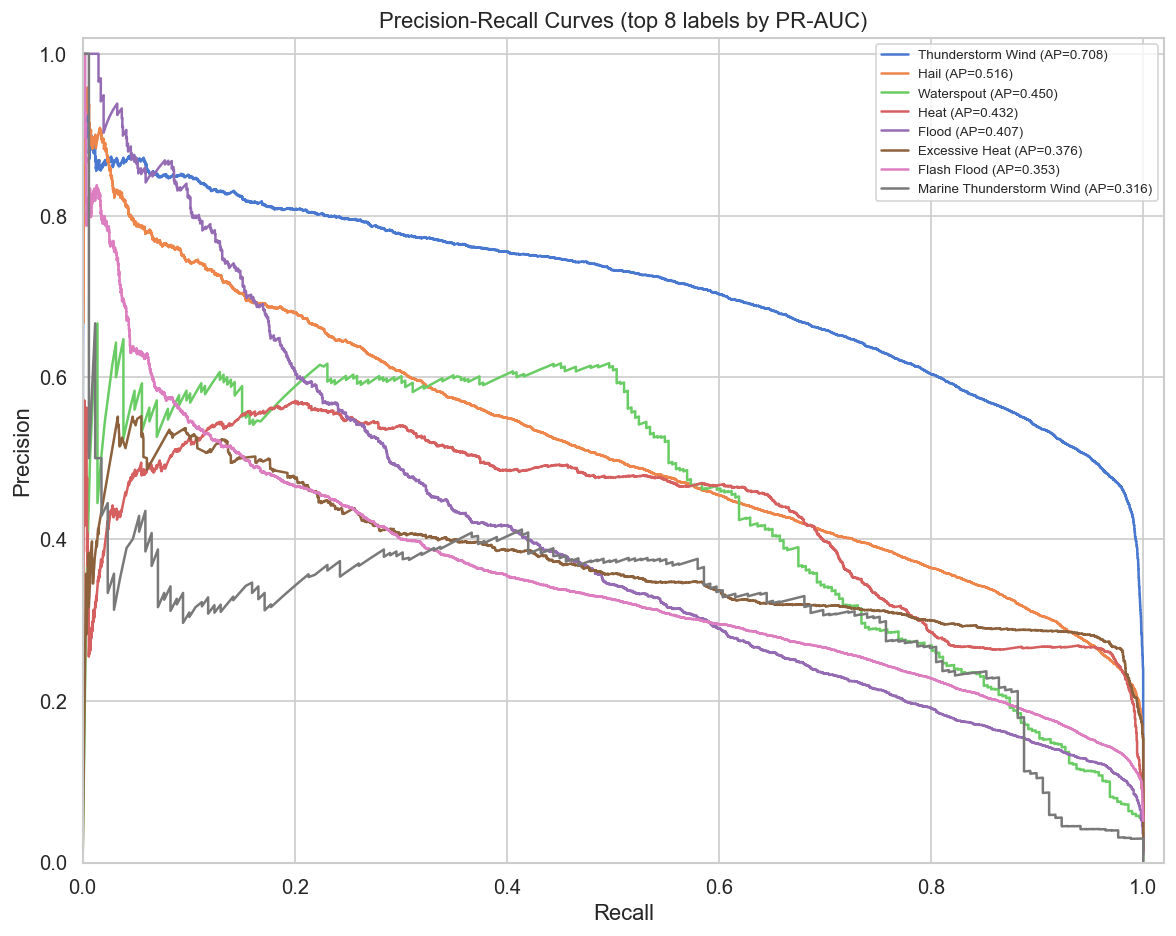

In [25]:
show_pr = perlabel.nlargest(8, 'pr_auc')['label'].tolist()

fig, ax = plt.subplots(figsize=(10, 8))
for label in show_pr:
    idx = target_names.index(label)
    if y_test[:, idx].sum() == 0:
        continue
    precs, recs, _ = precision_recall_curve(y_test[:, idx], y_prob[:, idx])
    ap = average_precision_score(y_test[:, idx], y_prob[:, idx])
    ax.plot(recs, precs, label=f'{label} (AP={ap:.3f})', lw=1.5)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (top 8 labels by PR-AUC)')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

## 10. Confusion Matrices (top labels)

Confusion matrices show the breakdown of predictions into true positives (TP), false positives (FP),
true negatives (TN), and false negatives (FN) for each label after applying tuned thresholds.

**How to interpret**: For imbalanced labels, focus on the TP and FN cells rather than TN.
A high FN count (bottom-left) means the model misses many actual positives. A high FP count
(top-right) means the model over-predicts. The ratio of TP to (TP + FN) is recall; the ratio
of TP to (TP + FP) is precision. Ideally, both should be high.

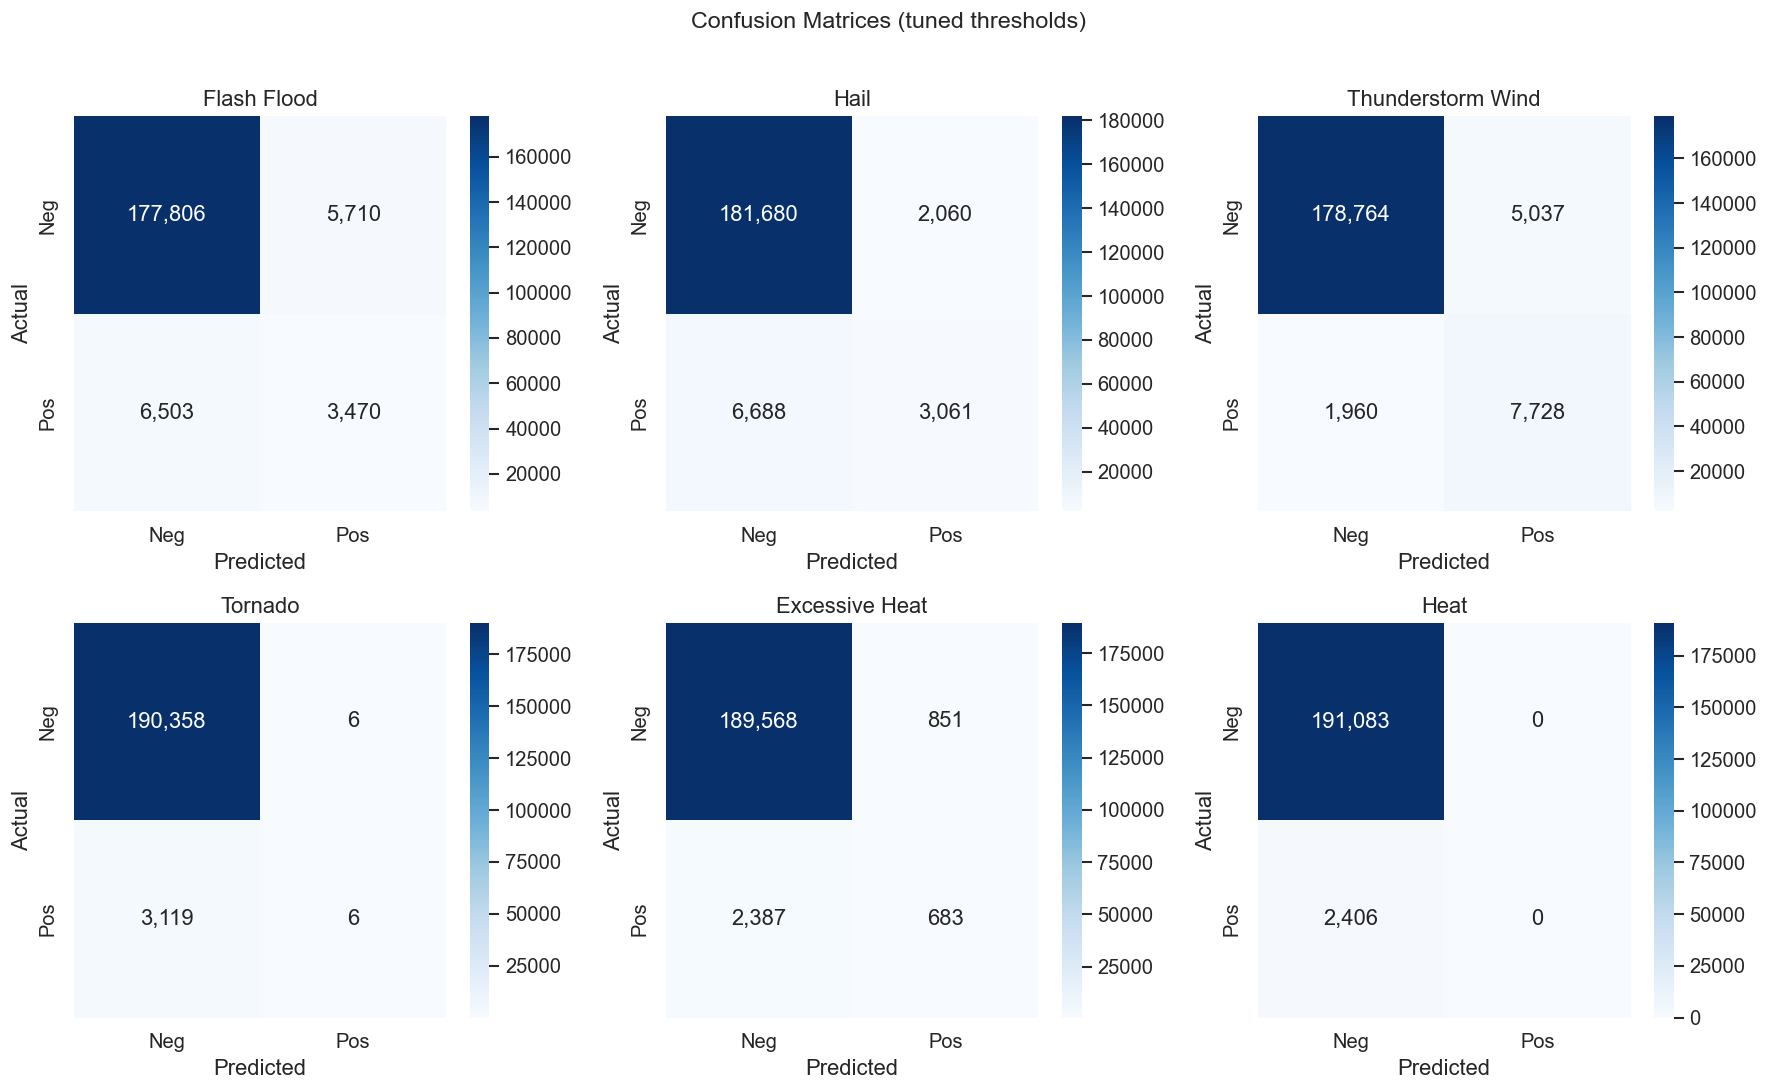

In [26]:
cm_labels = perlabel.nlargest(6, 'support')['label'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, label in zip(axes.flat, cm_labels):
    idx = target_names.index(label)
    cm = confusion_matrix(y_test[:, idx], y_pred[:, idx])
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    ax.set_title(label)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

fig.suptitle('Confusion Matrices (tuned thresholds)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 11. Summary

Overall weighted and macro metrics across all trained labels. Weighted metrics give more
influence to labels with more test samples, while macro metrics treat all labels equally.

**How to interpret**: A large gap between weighted and macro F1 indicates the model performs
well on common labels but poorly on rare ones. Subset accuracy (exact match) is typically low
for multilabel problems — focus on F1 and Hamming Loss instead.

In [27]:
print('╔════════════════════════════════════════════╗')
print('║     Final Multilabel Results (tuned)      ║')
print('╠════════════════════════════════════════════╣')
for k, v in overall.items():
    print(f'║  {k:28s}  {v:>8.4f}  ║')
print('╚════════════════════════════════════════════╝')

print('\nPer-label breakdown (sorted by F1):')
perlabel.sort_values('f1', ascending=False)

╔════════════════════════════════════════════╗
║     Final Multilabel Results (tuned)      ║
╠════════════════════════════════════════════╣
║  f1_weighted                     0.3845  ║
║  precision_weighted              0.4599  ║
║  recall_weighted                 0.3823  ║
║  aucpr_weighted                  0.4549  ║
║  f1_macro                        0.2142  ║
║  f1_micro                        0.4222  ║
║  precision_macro                 0.2586  ║
║  recall_macro                    0.2346  ║
║  hamming_loss                    0.0144  ║
║  subset_accuracy                 0.8088  ║
╚════════════════════════════════════════════╝

Per-label breakdown (sorted by F1):


,label,support,f1,precision,recall,pr_auc
12,Thunderstorm Wind,9688,0.688371,0.605405,0.797688,0.708307
14,Waterspout,286,0.517028,0.463889,0.583916,0.450074
11,Marine Thunderstorm Wind,169,0.441459,0.326705,0.680473,0.316363
7,Hail,9749,0.411701,0.597735,0.313981,0.516124
6,Flood,1869,0.387952,0.443832,0.344569,0.406767
5,Flash Flood,9973,0.362345,0.377996,0.347939,0.352646
3,Excessive Heat,3070,0.296699,0.445241,0.222476,0.375989
10,Lightning,1101,0.165640,0.108093,0.354223,0.090217
2,Debris Flow,292,0.128266,0.209302,0.092466,0.087050
15,Wildfire,206,0.023346,0.058824,0.014563,0.019541


### Per-label F1 bar chart

This horizontal bar chart ranks each label by its test-set F1 score after threshold tuning.

**How to interpret**: Labels at the top have the best precision-recall balance.
Labels with F1 near zero may have too few training samples for the model to learn meaningful
patterns. Compare with label prevalence from Section 2 — typically, higher prevalence
correlates with higher F1, but well-engineered features can boost rare-label performance.

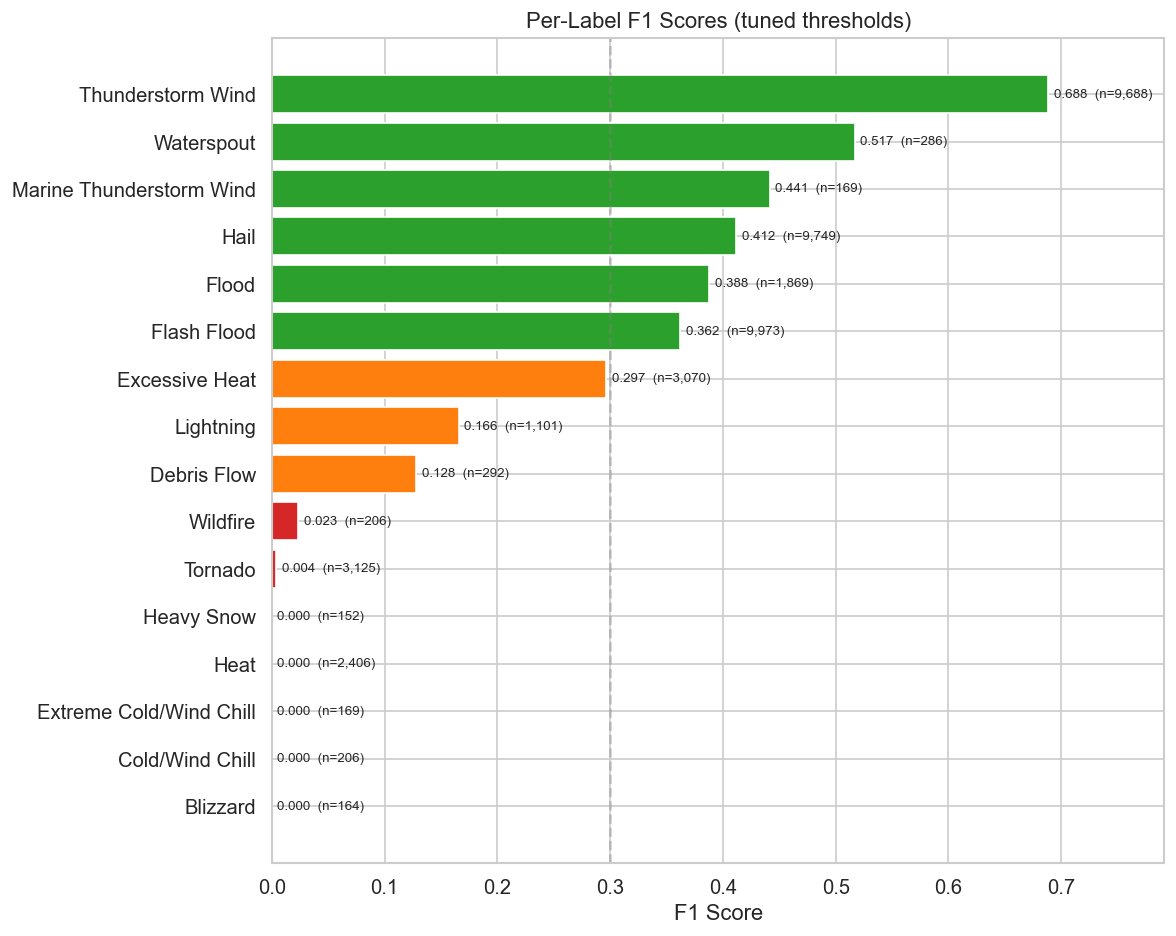

In [28]:
df_final = perlabel.sort_values('f1', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ca02c' if f >= 0.3 else '#ff7f0e' if f >= 0.1 else '#d62728' for f in df_final['f1']]
ax.barh(df_final['label'], df_final['f1'], color=colors)
ax.set_xlabel('F1 Score')
ax.set_title('Per-Label F1 Scores (tuned thresholds)')
ax.axvline(0.3, ls='--', color='gray', alpha=.4)
ax.set_xlim(0, max(df_final['f1'].max() * 1.15, 0.5))

for i, (f1, sup) in enumerate(zip(df_final['f1'], df_final['support'])):
    ax.text(f1 + 0.005, i, f'{f1:.3f}  (n={sup:,})', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 12. SHAP Interpretability Analysis

SHAP (SHapley Additive exPlanations) provides a unified framework for interpreting
model predictions. For each sample, SHAP assigns a contribution value to every feature,
telling us how much and in which direction** each feature pushed the prediction.

What we'll cover:
1. Compute TreeSHAP values for our XGBoost models (fast, exact for trees)
2. Global feature importance — mean |SHAP| across all samples
3. Beeswarm plots — feature impact distributions for top labels
4. Dependence plots — how individual features affect predictions
5. Waterfall plots — explain individual predictions
6. Cross-label SHAP comparison — which features matter for which disasters
7. Feature interaction analysis — which feature pairs amplify each other
8. SHAP clustering — identify sample archetypes

In [29]:
import shap
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# ── Compute SHAP values for all trained models ────────────────────────
# Balanced subsample: include positives for every label so rare events are represented
SHAP_SAMPLE = min(20_000, X_test.shape[0])
rng = np.random.RandomState(42)

# Step 1: Collect positive indices for each trainable label
_pos_indices = set()
# Robust lookup: Find index in the current target_names (prevents IndexError if data refreshed)
label_to_idx = {name: i for i, name in enumerate(target_names)}
for _, label, _ in trainable:
    if label in label_to_idx:
        curr_idx = label_to_idx[label]
        _label_pos = np.where(y_test[:, curr_idx] == 1)[0]
        _pos_indices.update(_label_pos.tolist())

_pos_indices = np.array(sorted(_pos_indices))
print(f"Balanced SHAP sampling: {len(_pos_indices):,} unique positive-sample indices across {len(trainable)} labels")

# Step 2: Fill remaining slots with random negatives
if len(_pos_indices) >= SHAP_SAMPLE:
    # More positives than budget — subsample positives
    shap_idx = rng.choice(_pos_indices, size=SHAP_SAMPLE, replace=False)
    print(f"  (subsampled positives to {SHAP_SAMPLE:,})")
else:
    # Fill the rest with random non-positive indices
    _remaining = SHAP_SAMPLE - len(_pos_indices)
    _neg_pool = np.setdiff1d(np.arange(X_test.shape[0]), _pos_indices)
    _neg_sample = rng.choice(_neg_pool, size=min(_remaining, len(_neg_pool)), replace=False)
    shap_idx = np.sort(np.concatenate([_pos_indices, _neg_sample]))
    print(f"  → {len(_pos_indices):,} positive + {len(_neg_sample):,} negative = {len(shap_idx):,} total")

X_shap = X_test[shap_idx]

# Sort labels by F1 so we focus on the most/least successful models
label_ranking = perlabel.sort_values('f1', ascending=False)['label'].tolist()
reverse_label_map = {v: k for k, v in label_map.items()} if label_map else {}

# Compute SHAP values for every trained label
shap_values_dict = {}   # label -> shap.Explanation
shap_explainer_dict = {} # label -> TreeExplainer

print(f"Computing TreeSHAP values on {SHAP_SAMPLE:,} test samples ...\n")

for label in label_ranking:
    sanitized = reverse_label_map.get(label, sanitize_label(label))
    if sanitized not in models:
        continue
    mdl = models[sanitized]
    explainer = shap.TreeExplainer(mdl)
    sv = explainer.shap_values(X_shap)

    shap_values_dict[label] = shap.Explanation(
        values=sv,
        base_values=np.full(len(X_shap), explainer.expected_value),
        data=X_shap,
        feature_names=feature_names
    )
    shap_explainer_dict[label] = explainer
    print(f"  ✓ {label}")

print(f"\nDone — SHAP values computed for {len(shap_values_dict)} labels.")


Balanced SHAP sampling: 37,263 unique positive-sample indices across 16 labels
  (subsampled positives to 20,000)
Computing TreeSHAP values on 20,000 test samples ...

  ✓ Thunderstorm Wind
  ✓ Waterspout
  ✓ Marine Thunderstorm Wind
  ✓ Hail
  ✓ Flood
  ✓ Flash Flood
  ✓ Excessive Heat
  ✓ Lightning
  ✓ Debris Flow
  ✓ Wildfire
  ✓ Tornado
  ✓ Blizzard
  ✓ Cold/Wind Chill
  ✓ Extreme Cold/Wind Chill
  ✓ Heat
  ✓ Heavy Snow

Done — SHAP values computed for 16 labels.


### 12a. Global SHAP Feature Importance
Mean absolute SHAP value per feature, averaged across **all** trained labels.  
This tells us which features are most influential *overall* — not just for a single disaster type.

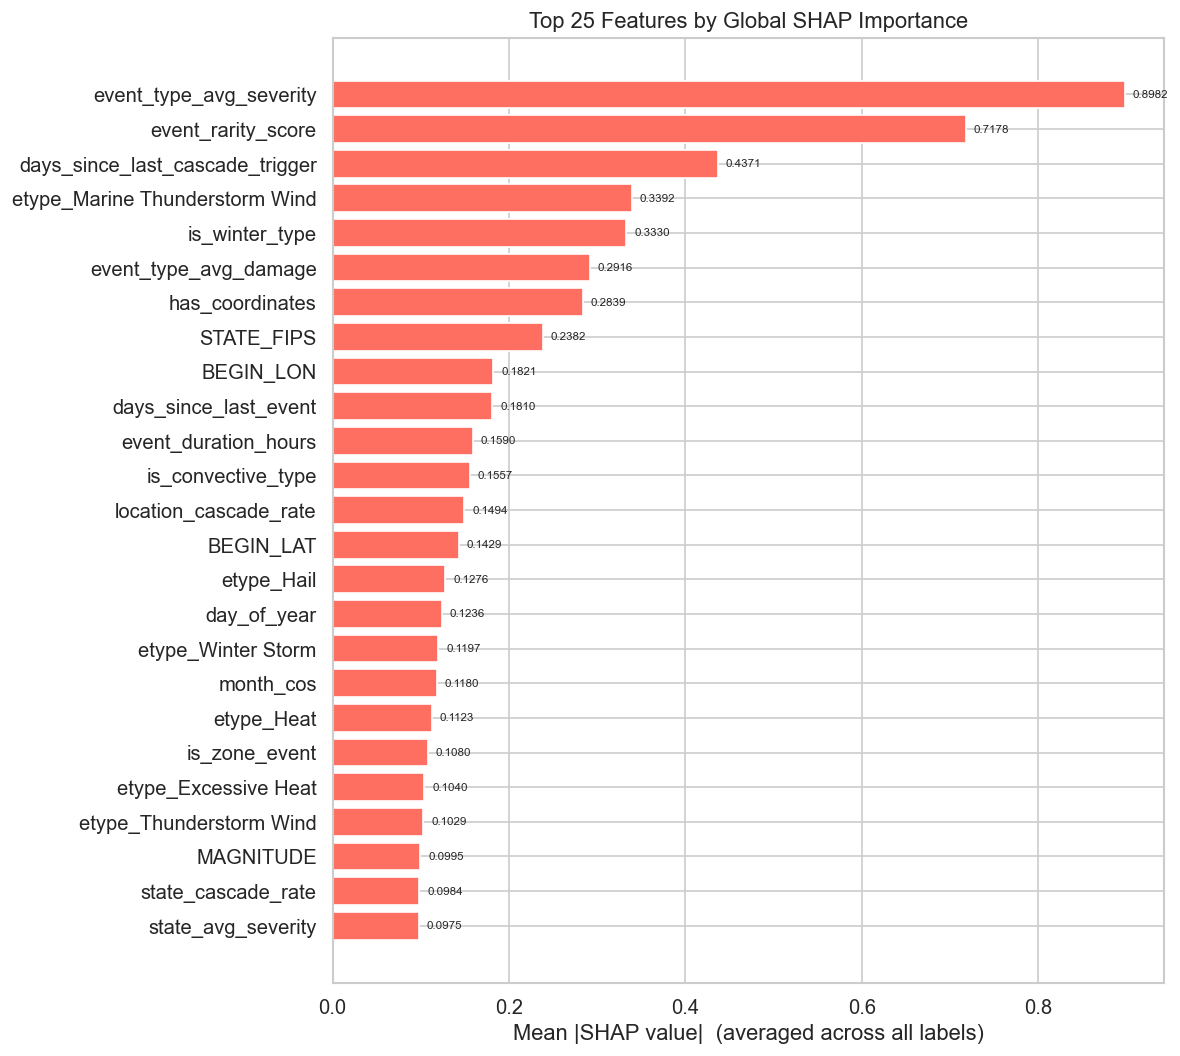

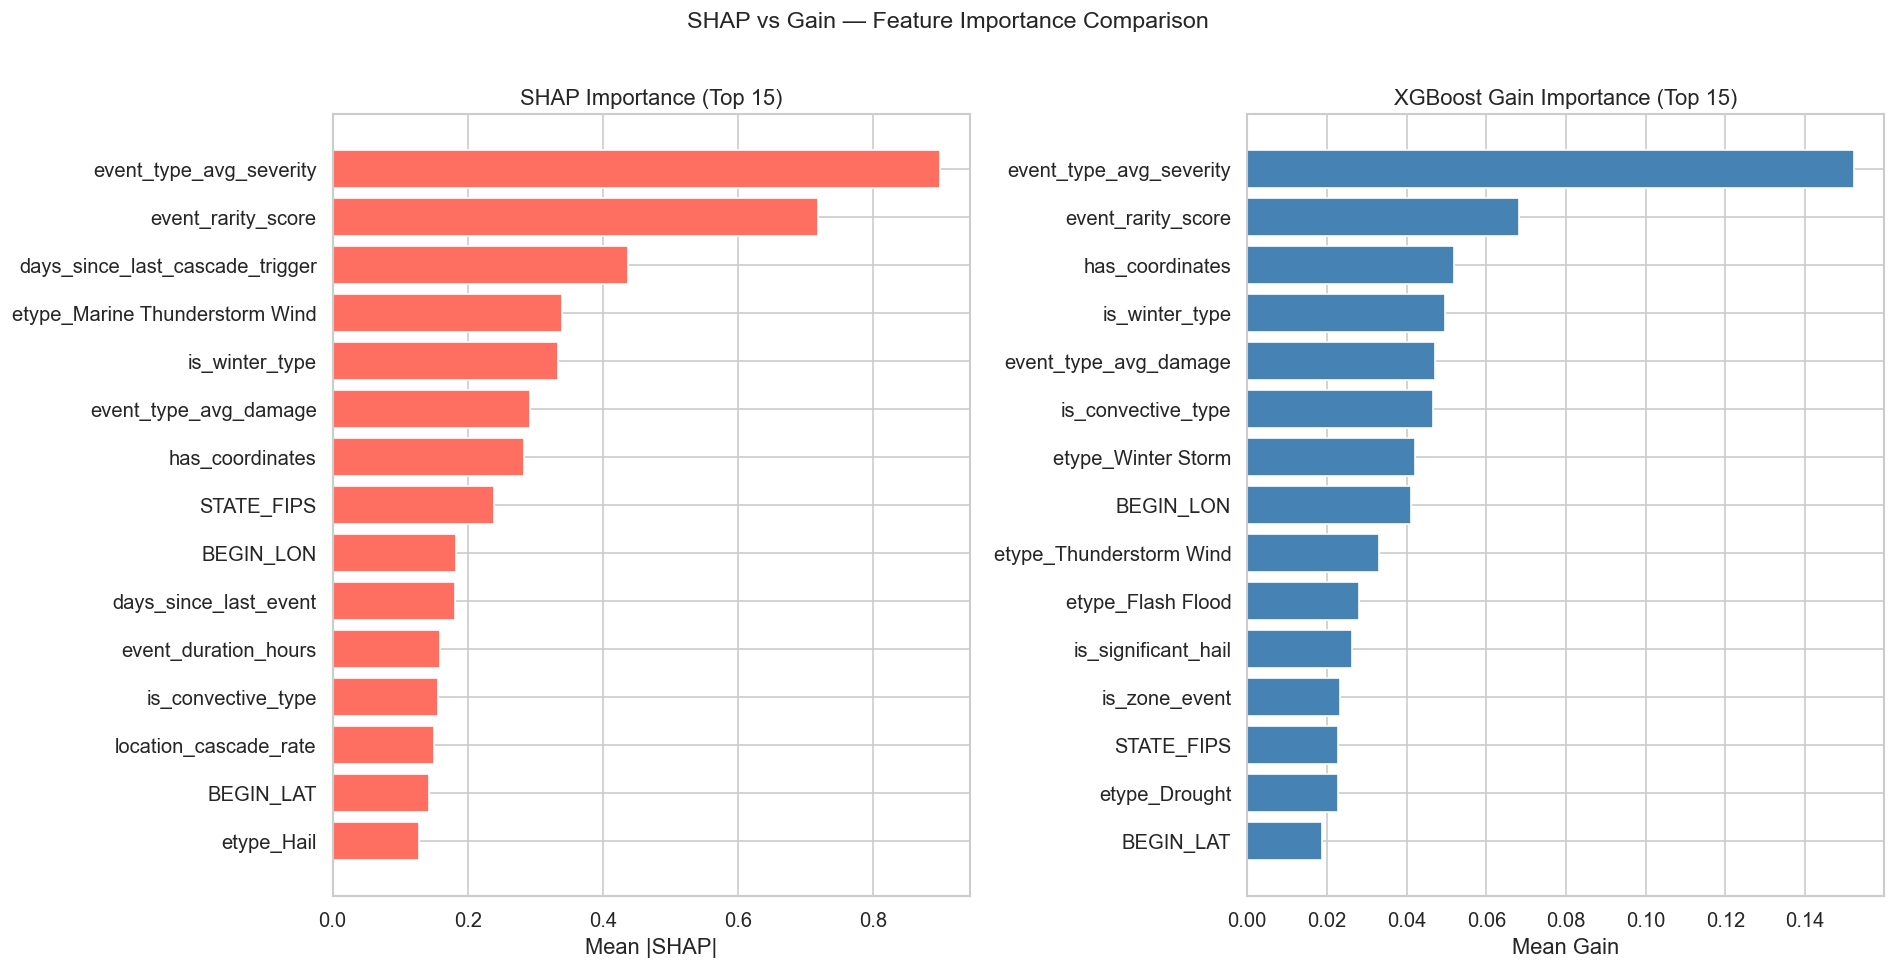

Note: SHAP importance accounts for feature interactions and is more faithful
to the actual model predictions. Gain can overstate correlated features.


In [30]:
# ── Global mean |SHAP| across all labels ───────────────────────────────
all_shap_abs = np.zeros(len(feature_names))
for label, sv in shap_values_dict.items():
    all_shap_abs += np.abs(sv.values).mean(axis=0)
all_shap_abs /= len(shap_values_dict)

top_k_shap = 25
shap_top_idx = np.argsort(all_shap_abs)[::-1][:top_k_shap]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(
    [feature_names[i] for i in reversed(shap_top_idx)],
    [all_shap_abs[i] for i in reversed(shap_top_idx)],
    color='#ff6f61'
)
ax.set_xlabel('Mean |SHAP value|  (averaged across all labels)')
ax.set_title(f'Top {top_k_shap} Features by Global SHAP Importance')
for i, idx in enumerate(reversed(shap_top_idx)):
    ax.text(all_shap_abs[idx] + all_shap_abs[shap_top_idx[0]] * 0.01,
            i, f'{all_shap_abs[idx]:.4f}', va='center', fontsize=7)
plt.tight_layout()
plt.show()

# ── Compare XGBoost gain vs SHAP importance ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# SHAP
axes[0].barh(
    [feature_names[i] for i in reversed(shap_top_idx[:15])],
    [all_shap_abs[i] for i in reversed(shap_top_idx[:15])],
    color='#ff6f61'
)
axes[0].set_xlabel('Mean |SHAP|')
axes[0].set_title('SHAP Importance (Top 15)')

# Gain
gain_top = np.argsort(avg_imp)[::-1][:15]
axes[1].barh(
    [feature_names[i] for i in reversed(gain_top)],
    [avg_imp[i] for i in reversed(gain_top)],
    color='steelblue'
)
axes[1].set_xlabel('Mean Gain')
axes[1].set_title('XGBoost Gain Importance (Top 15)')

fig.suptitle('SHAP vs Gain — Feature Importance Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Note: SHAP importance accounts for feature interactions and is more faithful")
print("to the actual model predictions. Gain can overstate correlated features.")

### 12b. SHAP Beeswarm Plots (Top Labels)
Each dot is a test sample. X-axis = SHAP value (impact on prediction).
Colour = feature value (red = high, blue = low).  
This reveals the **direction** of each feature's effect — e.g., does higher wind speed
increase or decrease flood risk?


  Thunderstorm Wind  (F1 = 0.688)


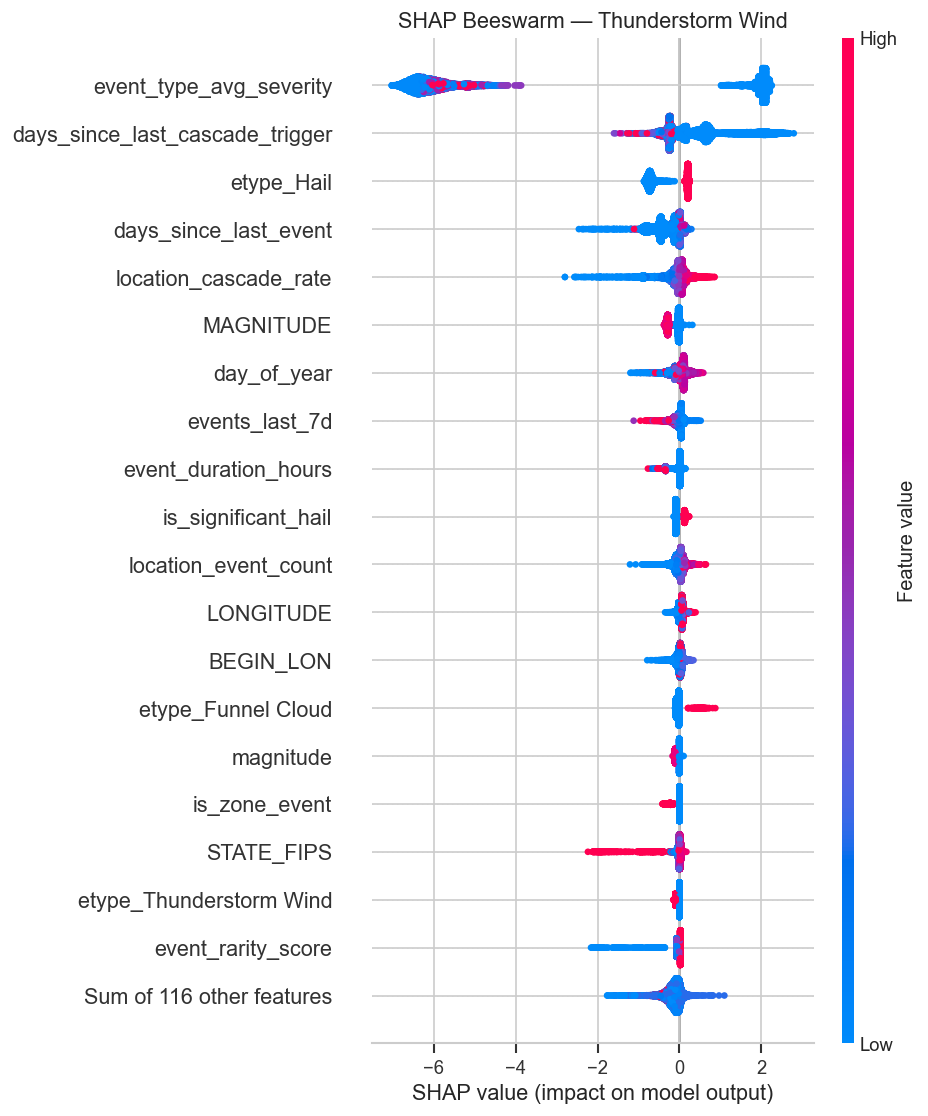


  Waterspout  (F1 = 0.517)


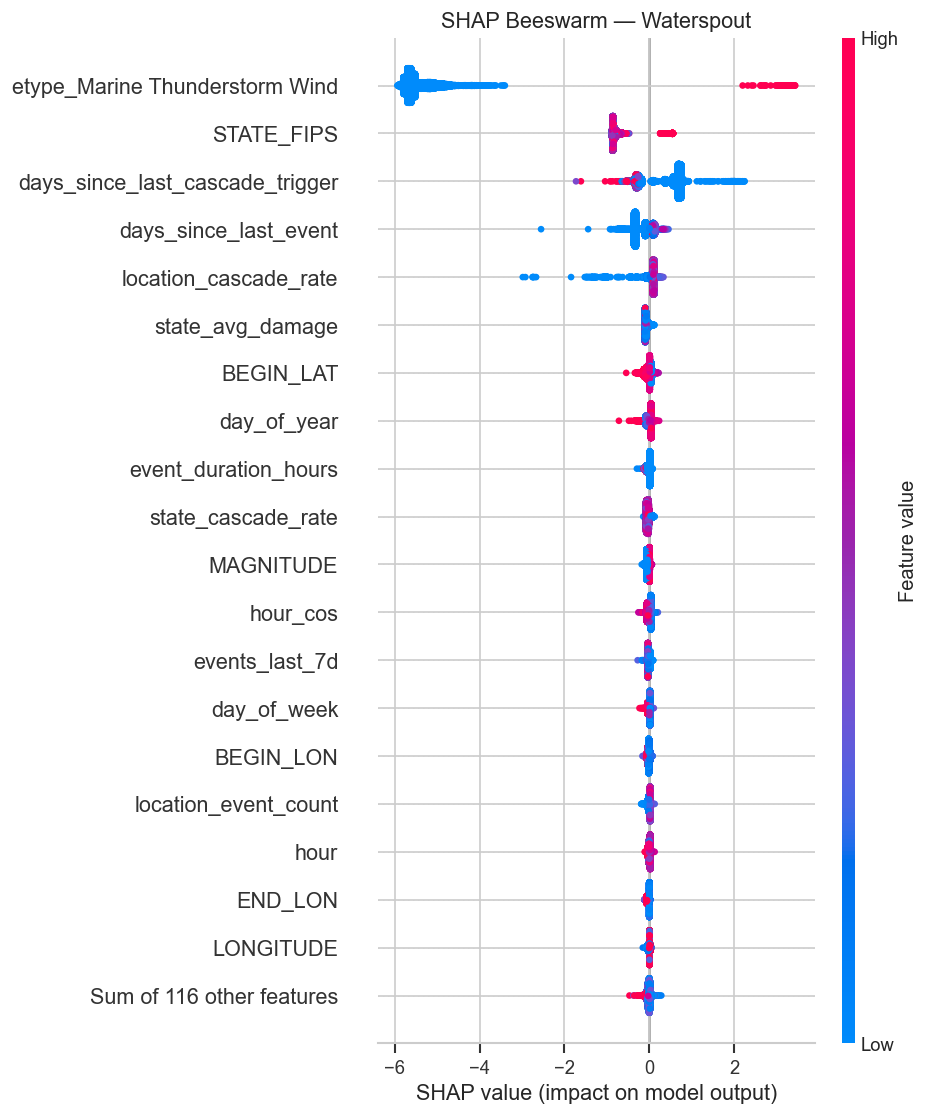


  Marine Thunderstorm Wind  (F1 = 0.441)


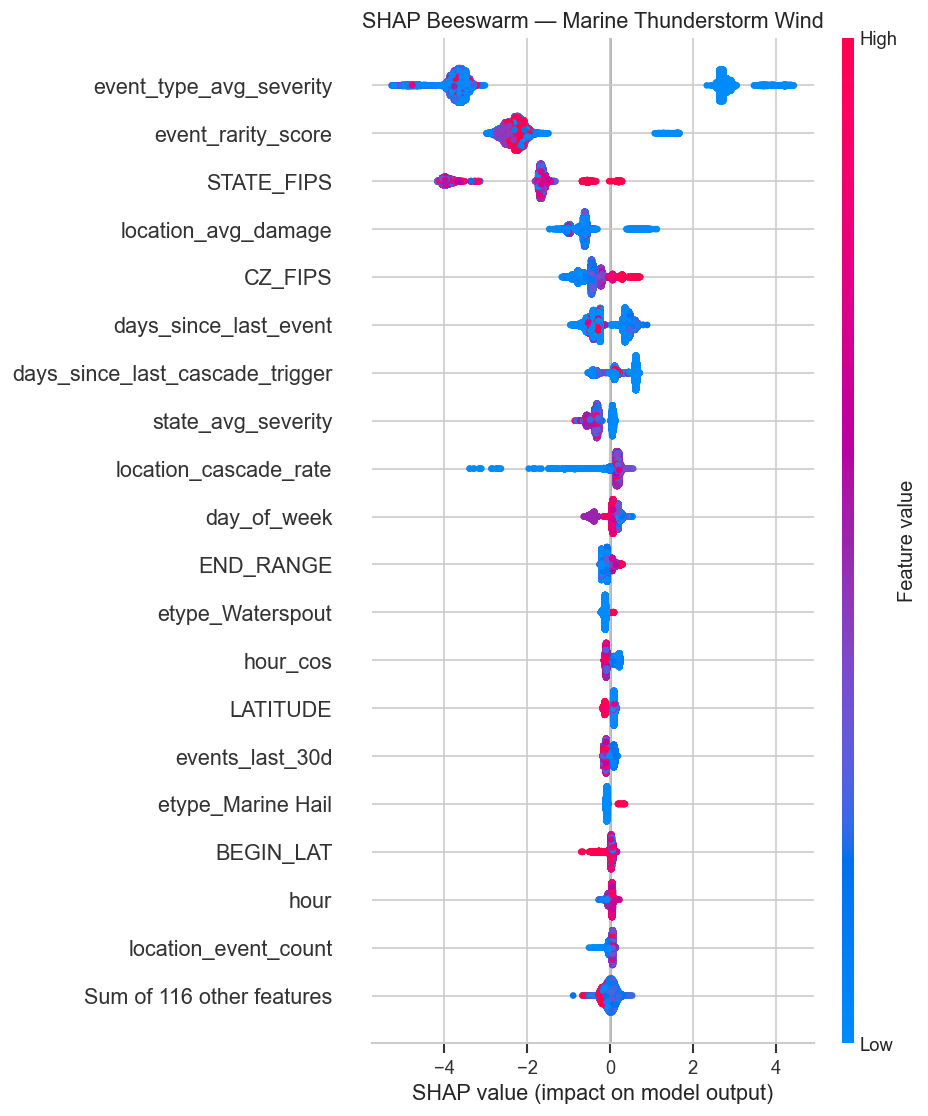


  Hail  (F1 = 0.412)


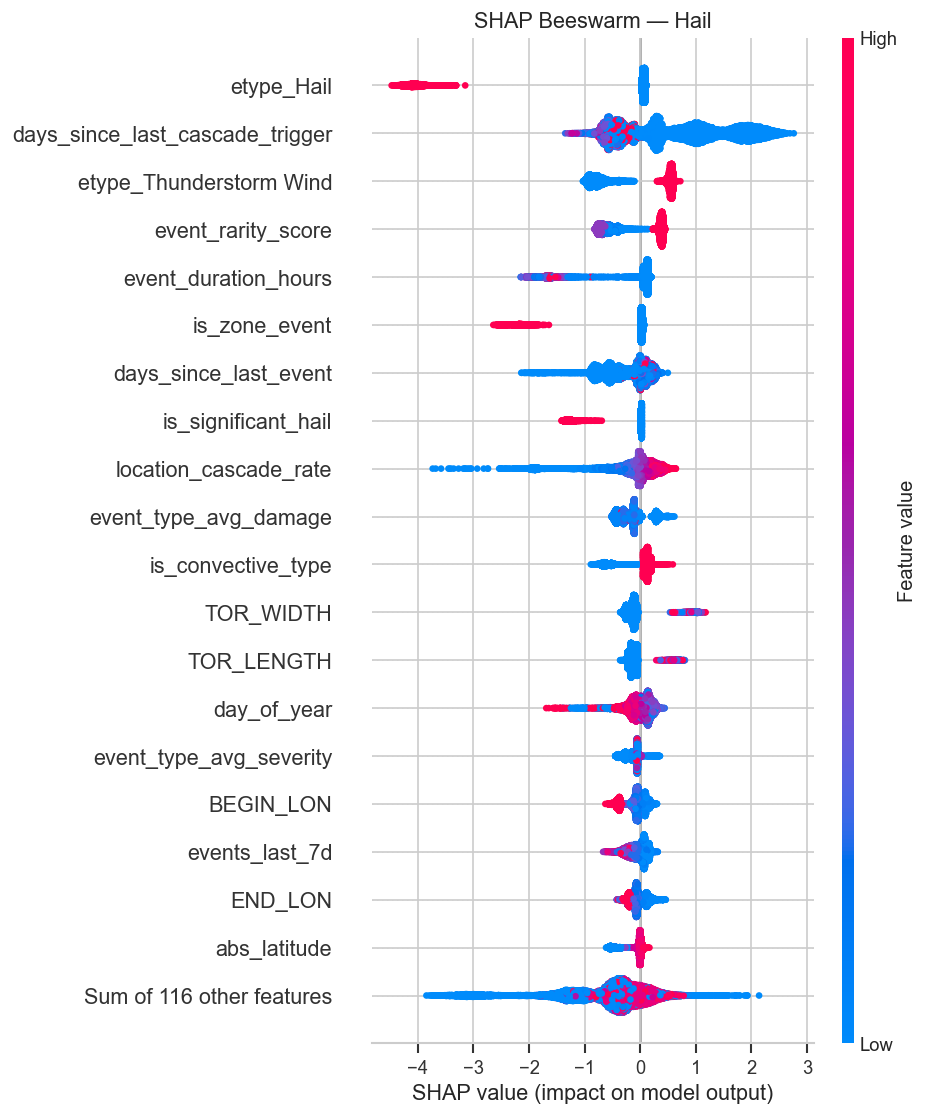


  Tornado  (F1 = 0.004)


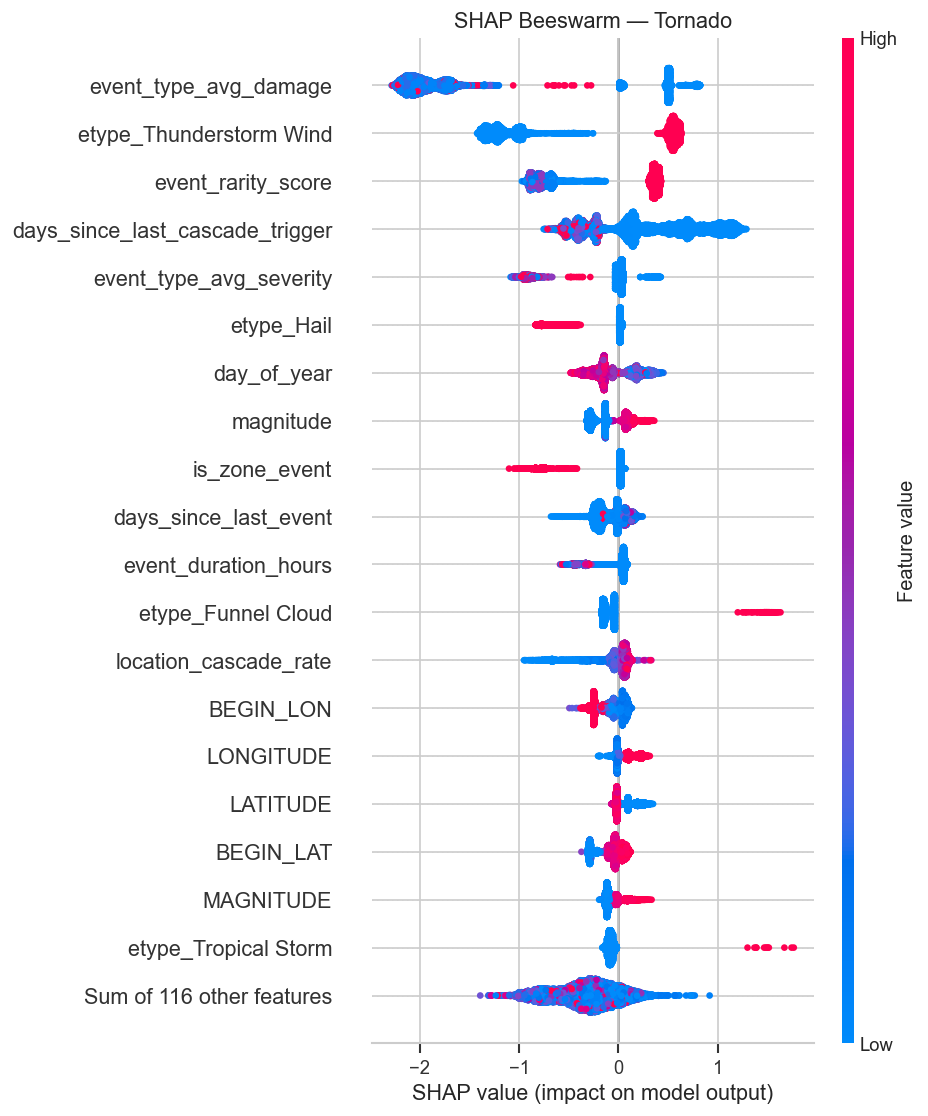


  Wildfire  (F1 = 0.023)


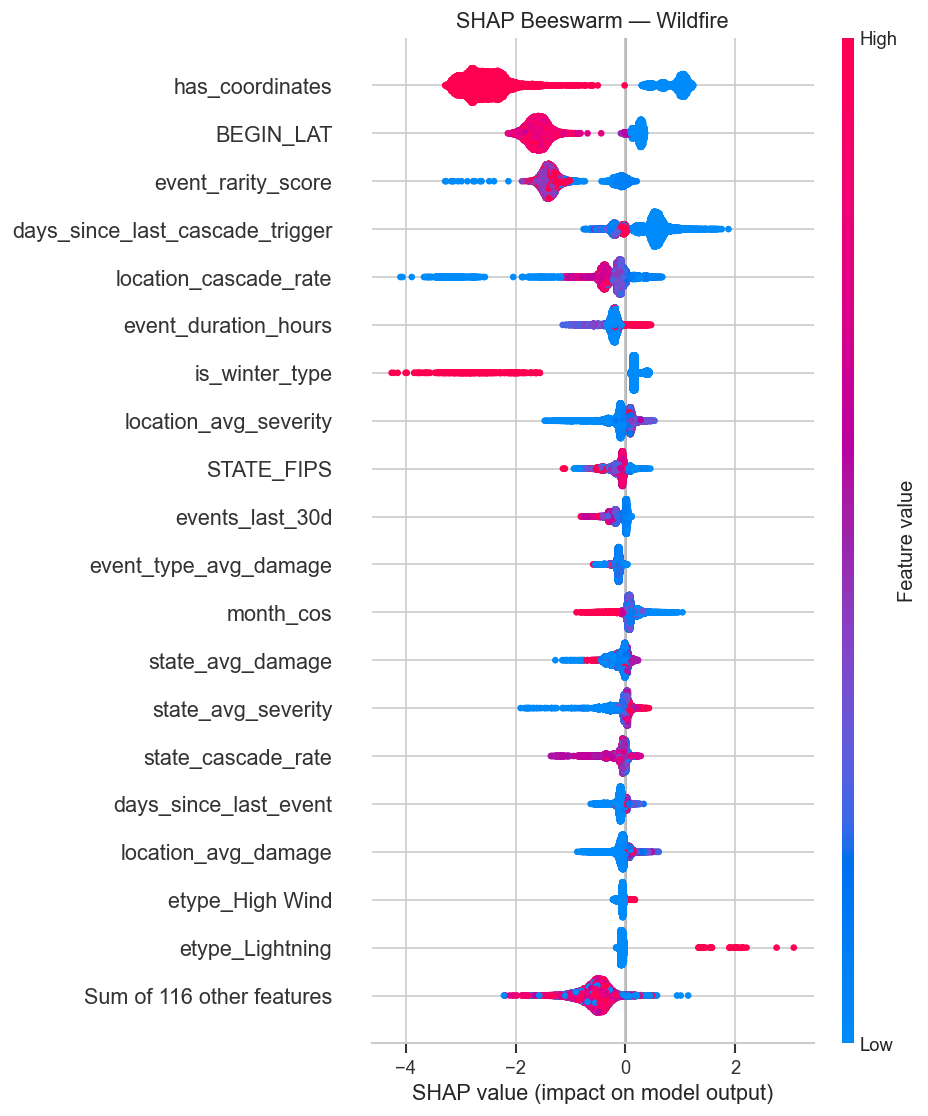

In [31]:
# ── Beeswarm plots for top-performing and worst-performing labels ───────
top_4 = perlabel.nlargest(4, 'f1')['label'].tolist()
bot_2 = perlabel[perlabel['f1'] > 0].nsmallest(2, 'f1')['label'].tolist()
beeswarm_labels = list(dict.fromkeys(top_4 + bot_2))

for label in beeswarm_labels:
    if label not in shap_values_dict:
        continue
    sv = shap_values_dict[label]
    f1_val = perlabel.loc[perlabel['label'] == label, 'f1'].values[0]
    print(f"\n{'='*60}")
    print(f"  {label}  (F1 = {f1_val:.3f})")
    print(f"{'='*60}")
    fig = plt.figure(figsize=(12, 7))
    shap.plots.beeswarm(sv, max_display=20, show=False)
    plt.title(f'SHAP Beeswarm — {label}', fontsize=13)
    plt.tight_layout()
    plt.show()

### 12c. SHAP Dependence Plots
How does a single feature's value relate to its SHAP contribution?  
Each point is colored by the feature with the strongest interaction effect.
This reveals non-linear relationships and interaction effects.

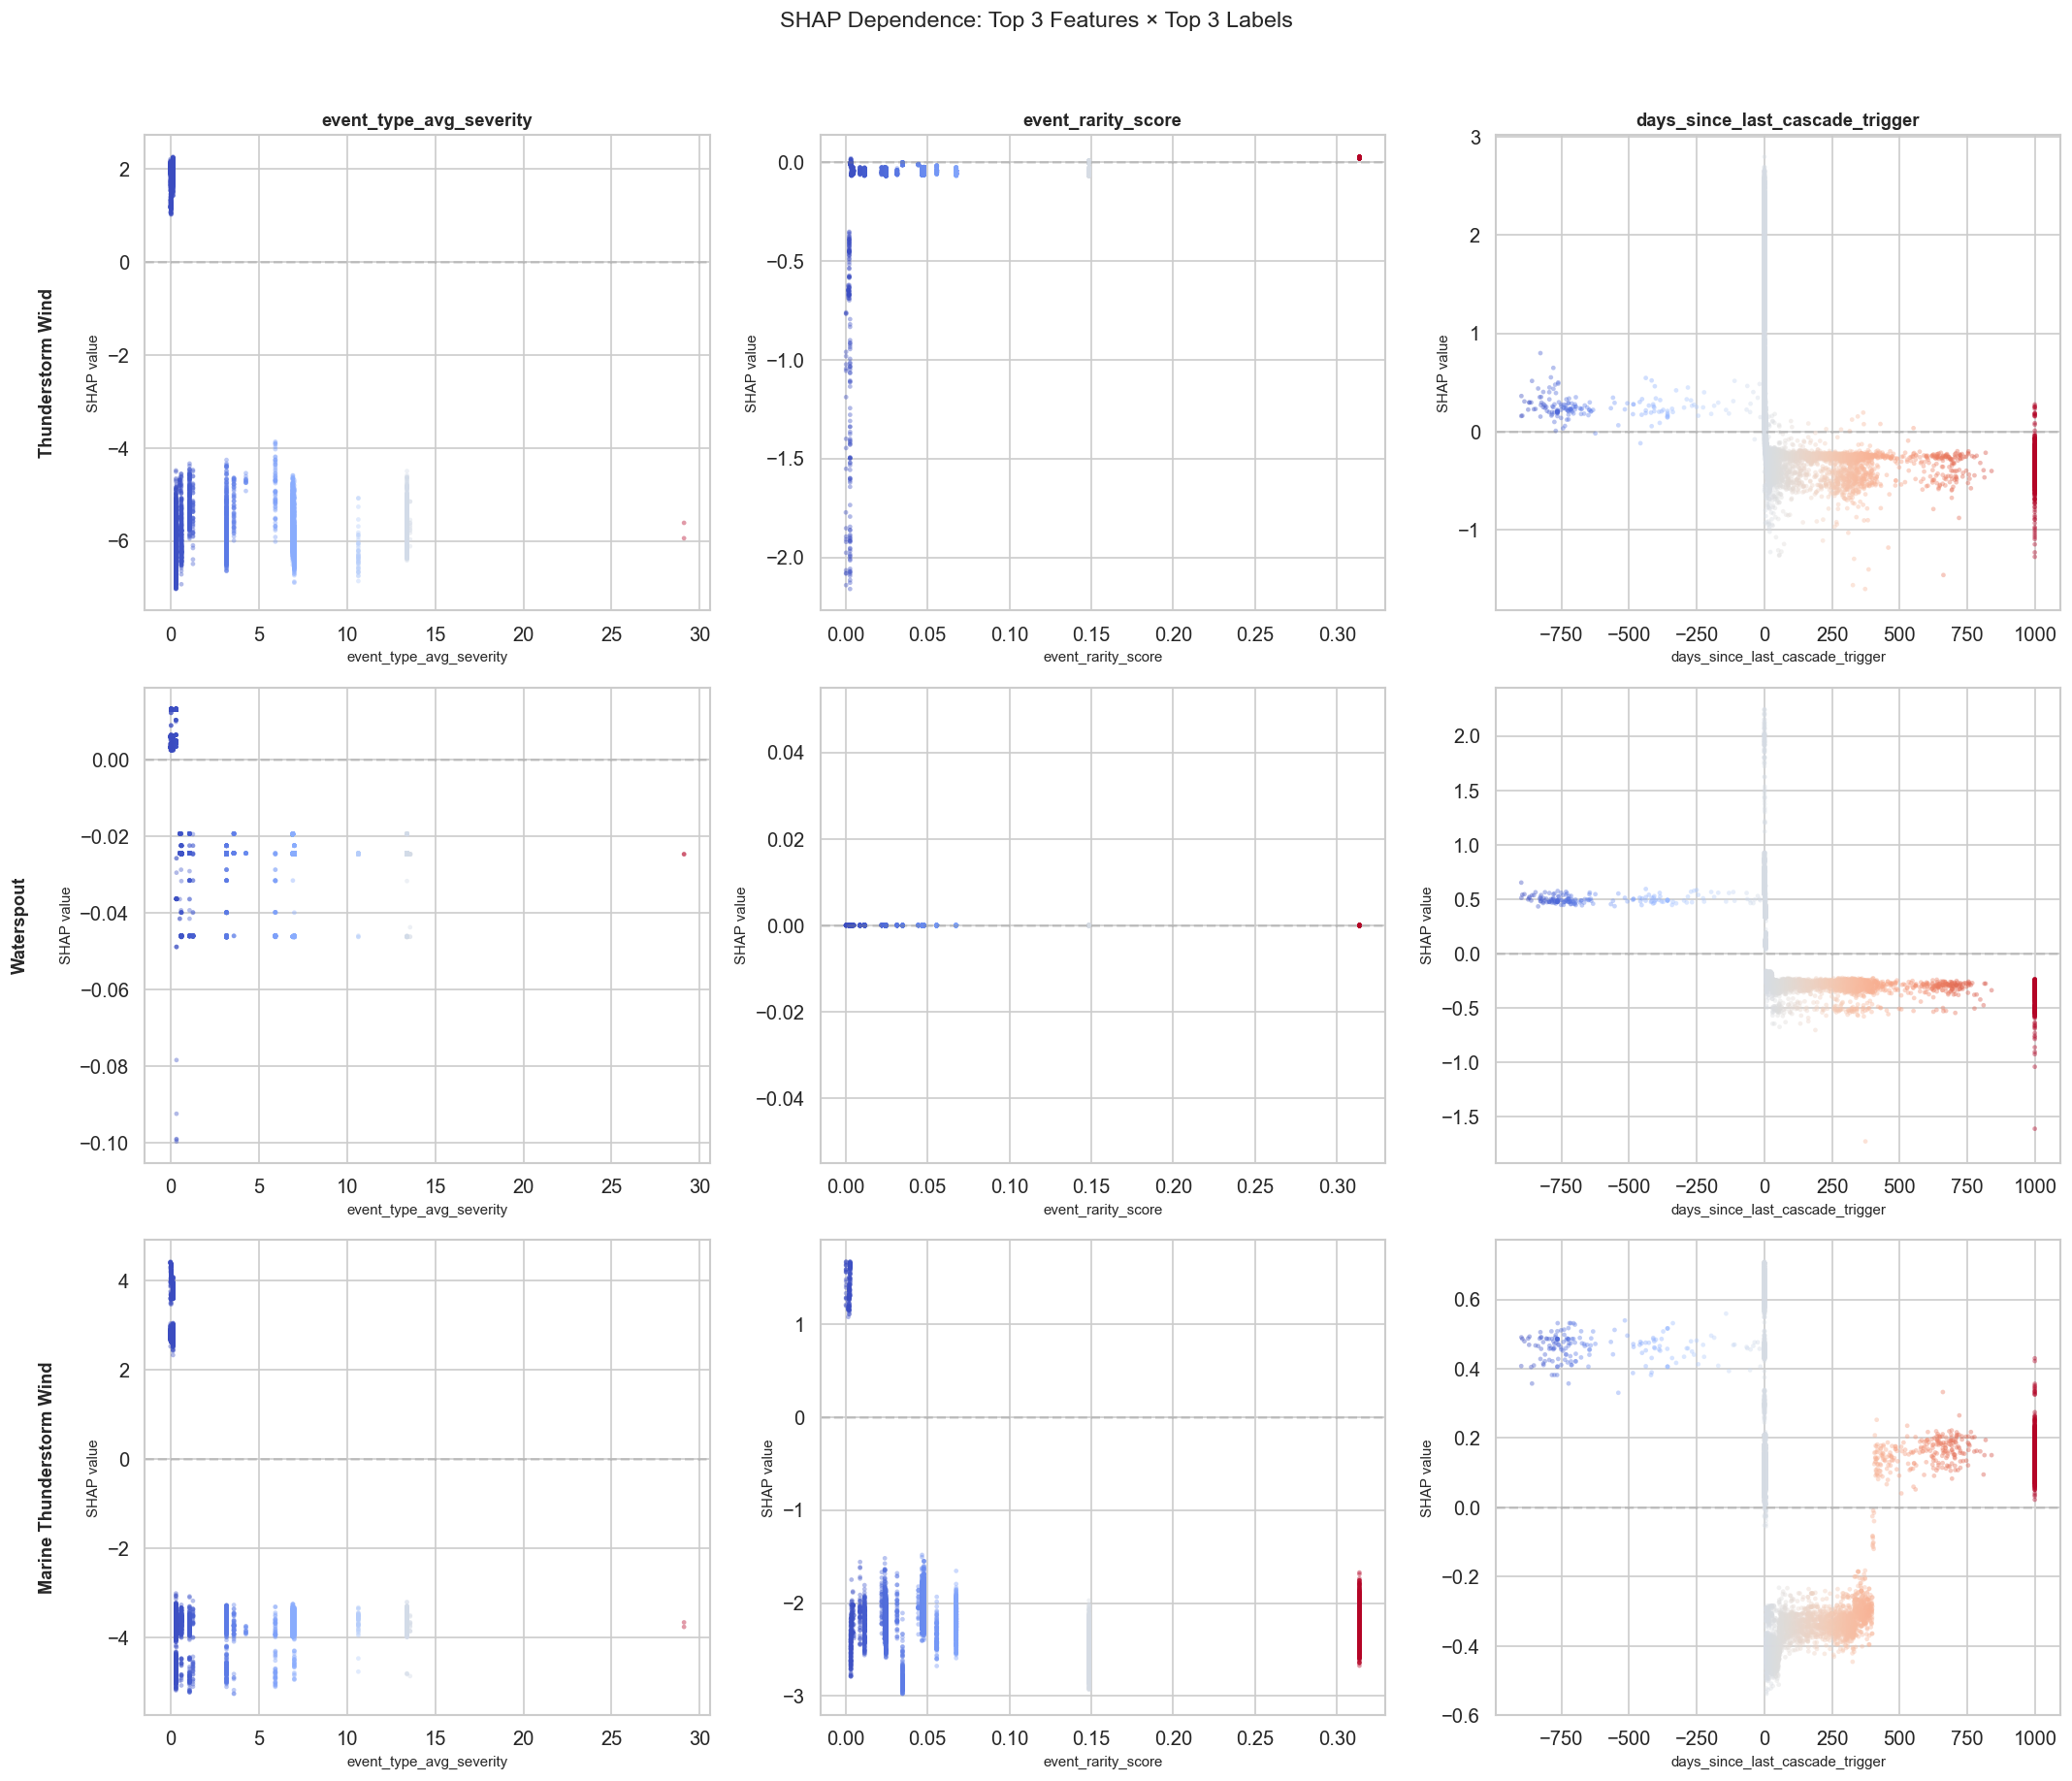

In [32]:
# ── Dependence plots for top 3 global features × top 3 labels ──────────
top_3_features = [feature_names[i] for i in shap_top_idx[:3]]
top_3_labels = perlabel.nlargest(3, 'f1')['label'].tolist()

fig, axes = plt.subplots(len(top_3_labels), len(top_3_features),
                         figsize=(6 * len(top_3_features), 5 * len(top_3_labels)))

for row, label in enumerate(top_3_labels):
    if label not in shap_values_dict:
        continue
    sv = shap_values_dict[label]
    for col, feat in enumerate(top_3_features):
        ax = axes[row, col] if len(top_3_labels) > 1 else axes[col]
        feat_idx = feature_names.index(feat)
        ax.scatter(
            sv.data[:, feat_idx],
            sv.values[:, feat_idx],
            c=sv.data[:, feat_idx],
            cmap='coolwarm', alpha=0.4, s=8, edgecolors='none'
        )
        ax.set_xlabel(feat, fontsize=9)
        ax.set_ylabel(f'SHAP value', fontsize=9)
        if row == 0:
            ax.set_title(feat, fontsize=11, fontweight='bold')
        if col == 0:
            ax.annotate(label, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 15, 0),
                       xycoords=ax.yaxis.label, textcoords='offset points',
                       fontsize=11, fontweight='bold', ha='right', va='center',
                       rotation=90)
        ax.axhline(0, color='gray', ls='--', alpha=0.3)

fig.suptitle('SHAP Dependence: Top 3 Features × Top 3 Labels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 12d. SHAP Waterfall Plots — Explaining Individual Predictions
Waterfall plots decompose a single prediction into the contribution of each feature.  
We show: (1) the highest-confidence true positive, (2) the highest-confidence false positive,
and (3) a missed positive (false negative) for the best-performing label.


  Thunderstorm Wind — True Positive (highest confidence)
  P(pos) = 0.9945  |  True = 1  |  Pred = 1


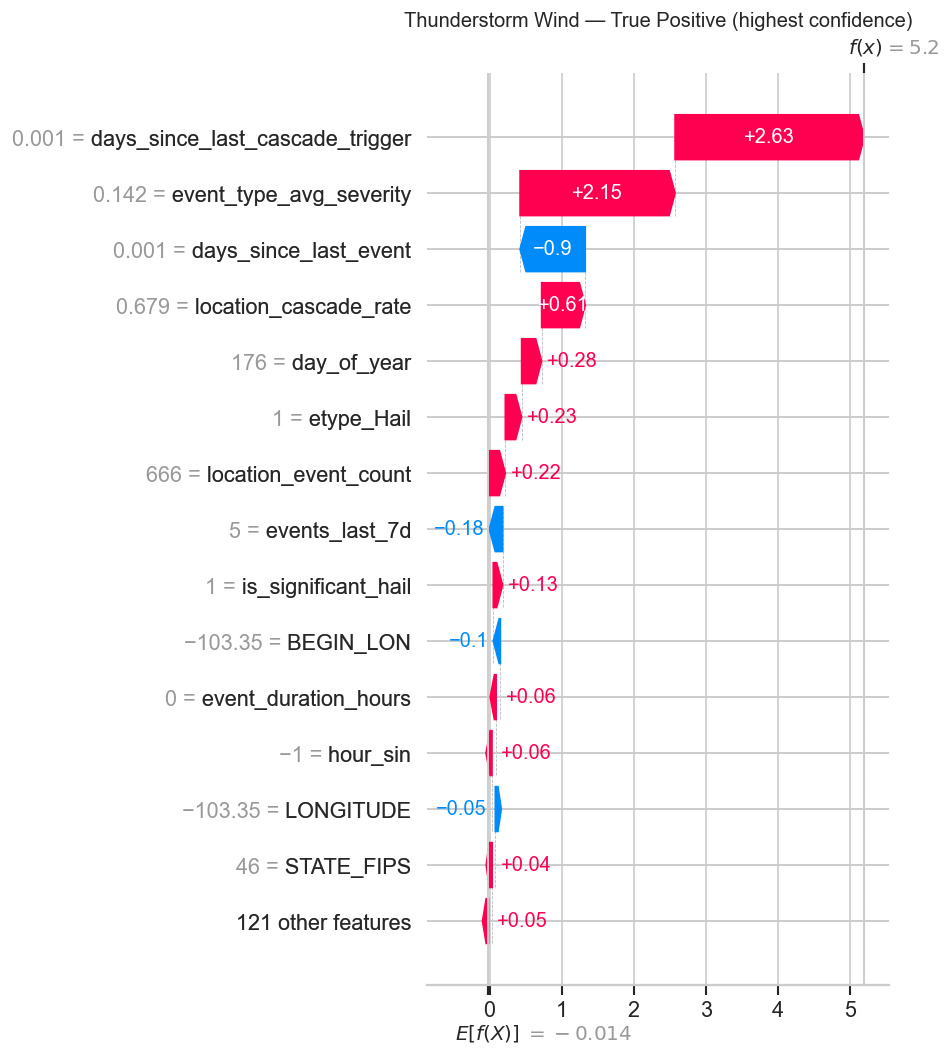


  Thunderstorm Wind — False Positive (highest confidence)
  P(pos) = 0.9934  |  True = 0  |  Pred = 1


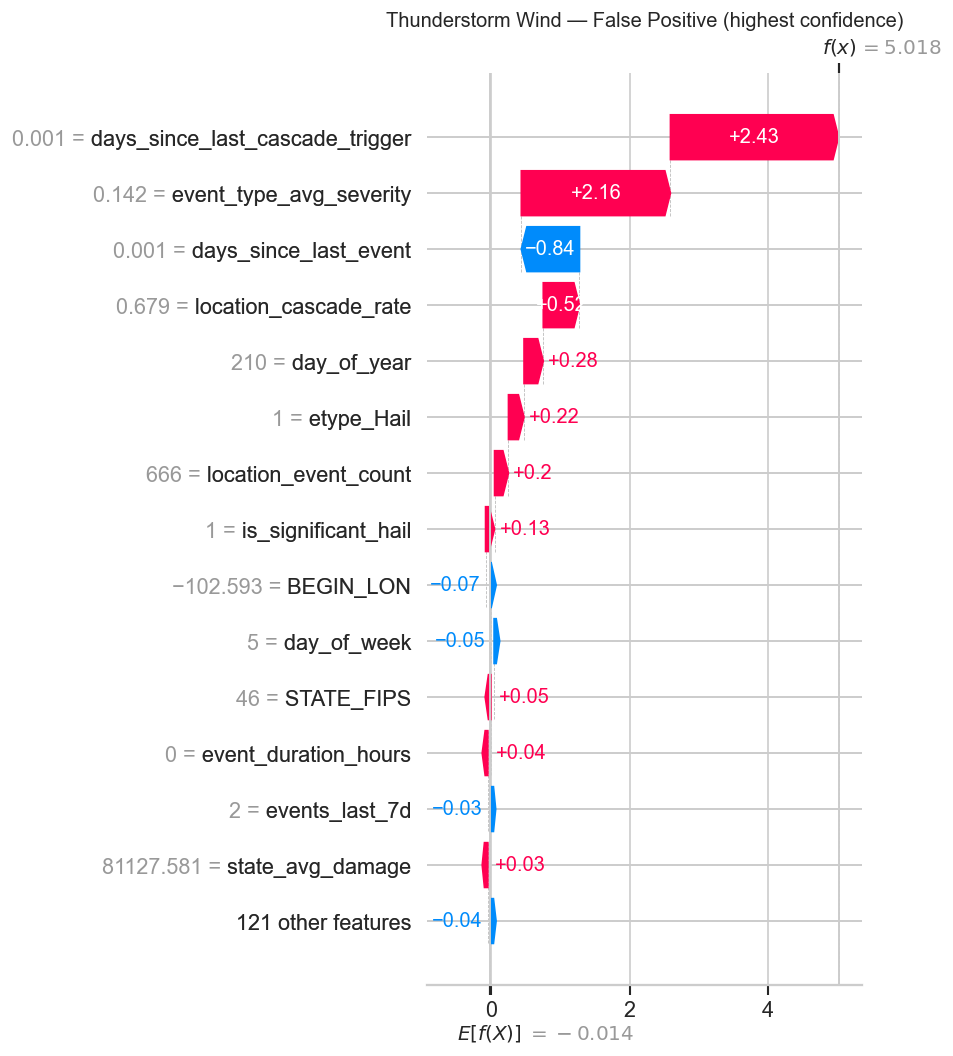


  Thunderstorm Wind — False Negative (highest-prob miss)
  P(pos) = 0.8814  |  True = 1  |  Pred = 0


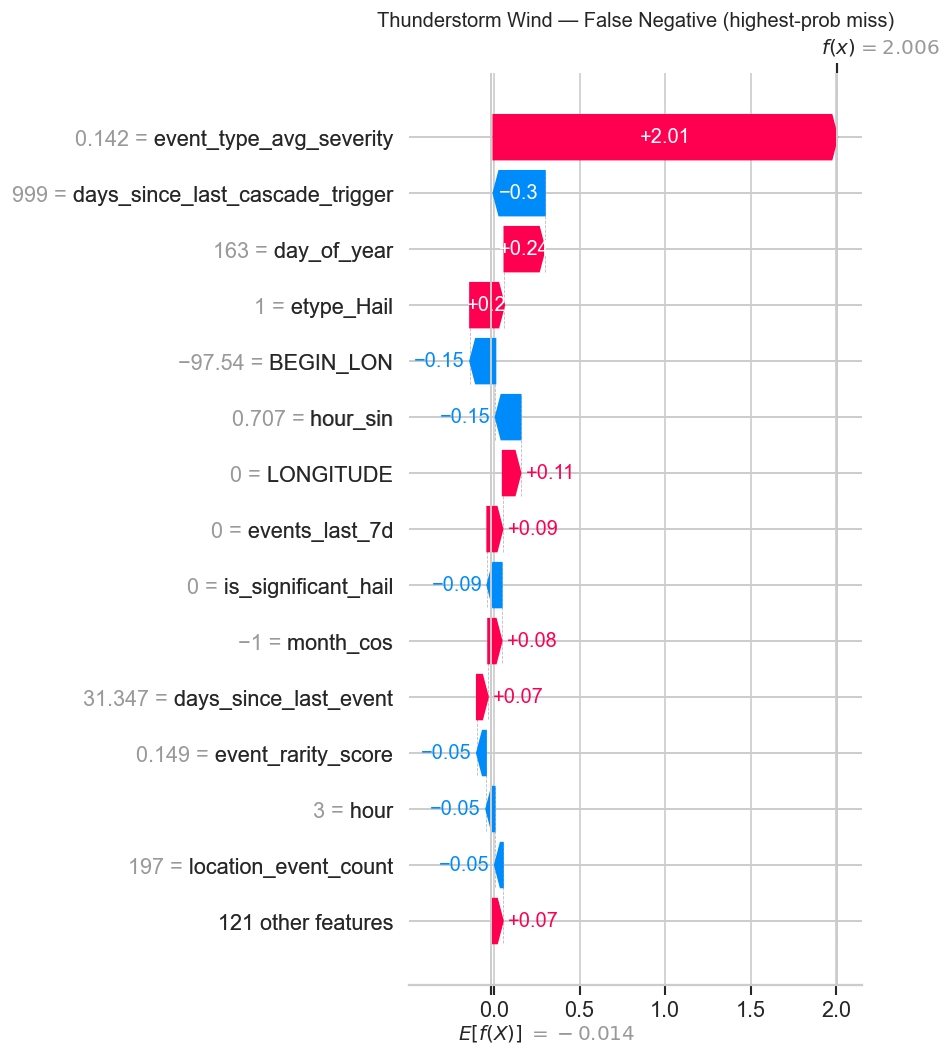

In [33]:
# ── Waterfall plots for best label: TP, FP, FN ─────────────────────────
best_label = perlabel.nlargest(1, 'f1')['label'].values[0]
best_sanitized = reverse_label_map.get(best_label, sanitize_label(best_label))
best_label_idx = target_names.index(best_label)

# Get predictions and ground truth for the SHAP subsample
y_shap_true = y_test[shap_idx, best_label_idx]
y_shap_prob = y_prob[shap_idx, best_label_idx]
y_shap_pred = y_pred[shap_idx, best_label_idx]

sv = shap_values_dict[best_label]

# Find exemplar indices
tp_mask = (y_shap_true == 1) & (y_shap_pred == 1)
fp_mask = (y_shap_true == 0) & (y_shap_pred == 1)
fn_mask = (y_shap_true == 1) & (y_shap_pred == 0)

cases = []
if tp_mask.any():
    tp_idx = np.where(tp_mask)[0][np.argmax(y_shap_prob[tp_mask])]
    cases.append(('True Positive (highest confidence)', tp_idx))
if fp_mask.any():
    fp_idx = np.where(fp_mask)[0][np.argmax(y_shap_prob[fp_mask])]
    cases.append(('False Positive (highest confidence)', fp_idx))
if fn_mask.any():
    fn_idx = np.where(fn_mask)[0][np.argmax(y_shap_prob[fn_mask])]
    cases.append(('False Negative (highest-prob miss)', fn_idx))

for title, sample_idx in cases:
    print(f"\n{'='*60}")
    print(f"  {best_label} — {title}")
    print(f"  P(pos) = {y_shap_prob[sample_idx]:.4f}  |  "
          f"True = {int(y_shap_true[sample_idx])}  |  "
          f"Pred = {int(y_shap_pred[sample_idx])}")
    print(f"{'='*60}")
    fig = plt.figure(figsize=(12, 6))
    shap.plots.waterfall(sv[sample_idx], max_display=15, show=False)
    plt.title(f'{best_label} — {title}', fontsize=12)
    plt.tight_layout()
    plt.show()

### 12e. Cross-Label SHAP Heatmap
Which features matter for which disaster types?  
Each cell shows the mean |SHAP| for a (feature, label) pair.  
This reveals **shared drivers** (features important everywhere) vs
**label-specific signals** (features that only matter for certain disasters).

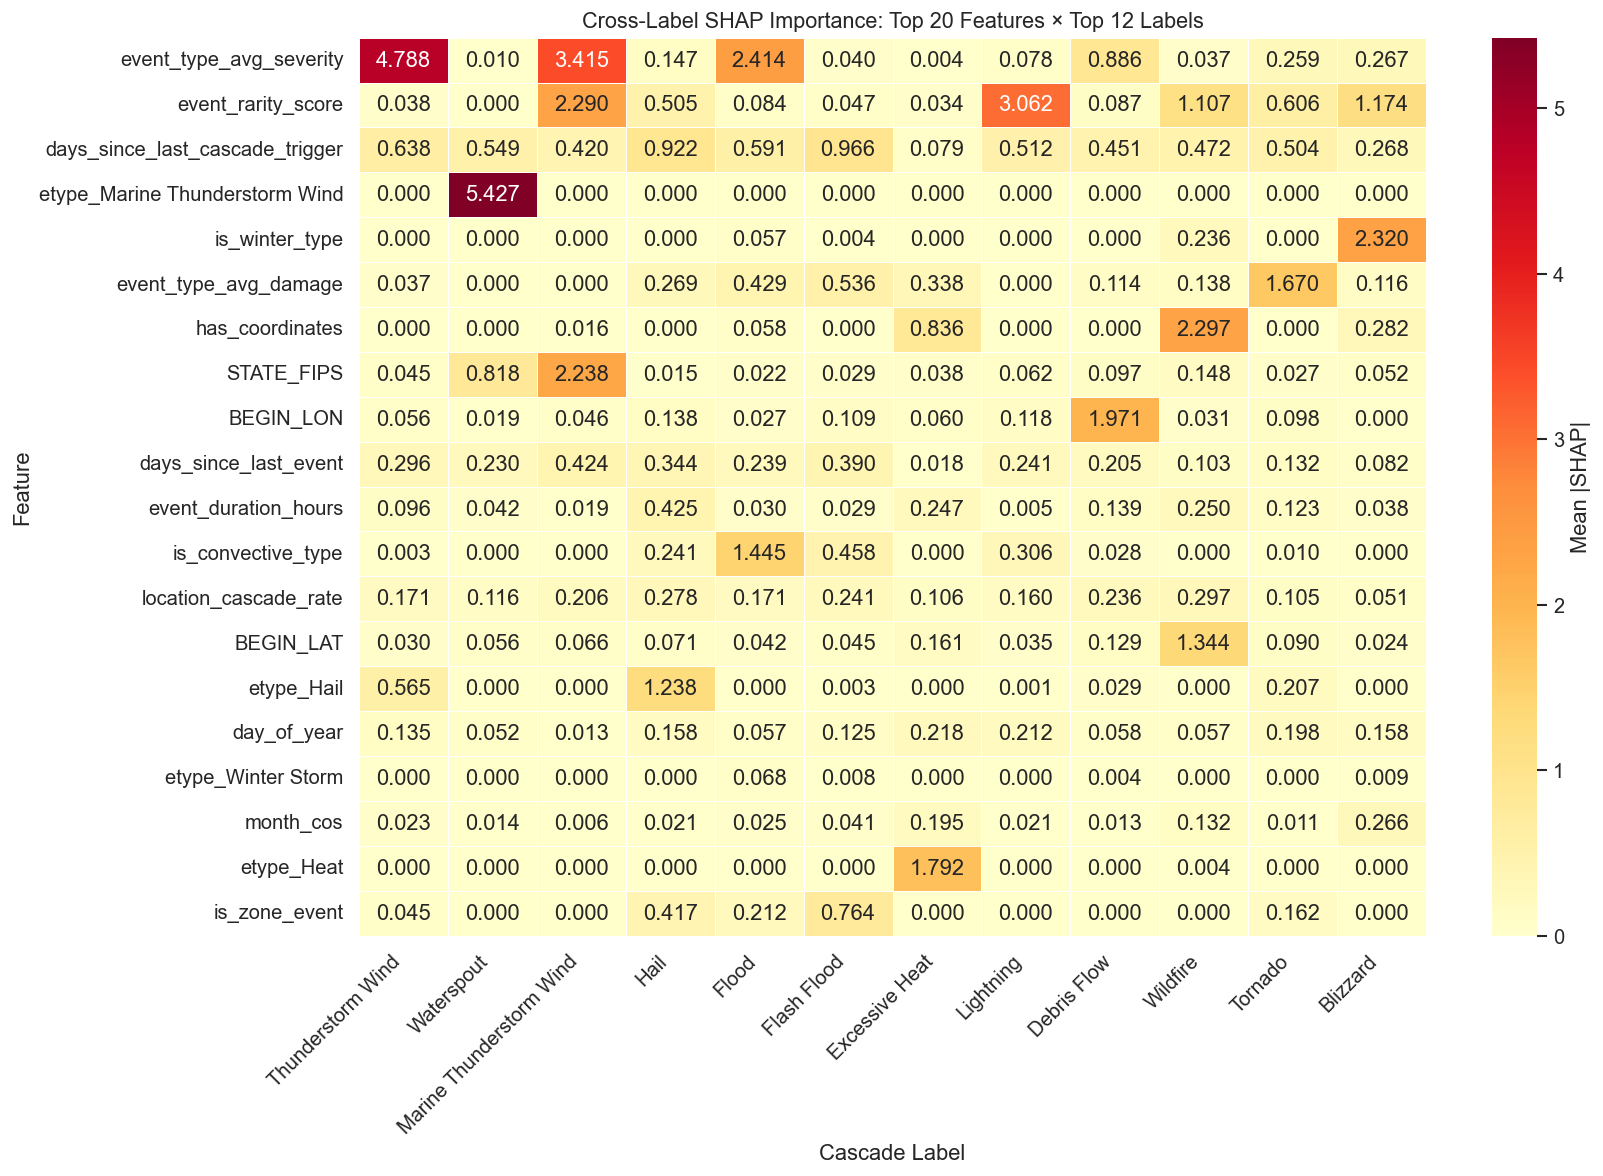


── Feature specificity analysis ──
Feature                              Mean |SHAP|    StdDev      CV             Type
-------------------------------------------------------------------------------------
  event_type_avg_severity                 1.0288    1.6143    1.57   LABEL-SPECIFIC
  event_rarity_score                      0.7527    1.0029    1.33         moderate
  days_since_last_cascade_trigger         0.5311    0.2439    0.46           SHARED
  etype_Marine Thunderstorm Wind          0.4522    1.5665    3.46   LABEL-SPECIFIC
  is_winter_type                          0.2181    0.6654    3.05   LABEL-SPECIFIC
  event_type_avg_damage                   0.3039    0.4657    1.53   LABEL-SPECIFIC
  has_coordinates                         0.2908    0.6772    2.33   LABEL-SPECIFIC
  STATE_FIPS                              0.2993    0.6500    2.17   LABEL-SPECIFIC
  BEGIN_LON                               0.2228    0.5524    2.48   LABEL-SPECIFIC
  days_since_last_event               

In [34]:
# ── Cross-label SHAP importance heatmap ─────────────────────────────────
n_top_feats = 20
n_top_labels = min(12, len(shap_values_dict))

# Get top labels by F1
heatmap_labels = perlabel.nlargest(n_top_labels, 'f1')['label'].tolist()
heatmap_labels = [l for l in heatmap_labels if l in shap_values_dict]

# Build the heatmap matrix
shap_heat = pd.DataFrame(index=[feature_names[i] for i in shap_top_idx[:n_top_feats]])
for label in heatmap_labels:
    sv = shap_values_dict[label]
    mean_abs = np.abs(sv.values).mean(axis=0)
    shap_heat[label] = mean_abs[shap_top_idx[:n_top_feats]]

fig, ax = plt.subplots(figsize=(max(14, n_top_labels * 1.2), 10))
sns.heatmap(shap_heat, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax, linewidths=.5, cbar_kws={'label': 'Mean |SHAP|'})
ax.set_title(f'Cross-Label SHAP Importance: Top {n_top_feats} Features × Top {len(heatmap_labels)} Labels',
             fontsize=13)
ax.set_ylabel('Feature')
ax.set_xlabel('Cascade Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── Identify shared vs label-specific features ────────────────────────
print("\n── Feature specificity analysis ──")
print(f"{'Feature':35s}  {'Mean |SHAP|':>11s}  {'StdDev':>8s}  {'CV':>6s}  {'Type':>15s}")
print("-" * 85)

for feat_name in shap_heat.index:
    row = shap_heat.loc[feat_name]
    mean_val = row.mean()
    std_val = row.std()
    cv = std_val / (mean_val + 1e-8)
    ftype = 'SHARED' if cv < 0.8 else 'LABEL-SPECIFIC' if cv > 1.5 else 'moderate'
    print(f"  {feat_name:33s}  {mean_val:>11.4f}  {std_val:>8.4f}  {cv:>6.2f}  {ftype:>15s}")

### 12f. SHAP Feature Interaction Effects
For the best-performing label, we compute approximate SHAP interaction values
to identify which **feature pairs** amplify each other's effect on the prediction.

Computing SHAP interaction values for 'Thunderstorm Wind' on 500 samples...
(This may take a minute...)

Top 15 Feature Interactions for 'Thunderstorm Wind':

  Feature A                  Feature B                   Interaction
  ------------------------------------------------------------------
  days_since_last_event      days_since_last_cascade_trigger       0.31748
  days_since_last_cascade_trigger  event_type_avg_severity         0.25751
  days_since_last_event      event_type_avg_severity         0.10398
  location_cascade_rate      event_type_avg_severity         0.09693
  day_of_year                event_type_avg_severity         0.05348
  days_since_last_cascade_trigger  events_last_7d                  0.04989
  etype_Hail                 days_since_last_cascade_trigger       0.04540
  events_last_7d             event_type_avg_severity         0.04411
  location_event_count       event_type_avg_severity         0.03810
  event_duration_hours       event_type_avg_severity      

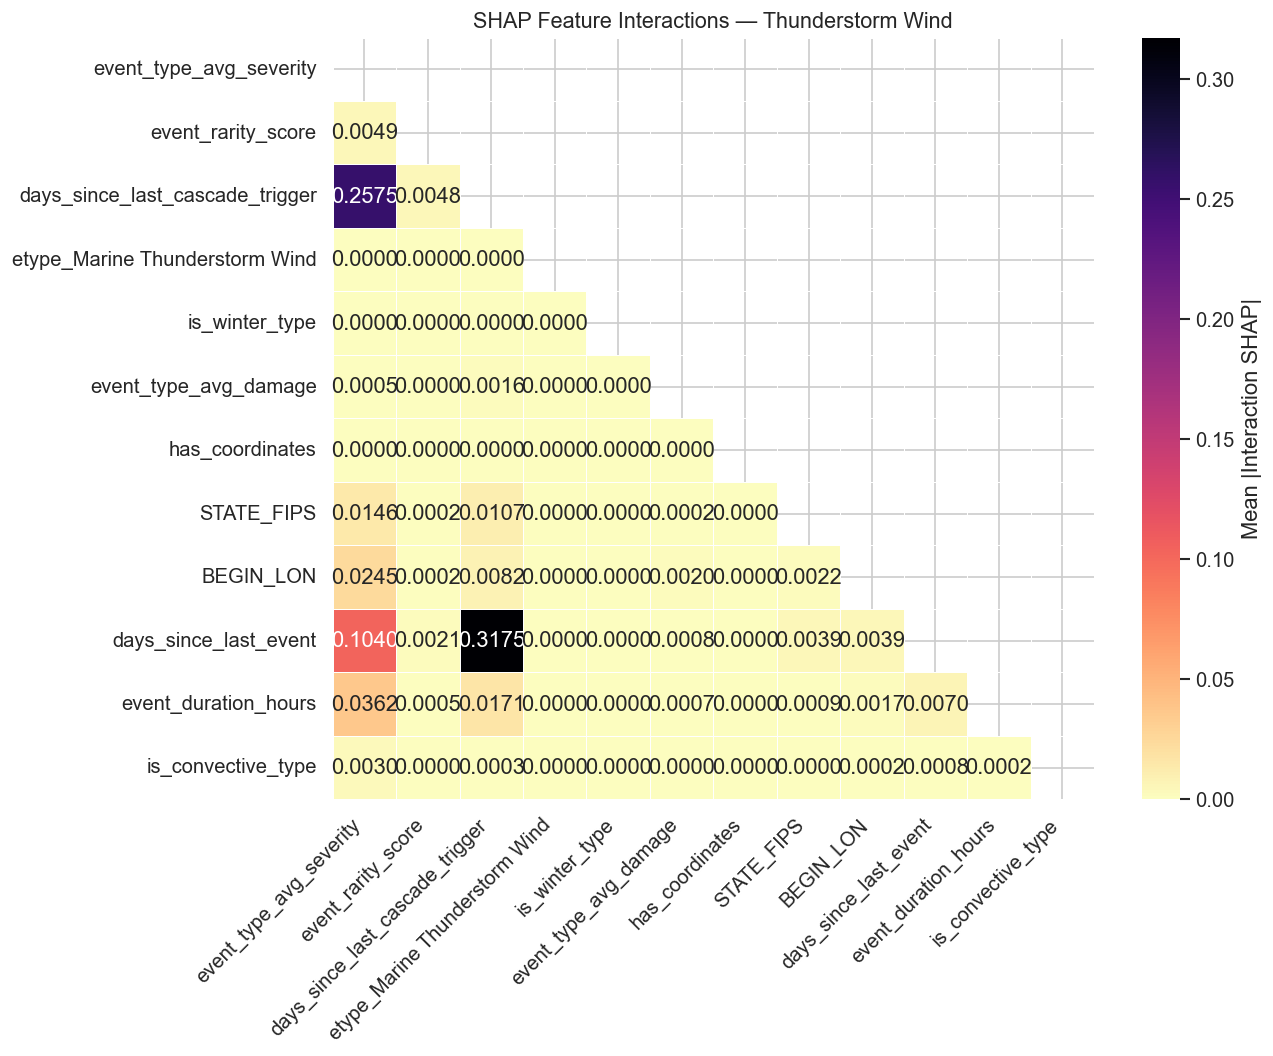

In [35]:
# ── SHAP interaction values for best label ─────────────────────────────
# Use a smaller subsample for interaction (it's O(n × features²))
INTERACTION_SAMPLE = min(500, SHAP_SAMPLE)
X_interact = X_shap[:INTERACTION_SAMPLE]

best_explainer = shap_explainer_dict[best_label]
print(f"Computing SHAP interaction values for '{best_label}' on {INTERACTION_SAMPLE} samples...")
print("(This may take a minute...)\n")

shap_interactions = best_explainer.shap_interaction_values(X_interact)

# Mean absolute interaction strength (off-diagonal = interactions)
mean_interact = np.abs(shap_interactions).mean(axis=0)
np.fill_diagonal(mean_interact, 0)  # zero out main effects

# Find top interactions
n_feat = len(feature_names)
interaction_pairs = []
for i in range(n_feat):
    for j in range(i+1, n_feat):
        interaction_pairs.append((feature_names[i], feature_names[j], mean_interact[i, j]))
interaction_pairs.sort(key=lambda x: -x[2])

print(f"Top 15 Feature Interactions for '{best_label}':\n")
print(f"  {'Feature A':25s}  {'Feature B':25s}  {'Interaction':>12s}")
print("  " + "-" * 66)
for f_a, f_b, val in interaction_pairs[:15]:
    print(f"  {f_a:25s}  {f_b:25s}  {val:>12.5f}")

# ── Interaction heatmap (top features) ────────────────────────────────
top_n_interact = 12
interact_feat_idx = shap_top_idx[:top_n_interact]
interact_sub = mean_interact[np.ix_(interact_feat_idx, interact_feat_idx)]
interact_labels = [feature_names[i] for i in interact_feat_idx]

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(interact_sub, dtype=bool), k=0)
sns.heatmap(interact_sub, mask=mask, annot=True, fmt='.4f', cmap='magma_r',
            xticklabels=interact_labels, yticklabels=interact_labels,
            ax=ax, linewidths=.5, cbar_kws={'label': 'Mean |Interaction SHAP|'})
ax.set_title(f'SHAP Feature Interactions — {best_label}', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 12g. SHAP-Based Sample Clustering
Cluster test samples by their SHAP profiles to discover **archetypes** — groups
of events that the model treats similarly. This reveals whether the model has
learned distinct "modes" for different types of cascading disasters.

Multi-label SHAP profile shape: (20000, 1620)
  (20000 samples × 12 labels × 135 features)


/Users/shikhabhat/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shikhabhat/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shikhabhat/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/shikhabhat/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/shikhabhat/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/shikhabhat/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul


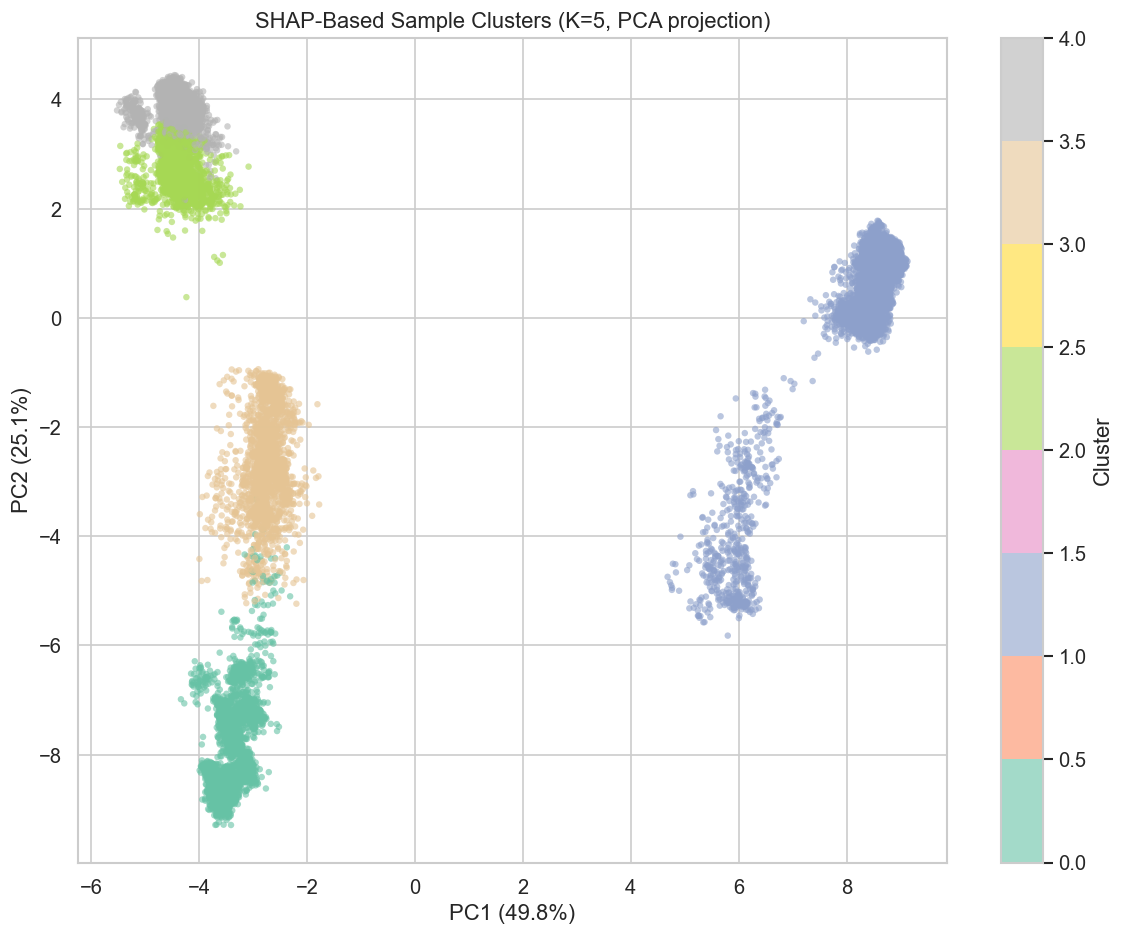


── Cluster Characterisation ──

Cluster 0  (n=3,249, 16.2%)
    Excessive Heat                   48.5% positive
    Heat                             36.8% positive
    Cold/Wind Chill                   3.6% positive
    Wildfire                          2.9% positive
    Blizzard                          2.8% positive
    Top distinguishing features (Thunderstorm Wind):
      ↓ event_type_avg_severity    (ΔSHAP = -2.1185)
      ↓ days_since_last_cascade_trigger  (ΔSHAP = -0.4741)
      ↓ event_duration_hours       (ΔSHAP = -0.2633)

Cluster 1  (n=6,407, 32.0%)
    Thunderstorm Wind                81.3% positive
    Flash Flood                      25.1% positive
    Lightning                         2.7% positive
    Waterspout                        2.5% positive
    Heat                              1.8% positive
    Top distinguishing features (Thunderstorm Wind):
      ↑ event_type_avg_severity    (ΔSHAP = +5.5081)
      ↑ etype_Hail                 (ΔSHAP = +0.5782)
      ↑ days_

In [36]:
# ── Cluster samples by SHAP profiles ───────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Stack SHAP values across all trained labels to get a multi-label SHAP profile
all_sv_matrices = []
sv_label_names = []
for label in heatmap_labels:
    if label in shap_values_dict:
        all_sv_matrices.append(shap_values_dict[label].values)
        sv_label_names.append(label)

# Concatenate: (n_samples, n_features × n_labels)
multi_shap = np.concatenate(all_sv_matrices, axis=1)
print(f"Multi-label SHAP profile shape: {multi_shap.shape}")
print(f"  ({multi_shap.shape[0]} samples × {len(sv_label_names)} labels × {len(feature_names)} features)")

# K-Means clustering
N_CLUSTERS = 5
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
clusters = km.fit_predict(multi_shap)

# PCA for 2D visualisation
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(multi_shap)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap='Set2',
                     alpha=0.6, s=15, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'SHAP-Based Sample Clusters (K={N_CLUSTERS}, PCA projection)')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

# ── Cluster characterisation ──────────────────────────────────────────
print(f"\n── Cluster Characterisation ──\n")
y_shap_test = y_test[shap_idx]

for c in range(N_CLUSTERS):
    mask_c = clusters == c
    n_c = mask_c.sum()
    print(f"Cluster {c}  (n={n_c:,}, {n_c/len(clusters)*100:.1f}%)")

    # What labels are most common in this cluster?
    label_prevalence = []
    for i, label in enumerate(target_names):
        pct = y_shap_test[mask_c, i].mean() * 100
        if pct > 0.5:
            label_prevalence.append((label, pct))
    label_prevalence.sort(key=lambda x: -x[1])

    if label_prevalence:
        for lbl, pct in label_prevalence[:5]:
            print(f"    {lbl:30s}  {pct:5.1f}% positive")
    else:
        print(f"    (mostly negative samples)")

    # Top distinguishing features (mean SHAP in cluster vs overall)
    cluster_shap_mean = multi_shap[mask_c].mean(axis=0)
    overall_shap_mean = multi_shap.mean(axis=0)
    diff = cluster_shap_mean - overall_shap_mean

    # Take just the first label's features for interpretability
    if len(sv_label_names) > 0:
        first_label_diff = diff[:len(feature_names)]
        top_diff_idx = np.argsort(np.abs(first_label_diff))[::-1][:3]
        print(f"    Top distinguishing features ({sv_label_names[0]}):")
        for di in top_diff_idx:
            direction = "↑" if first_label_diff[di] > 0 else "↓"
            print(f"      {direction} {feature_names[di]:25s}  (ΔSHAP = {first_label_diff[di]:+.4f})")
    print()

### 12h. SHAP Force Plots — Multi-Sample View
An aggregated force plot showing how features push predictions for many samples
simultaneously. Samples are sorted by prediction magnitude to reveal patterns.

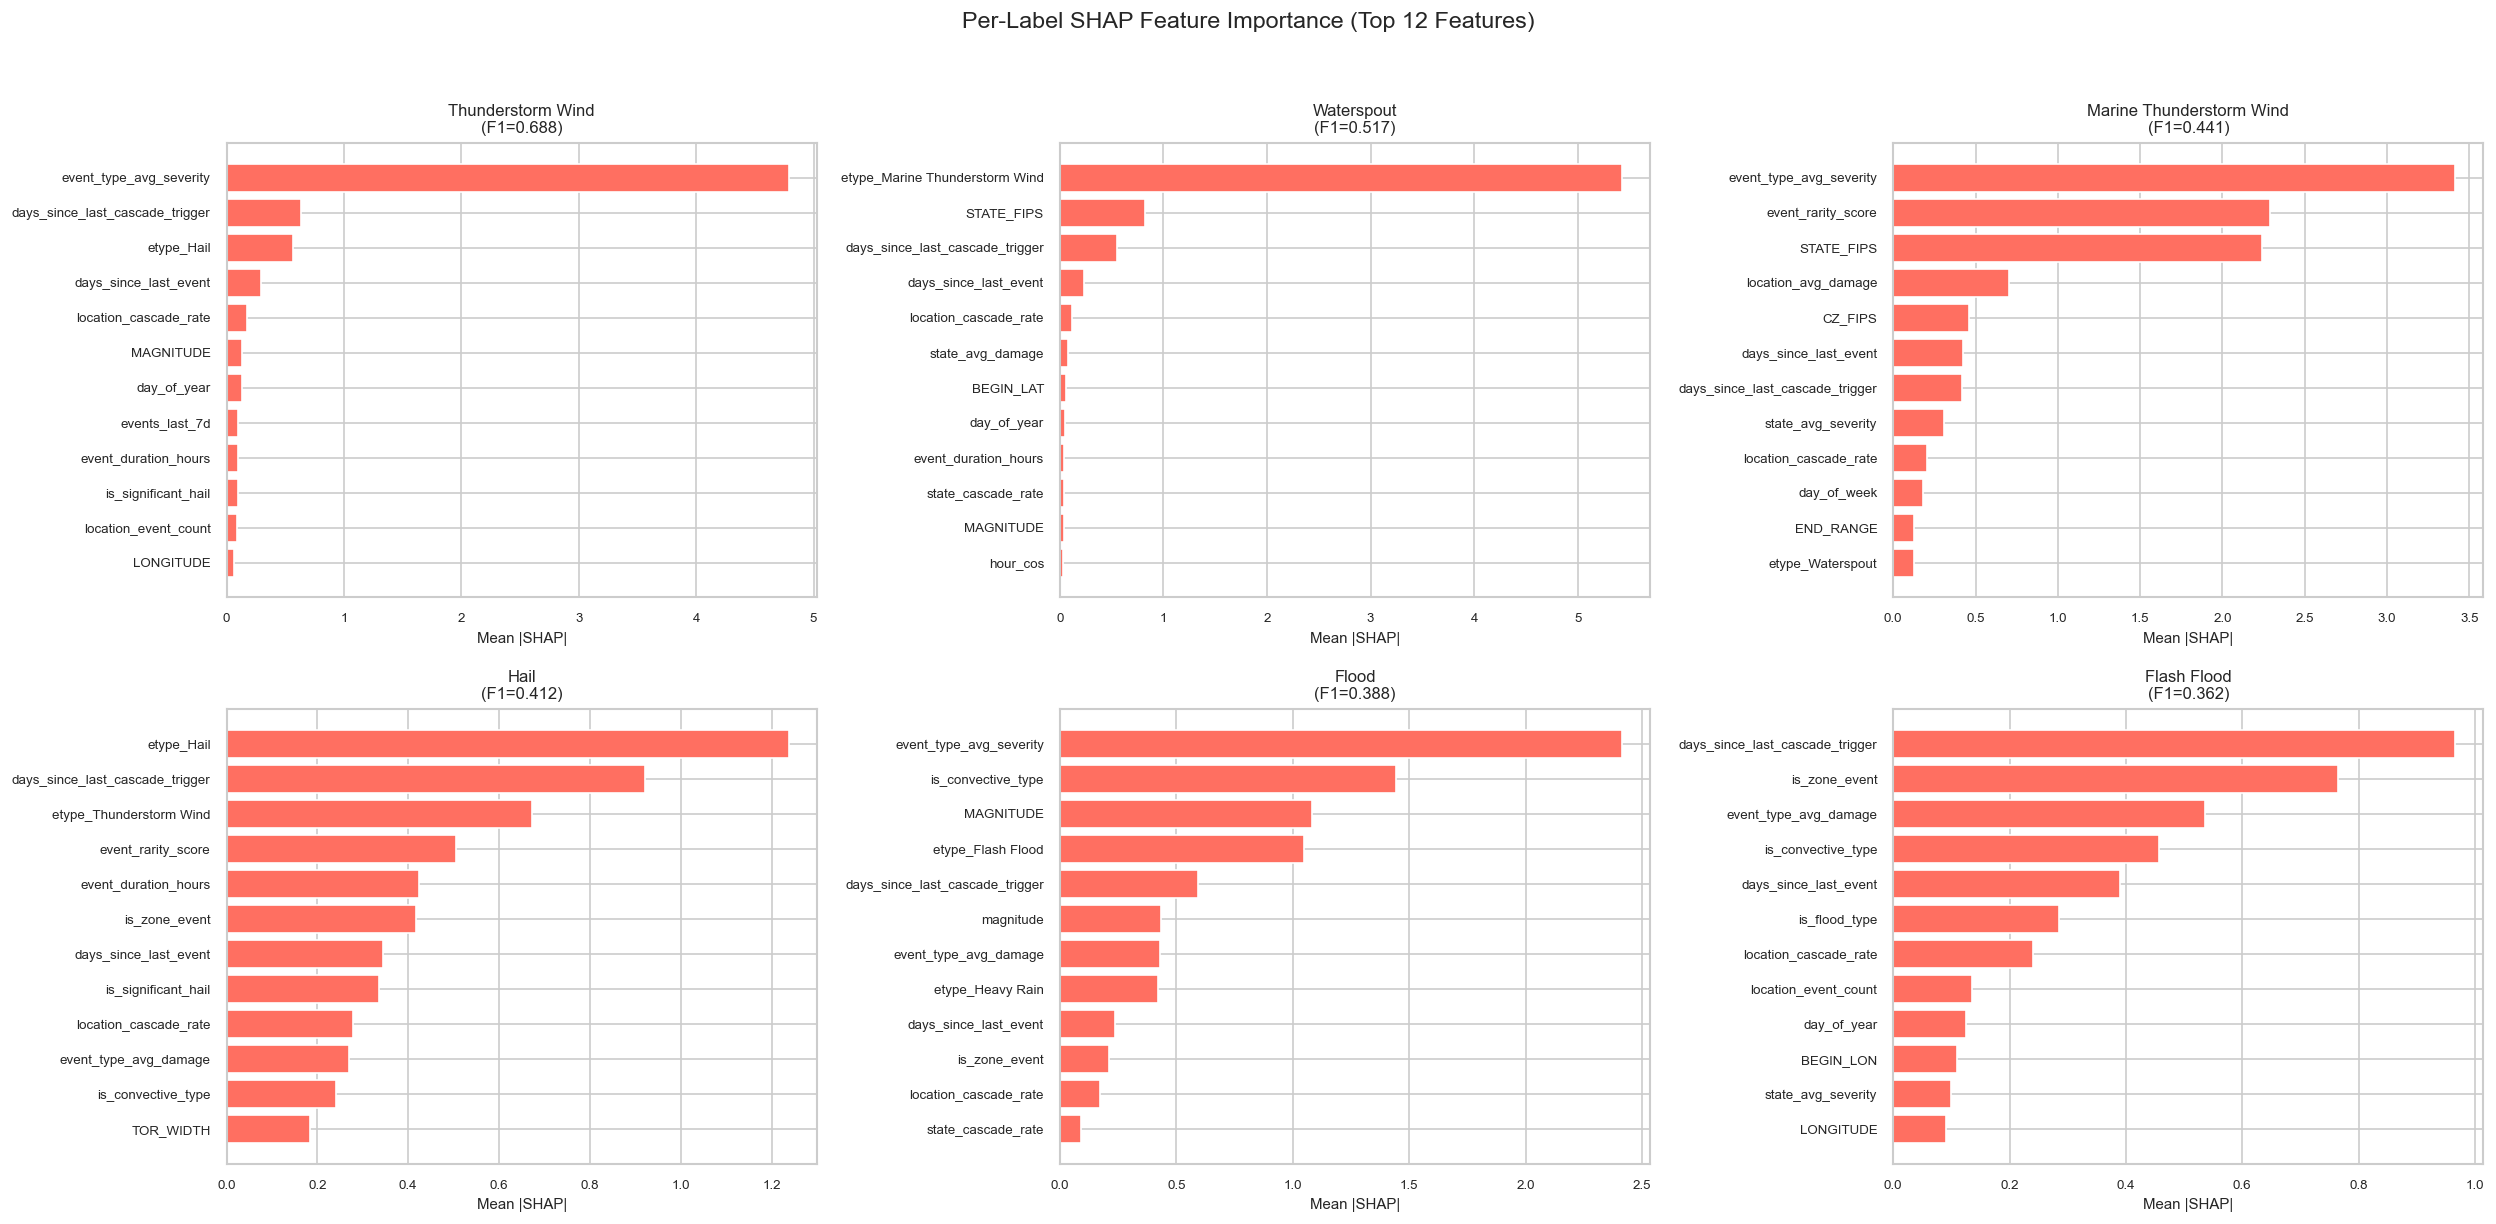

In [37]:
# ── SHAP bar plots per label (compact multi-label overview) ────────────
# Shows mean |SHAP| for top features per label, side by side
n_show = min(6, len(shap_values_dict))
show_labels_shap = perlabel.nlargest(n_show, 'f1')['label'].tolist()
show_labels_shap = [l for l in show_labels_shap if l in shap_values_dict]

n_cols = 3
n_rows = (len(show_labels_shap) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows))
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for ax_i, label in enumerate(show_labels_shap):
    ax = axes_flat[ax_i]
    sv = shap_values_dict[label]
    mean_abs = np.abs(sv.values).mean(axis=0)
    top_feat = np.argsort(mean_abs)[::-1][:12]

    ax.barh(
        [feature_names[i] for i in reversed(top_feat)],
        [mean_abs[i] for i in reversed(top_feat)],
        color='#ff6f61', edgecolor='white'
    )
    f1_val = perlabel.loc[perlabel['label'] == label, 'f1'].values[0]
    ax.set_title(f'{label}\n(F1={f1_val:.3f})', fontsize=10)
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.tick_params(labelsize=8)

# Hide unused axes
for ax_i in range(len(show_labels_shap), len(axes_flat)):
    axes_flat[ax_i].set_visible(False)

fig.suptitle('Per-Label SHAP Feature Importance (Top 12 Features)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 12i. SHAP Feature Direction Summary
For each label, summarize whether each top feature has a **positive** or **negative**
directional relationship — e.g., "higher latitude → more likely to predict Winter Storm".

/Users/shikhabhat/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/shikhabhat/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


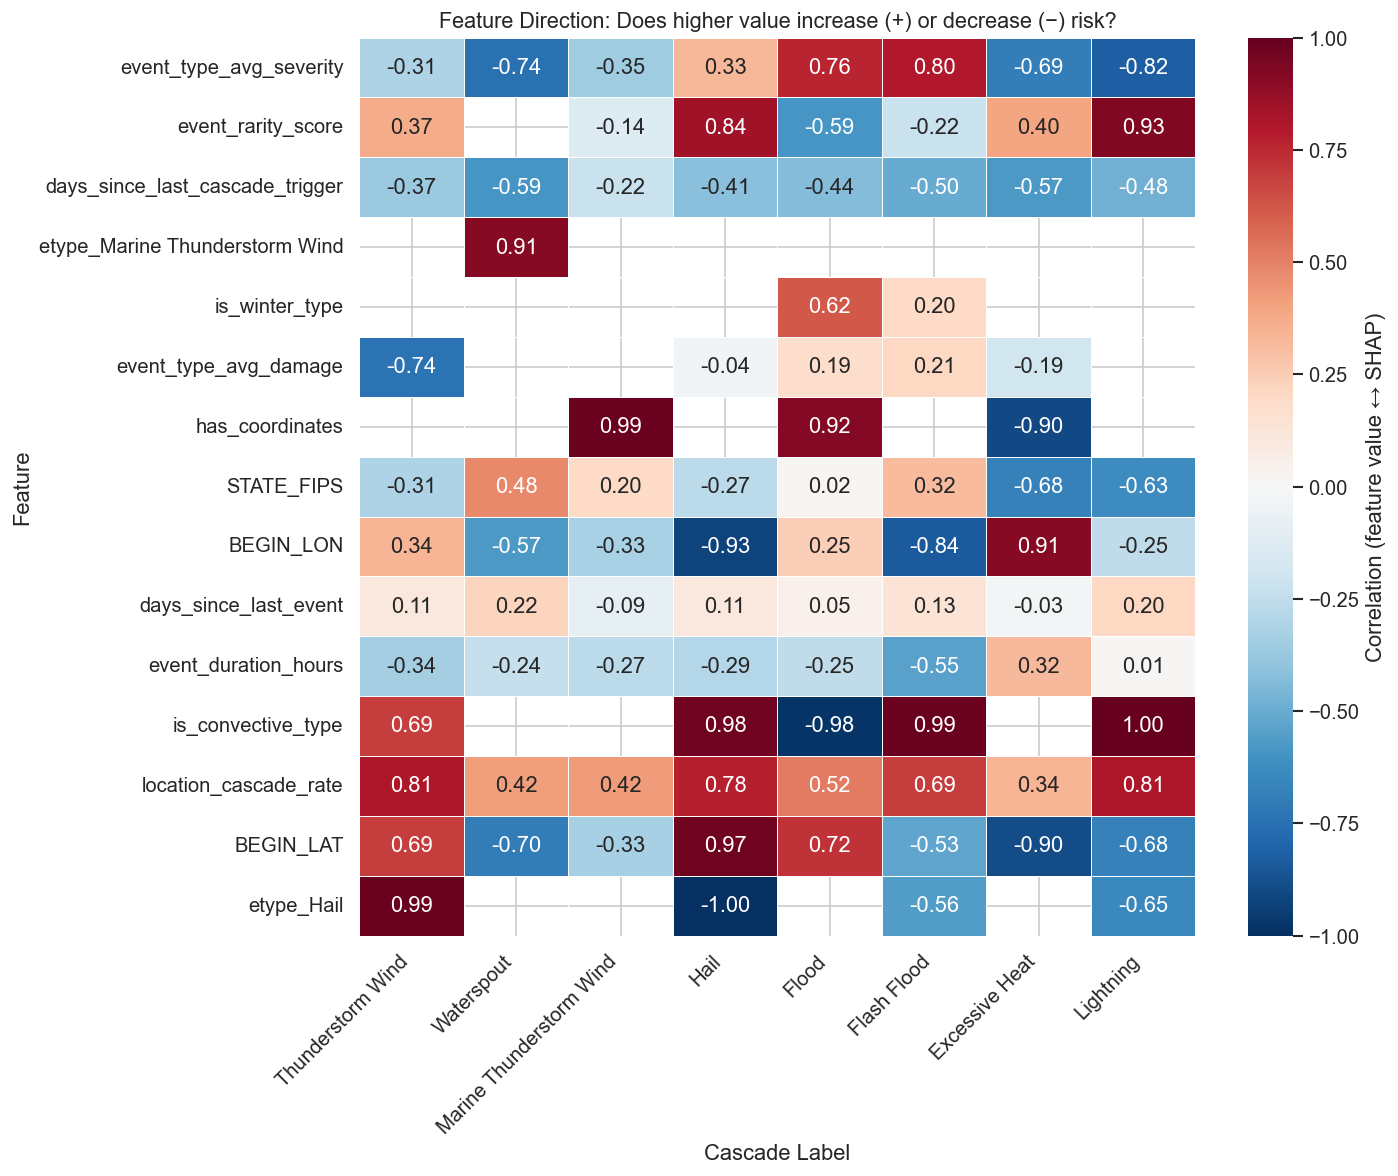


Interpretation:
  +1.0 (red)  = Higher feature value → STRONGER prediction of this disaster
  -1.0 (blue) = Higher feature value → WEAKER prediction of this disaster
   0.0 (white) = No clear linear direction (may have non-linear effects)


In [38]:
# ── Feature direction analysis ──────────────────────────────────────────
# For each label × feature, compute the correlation between feature value
# and SHAP value. Positive = higher feature value → higher risk.

direction_labels = perlabel.nlargest(8, 'f1')['label'].tolist()
direction_labels = [l for l in direction_labels if l in shap_values_dict]
direction_feats = [feature_names[i] for i in shap_top_idx[:15]]

direction_matrix = pd.DataFrame(index=direction_feats, columns=direction_labels, dtype=float)

for label in direction_labels:
    sv = shap_values_dict[label]
    for feat in direction_feats:
        fi = feature_names.index(feat)
        # Correlation between feature value and SHAP value
        corr = np.corrcoef(sv.data[:, fi], sv.values[:, fi])[0, 1]
        direction_matrix.loc[feat, label] = corr

fig, ax = plt.subplots(figsize=(max(12, len(direction_labels) * 1.3), 10))
sns.heatmap(direction_matrix.astype(float), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=.5, cbar_kws={'label': 'Correlation (feature value ↔ SHAP)'})
ax.set_title('Feature Direction: Does higher value increase (+) or decrease (−) risk?', fontsize=13)
ax.set_ylabel('Feature')
ax.set_xlabel('Cascade Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  +1.0 (red)  = Higher feature value → STRONGER prediction of this disaster")
print("  -1.0 (blue) = Higher feature value → WEAKER prediction of this disaster")
print("   0.0 (white) = No clear linear direction (may have non-linear effects)")

### 12j. SHAP Interpretation Summary
Key takeaways from the SHAP analysis.

In [39]:
# ── Auto-generated SHAP summary ────────────────────────────────────────
print("╔═══════════════════════════════════════════════════════════════╗")
print("║              SHAP Interpretability Summary                   ║")
print("╠═══════════════════════════════════════════════════════════════╣")

# Top 5 most important features globally
print("║                                                               ║")
print("║  Top 5 Most Important Features (Global SHAP):                ║")
for rank, idx in enumerate(shap_top_idx[:5], 1):
    print(f"║    {rank}. {feature_names[idx]:45s}  ({all_shap_abs[idx]:.4f})  ║")

# Most/least interpretable labels
print("║                                                               ║")
print("║  Model Performance Summary:                                   ║")
best_row = perlabel.nlargest(1, 'f1').iloc[0]
worst_row = perlabel[perlabel['f1'] > 0].nsmallest(1, 'f1').iloc[0]
print(f"║    Best label:  {best_row['label']:30s} (F1={best_row['f1']:.3f})  ║")
print(f"║    Worst label: {worst_row['label']:30s} (F1={worst_row['f1']:.3f})  ║")

# Interaction summary
print("║                                                               ║")
print("║  Strongest Feature Interaction:                               ║")
if interaction_pairs:
    top_pair = interaction_pairs[0]
    print(f"║    {top_pair[0]} × {top_pair[1]}          ║")
    print(f"║    (interaction strength: {top_pair[2]:.5f})                        ║")

# Cluster summary
print("║                                                               ║")
print("║  Sample Archetypes:                                           ║")
for c in range(N_CLUSTERS):
    n_c = (clusters == c).sum()
    print(f"║    Cluster {c}: {n_c:>5,} samples ({n_c/len(clusters)*100:>5.1f}%)                     ║")

print("║                                                               ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║              SHAP Interpretability Summary                   ║
╠═══════════════════════════════════════════════════════════════╣
║                                                               ║
║  Top 5 Most Important Features (Global SHAP):                ║
║    1. event_type_avg_severity                        (0.8982)  ║
║    2. event_rarity_score                             (0.7178)  ║
║    3. days_since_last_cascade_trigger                (0.4371)  ║
║    4. etype_Marine Thunderstorm Wind                 (0.3392)  ║
║    5. is_winter_type                                 (0.3330)  ║
║                                                               ║
║  Model Performance Summary:                                   ║
║    Best label:  Thunderstorm Wind              (F1=0.688)  ║
║    Worst label: Tornado                        (F1=0.004)  ║
║                                                               ║
║  Strongest 

Saved ../results/xgboost/xgb_overall_metrics.csv
Saved ../results/xgboost/xgb_perlabel_metrics.csv


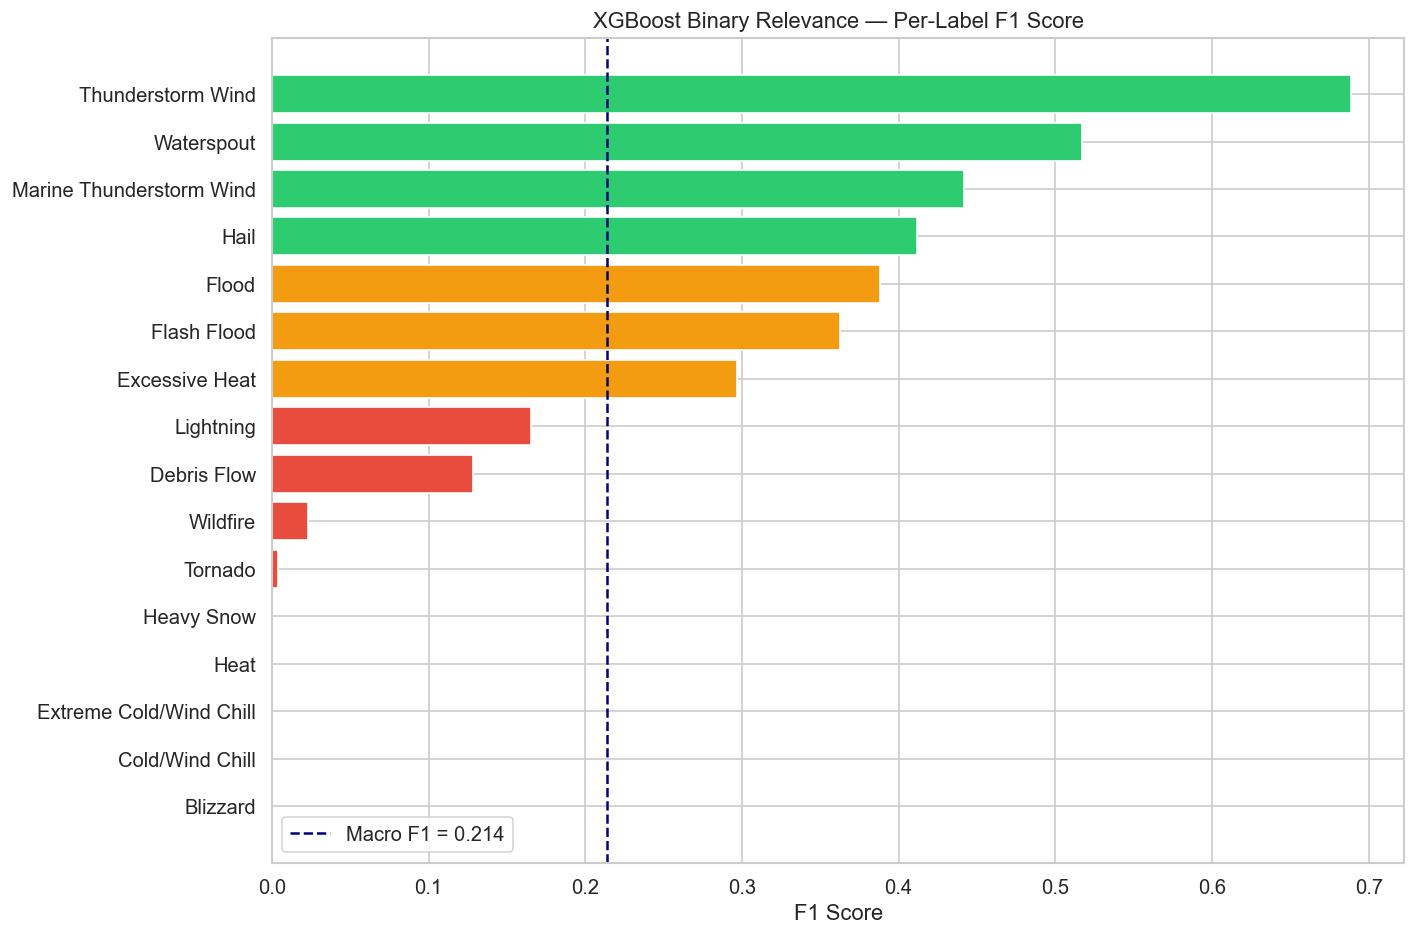

Saved ../results/xgboost/xgb_perlabel_f1.png


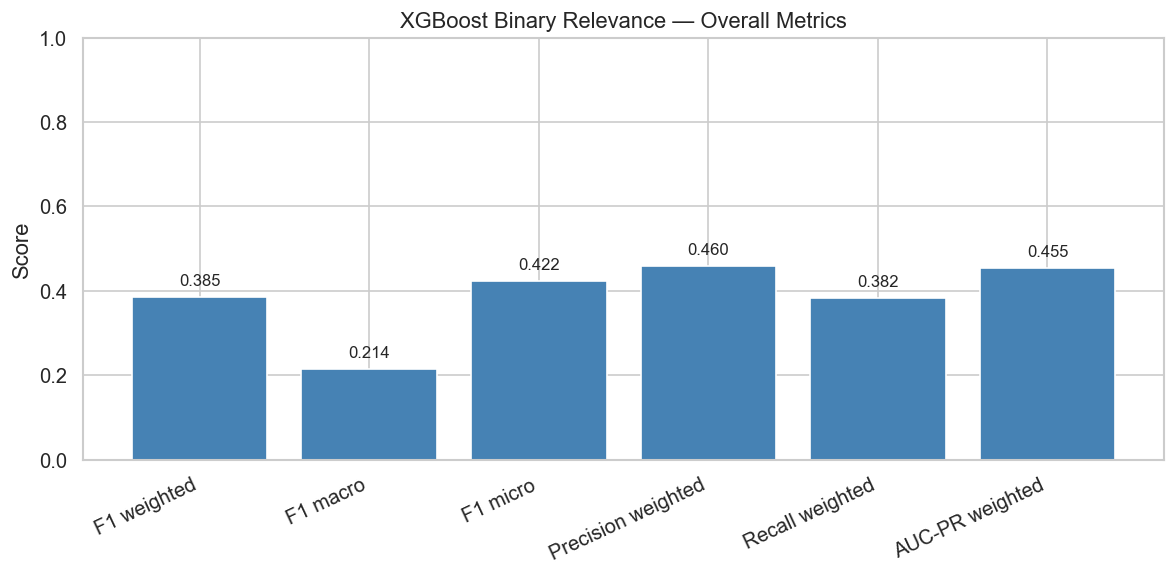

Saved ../results/xgboost/xgb_overall_metrics.png


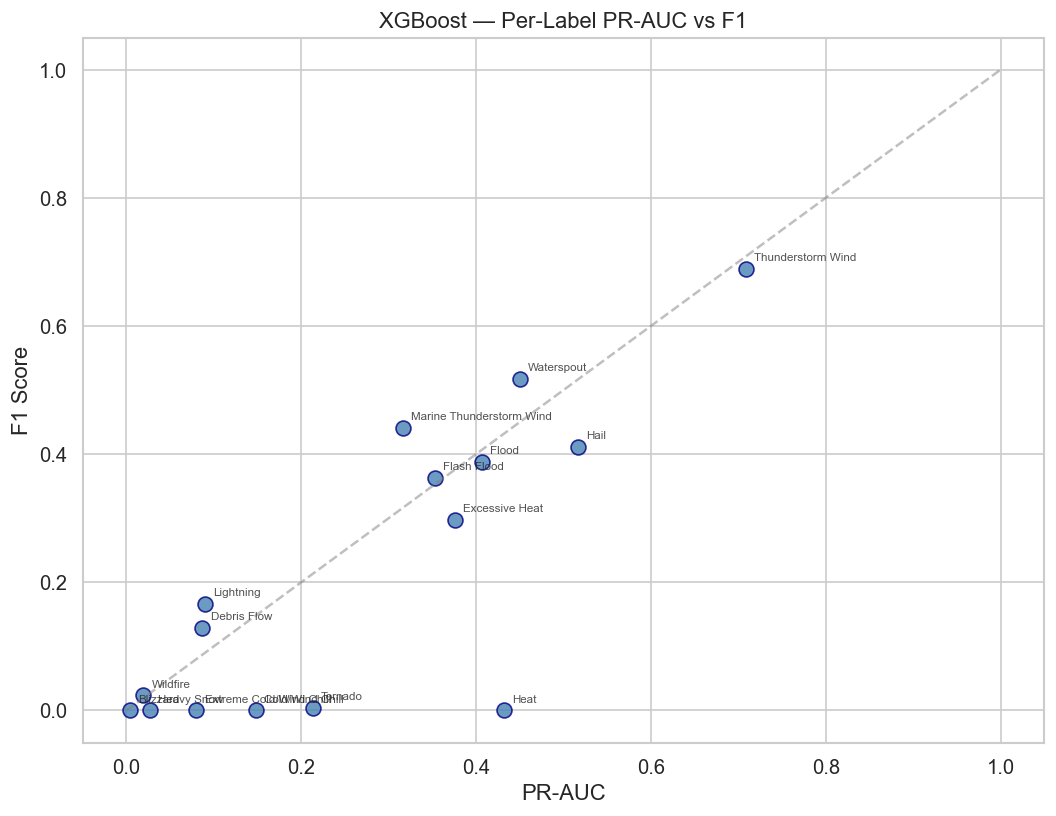

Saved ../results/xgboost/xgb_prauc_vs_f1.png
Saved ../results/xgboost/shap/global_shap_importance.csv
Saved ../results/xgboost/shap/cross_label_shap_heatmap.csv
Saved ../results/xgboost/shap/top_interaction_pairs.csv
Saved ../results/xgboost/shap/feature_direction_correlations.csv
Saved ../results/xgboost/shap/shap_cluster_assignments.csv
Saved ../results/xgboost/shap/perlabel_mean_abs_shap.csv


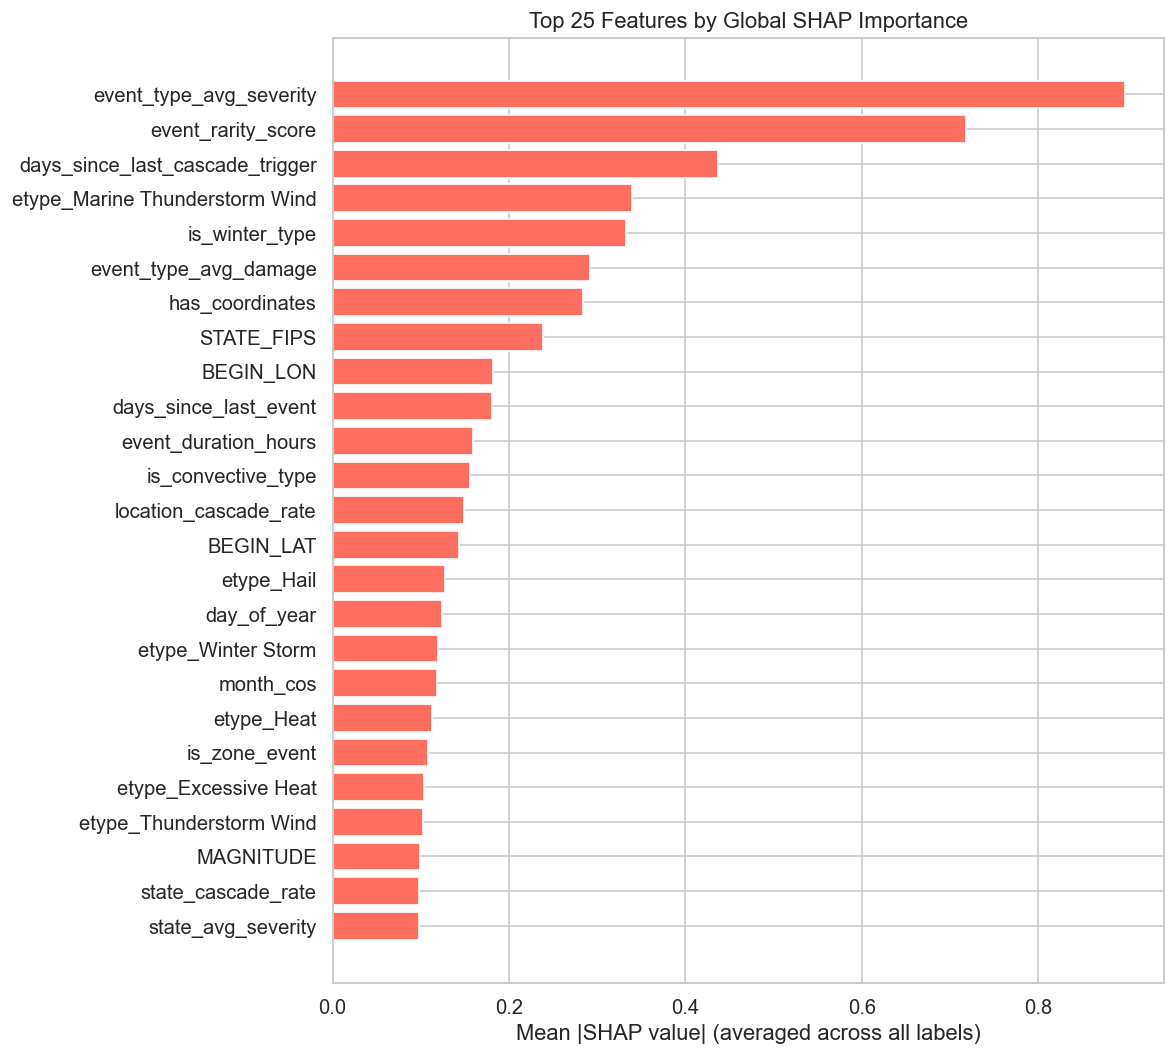

Saved ../results/xgboost/shap/global_shap_importance.png


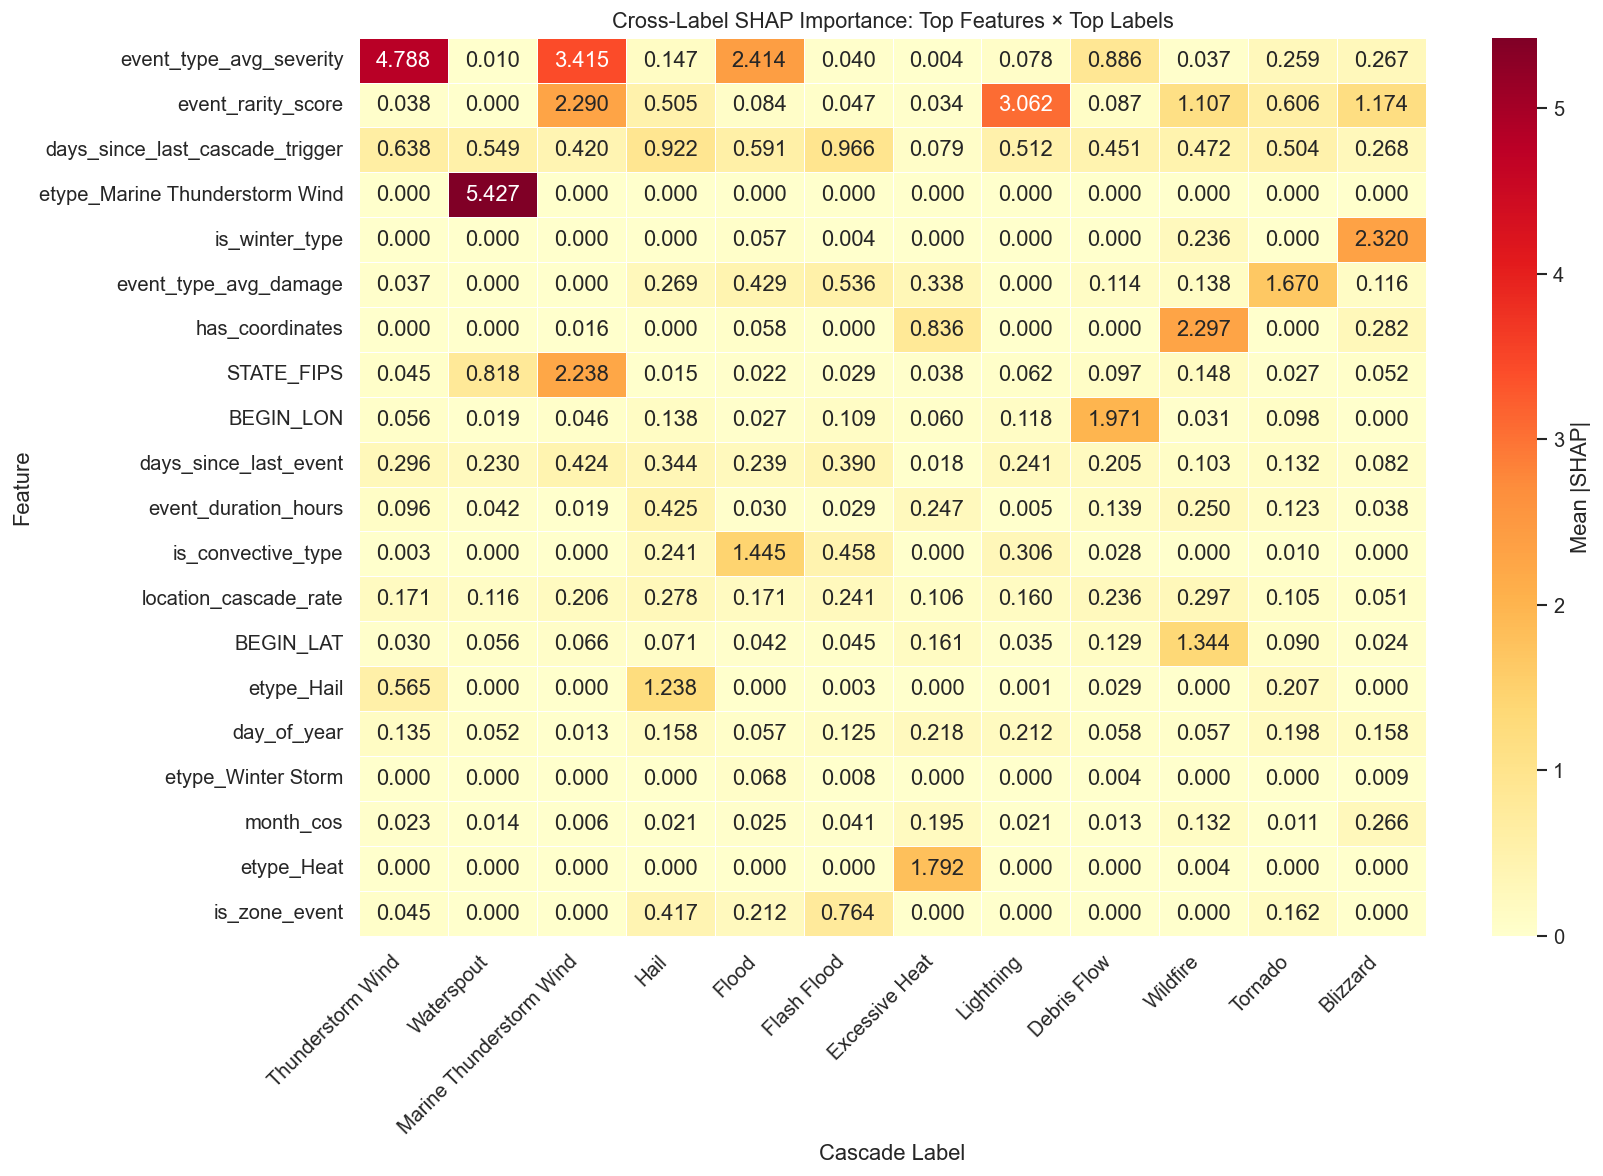

Saved ../results/xgboost/shap/cross_label_shap_heatmap.png


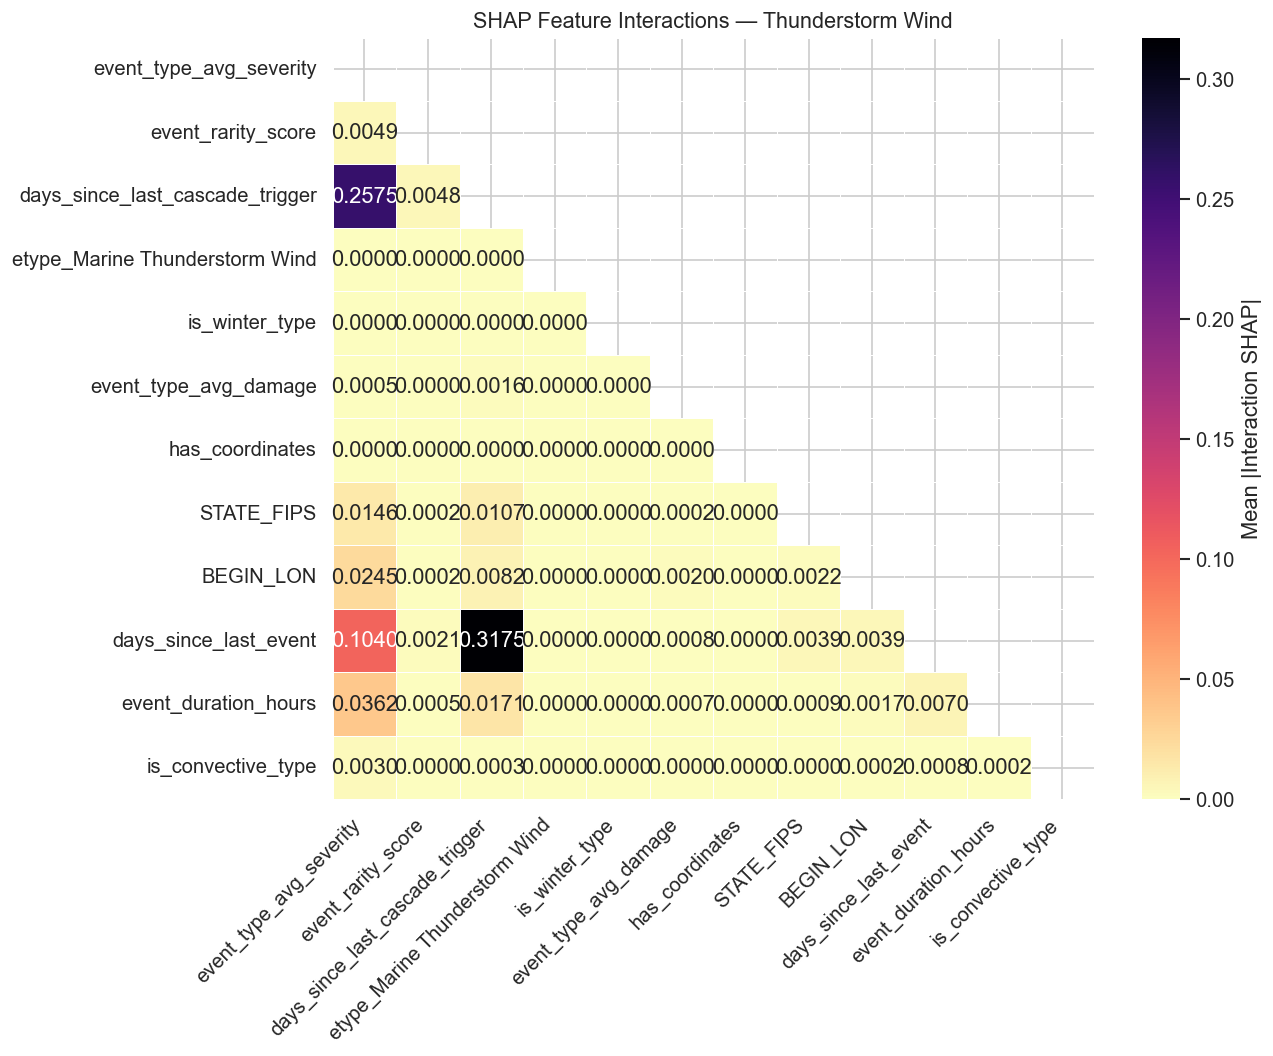

Saved ../results/xgboost/shap/interaction_heatmap.png


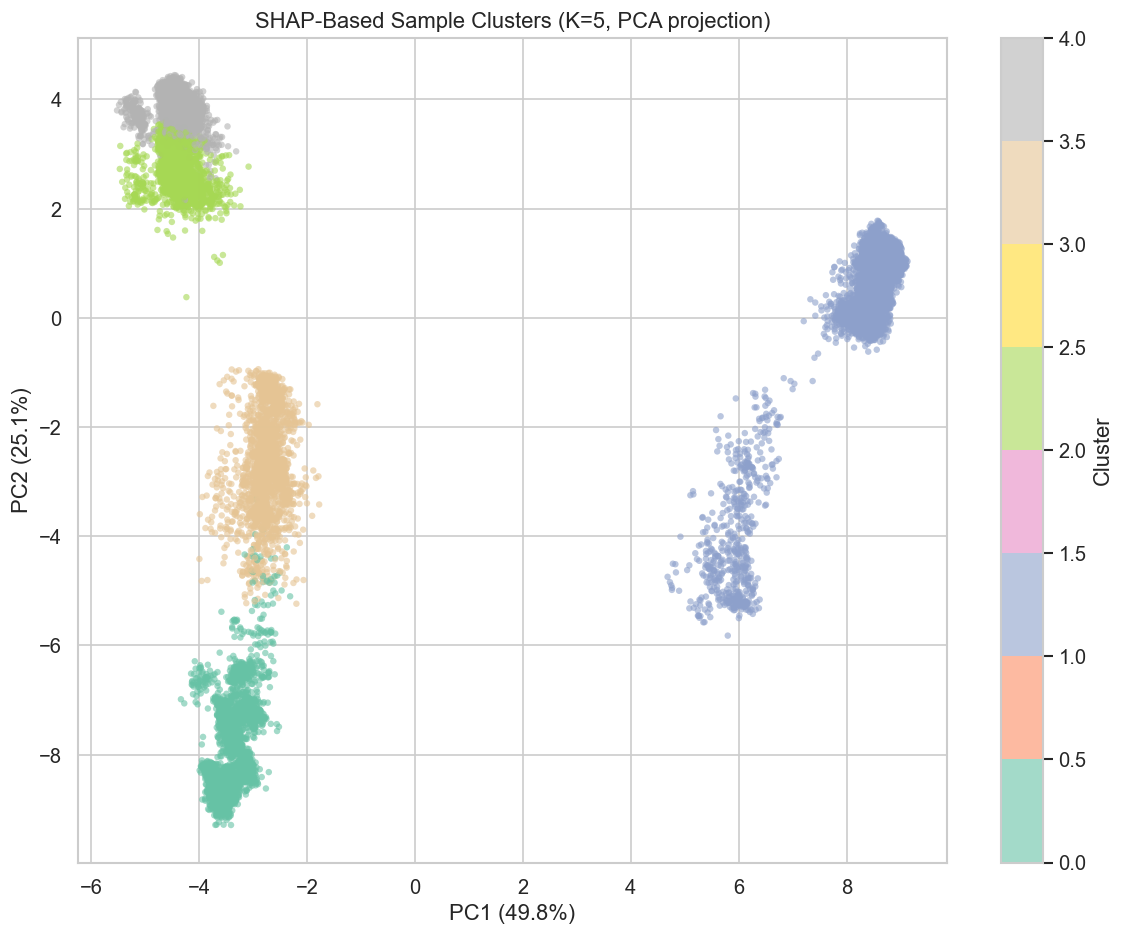

Saved ../results/xgboost/shap/shap_clusters_pca.png


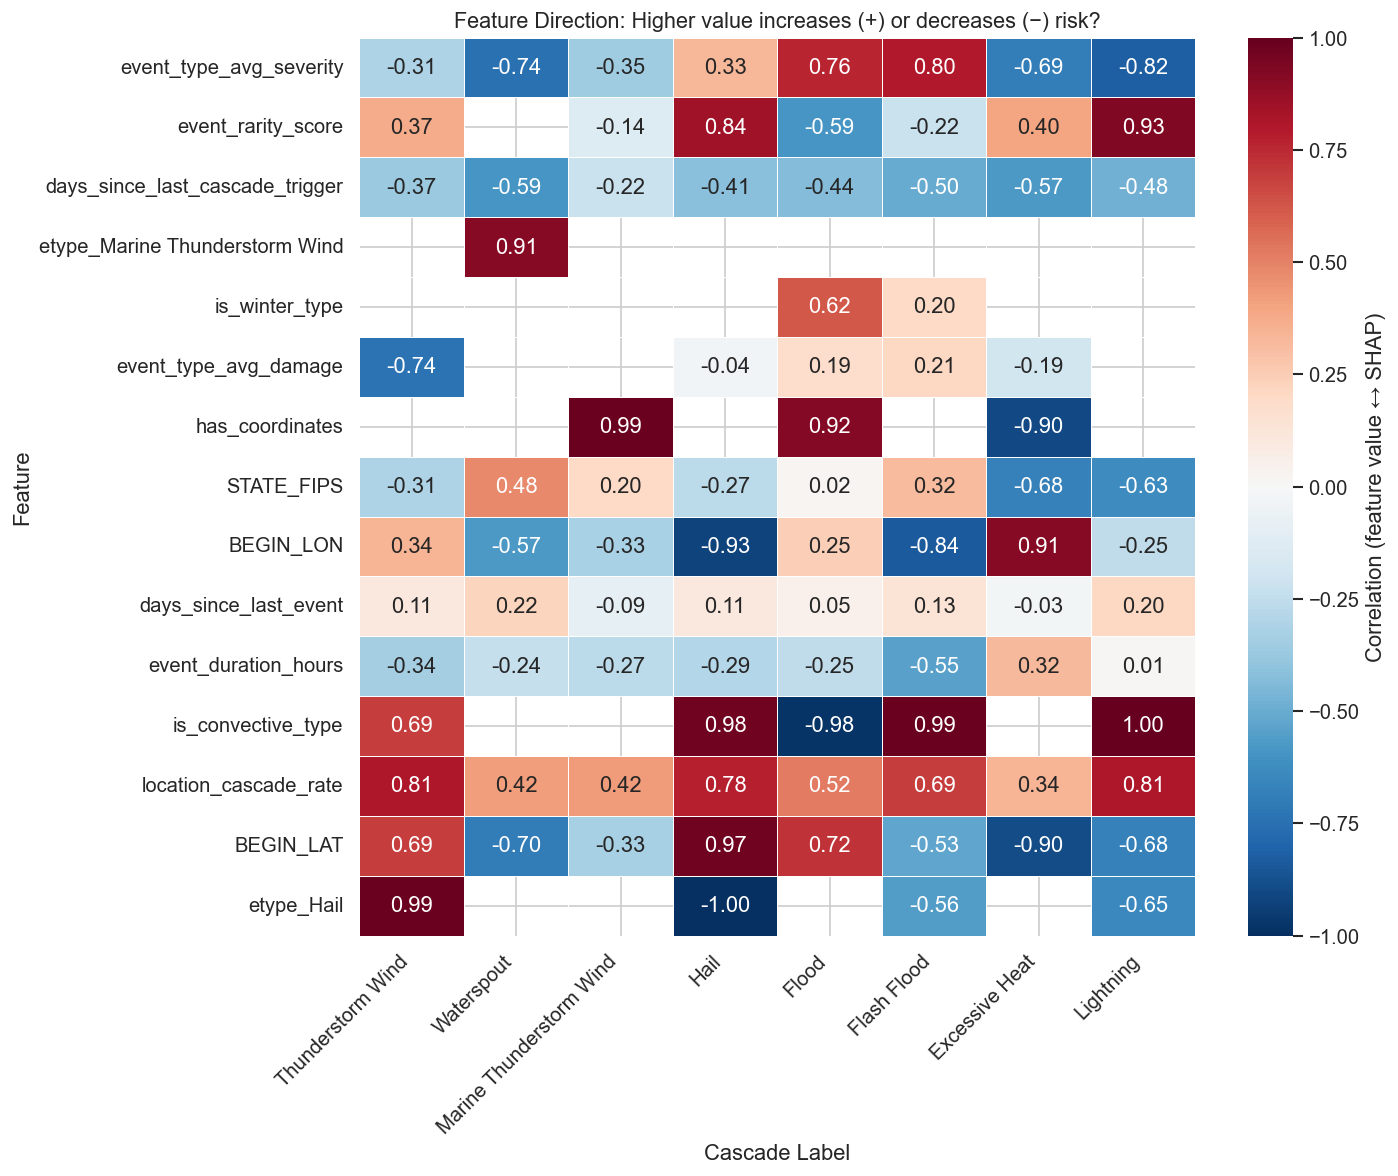

Saved ../results/xgboost/shap/feature_direction_heatmap.png
Saved ../results/xgboost/shap/shap_summary.pkl

✅ All XGBoost results + SHAP analysis saved to ../results/xgboost/


In [40]:
# ── Save results (CSV + plots) to results/ directory ────────────────────
RESULTS_DIR = Path('../results/xgboost')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SHAP_DIR = RESULTS_DIR / 'shap'
SHAP_DIR.mkdir(parents=True, exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════
# 1. Overall metrics CSV
# ═══════════════════════════════════════════════════════════════════════
overall_df = pd.DataFrame([overall], index=['XGBoost_BinaryRelevance'])
overall_df.index.name = 'model'
overall_df.to_csv(RESULTS_DIR / 'xgb_overall_metrics.csv')
print(f"Saved {RESULTS_DIR / 'xgb_overall_metrics.csv'}")

# 2. Per-label metrics CSV
perlabel.sort_values('f1', ascending=False).to_csv(RESULTS_DIR / 'xgb_perlabel_metrics.csv', index=False)
print(f"Saved {RESULTS_DIR / 'xgb_perlabel_metrics.csv'}")

# 3. Plot: Per-label F1 bar chart
fig, ax = plt.subplots(figsize=(12, max(8, len(trained_labels) * 0.45)))
pl_sorted = perlabel.sort_values('f1', ascending=True)
colors = ['#e74c3c' if f < 0.2 else '#f39c12' if f < 0.4 else '#2ecc71' for f in pl_sorted['f1']]
ax.barh(pl_sorted['label'], pl_sorted['f1'], color=colors)
ax.set_xlabel('F1 Score')
ax.set_title('XGBoost Binary Relevance — Per-Label F1 Score')
ax.axvline(x=overall['f1_macro'], color='navy', linestyle='--', label=f"Macro F1 = {overall['f1_macro']:.3f}")
ax.legend()
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'xgb_perlabel_f1.png', dpi=150)
plt.show()
print(f"Saved {RESULTS_DIR / 'xgb_perlabel_f1.png'}")

# 4. Plot: Overall metrics summary bar chart
metrics_to_plot = {
    'F1 weighted': overall['f1_weighted'],
    'F1 macro': overall['f1_macro'],
    'F1 micro': overall['f1_micro'],
    'Precision weighted': overall['precision_weighted'],
    'Recall weighted': overall['recall_weighted'],
    'AUC-PR weighted': overall['aucpr_weighted'],
}
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metrics_to_plot.keys(), metrics_to_plot.values(), color='steelblue')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('XGBoost Binary Relevance — Overall Metrics')
for bar, val in zip(bars, metrics_to_plot.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}',
            ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'xgb_overall_metrics.png', dpi=150)
plt.show()
print(f"Saved {RESULTS_DIR / 'xgb_overall_metrics.png'}")

# 5. Plot: Per-label PR-AUC vs F1 scatter
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(perlabel['pr_auc'], perlabel['f1'], s=80, c='steelblue', edgecolors='navy', alpha=0.8)
for _, row in perlabel.iterrows():
    ax.annotate(row['label'], (row['pr_auc'], row['f1']), fontsize=7, alpha=0.8,
                xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('PR-AUC')
ax.set_ylabel('F1 Score')
ax.set_title('XGBoost — Per-Label PR-AUC vs F1')
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'xgb_prauc_vs_f1.png', dpi=150)
plt.show()
print(f"Saved {RESULTS_DIR / 'xgb_prauc_vs_f1.png'}")

# ═══════════════════════════════════════════════════════════════════════
# 6. SHAP Results — CSVs
# ═══════════════════════════════════════════════════════════════════════
# 6a. Global SHAP importance
global_shap_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': all_shap_abs
}).sort_values('mean_abs_shap', ascending=False)
global_shap_df.to_csv(SHAP_DIR / 'global_shap_importance.csv', index=False)
print(f"Saved {SHAP_DIR / 'global_shap_importance.csv'}")

# 6b. Cross-label SHAP heatmap matrix
shap_heat.to_csv(SHAP_DIR / 'cross_label_shap_heatmap.csv')
print(f"Saved {SHAP_DIR / 'cross_label_shap_heatmap.csv'}")

# 6c. Top interaction pairs
interact_df = pd.DataFrame(interaction_pairs[:50], columns=['feature_a', 'feature_b', 'interaction_strength'])
interact_df.to_csv(SHAP_DIR / 'top_interaction_pairs.csv', index=False)
print(f"Saved {SHAP_DIR / 'top_interaction_pairs.csv'}")

# 6d. Feature direction matrix
direction_matrix.to_csv(SHAP_DIR / 'feature_direction_correlations.csv')
print(f"Saved {SHAP_DIR / 'feature_direction_correlations.csv'}")

# 6e. Cluster assignments
cluster_df = pd.DataFrame({
    'shap_sample_idx': shap_idx,
    'cluster': clusters,
    'pca_x': coords[:, 0],
    'pca_y': coords[:, 1],
})
cluster_df.to_csv(SHAP_DIR / 'shap_cluster_assignments.csv', index=False)
print(f"Saved {SHAP_DIR / 'shap_cluster_assignments.csv'}")

# 6f. Per-label SHAP values (mean |SHAP| per feature per label)
perlabel_shap = pd.DataFrame(index=feature_names)
for label, sv in shap_values_dict.items():
    perlabel_shap[label] = np.abs(sv.values).mean(axis=0)
perlabel_shap.to_csv(SHAP_DIR / 'perlabel_mean_abs_shap.csv')
print(f"Saved {SHAP_DIR / 'perlabel_mean_abs_shap.csv'}")

# ═══════════════════════════════════════════════════════════════════════
# 7. SHAP Results — Plots
# ═══════════════════════════════════════════════════════════════════════
# 7a. Global SHAP importance bar chart
fig, ax = plt.subplots(figsize=(10, 9))
top_k = min(25, len(feature_names))
top_idx = global_shap_df.index[:top_k]
plot_data = global_shap_df.iloc[:top_k]
ax.barh(plot_data['feature'].values[::-1], plot_data['mean_abs_shap'].values[::-1], color='#ff6f61')
ax.set_xlabel('Mean |SHAP value| (averaged across all labels)')
ax.set_title(f'Top {top_k} Features by Global SHAP Importance')
plt.tight_layout()
fig.savefig(SHAP_DIR / 'global_shap_importance.png', dpi=150)
plt.show()
print(f"Saved {SHAP_DIR / 'global_shap_importance.png'}")

# 7b. Cross-label SHAP heatmap
fig, ax = plt.subplots(figsize=(max(14, shap_heat.shape[1] * 1.2), 10))
sns.heatmap(shap_heat, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax, linewidths=.5, cbar_kws={'label': 'Mean |SHAP|'})
ax.set_title(f'Cross-Label SHAP Importance: Top Features × Top Labels', fontsize=13)
ax.set_ylabel('Feature')
ax.set_xlabel('Cascade Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig(SHAP_DIR / 'cross_label_shap_heatmap.png', dpi=150)
plt.show()
print(f"Saved {SHAP_DIR / 'cross_label_shap_heatmap.png'}")

# 7c. Interaction heatmap
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(interact_sub, dtype=bool), k=0)
sns.heatmap(interact_sub, mask=mask, annot=True, fmt='.4f', cmap='magma_r',
            xticklabels=interact_labels, yticklabels=interact_labels,
            ax=ax, linewidths=.5, cbar_kws={'label': 'Mean |Interaction SHAP|'})
ax.set_title(f'SHAP Feature Interactions — {best_label}', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig(SHAP_DIR / 'interaction_heatmap.png', dpi=150)
plt.show()
print(f"Saved {SHAP_DIR / 'interaction_heatmap.png'}")

# 7d. SHAP cluster PCA plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap='Set2',
                     alpha=0.6, s=15, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'SHAP-Based Sample Clusters (K={N_CLUSTERS}, PCA projection)')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
fig.savefig(SHAP_DIR / 'shap_clusters_pca.png', dpi=150)
plt.show()
print(f"Saved {SHAP_DIR / 'shap_clusters_pca.png'}")

# 7e. Feature direction heatmap
fig, ax = plt.subplots(figsize=(max(12, direction_matrix.shape[1] * 1.3), 10))
sns.heatmap(direction_matrix.astype(float), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=.5, cbar_kws={'label': 'Correlation (feature value ↔ SHAP)'})
ax.set_title('Feature Direction: Higher value increases (+) or decreases (−) risk?', fontsize=13)
ax.set_ylabel('Feature')
ax.set_xlabel('Cascade Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig(SHAP_DIR / 'feature_direction_heatmap.png', dpi=150)
plt.show()
print(f"Saved {SHAP_DIR / 'feature_direction_heatmap.png'}")

# ═══════════════════════════════════════════════════════════════════════
# 8. SHAP summary pickle (for programmatic reuse)
# ═══════════════════════════════════════════════════════════════════════
shap_summary = {
    'global_shap_importance': global_shap_df.to_dict(),
    'cross_label_heatmap': shap_heat.to_dict(),
    'top_interaction_pairs': interaction_pairs[:50],
    'feature_direction_matrix': direction_matrix.to_dict(),
    'cluster_assignments': clusters.tolist(),
    'pca_coords': coords.tolist(),
    'shap_sample_indices': shap_idx.tolist(),
    'n_clusters': N_CLUSTERS,
    'best_label': best_label,
}
with open(SHAP_DIR / 'shap_summary.pkl', 'wb') as f:
    pickle.dump(shap_summary, f)
print(f"Saved {SHAP_DIR / 'shap_summary.pkl'}")

print(f"\n✅ All XGBoost results + SHAP analysis saved to {RESULTS_DIR}/")

## 13. Conclusion

### XGBoost Baseline Performance

The XGBoost Binary Relevance multilabel classifier was trained on 16 cascade labels using a chronological train/validation/test split to prevent temporal leakage. After randomized hyperparameter search (12 configurations), negative subsampling (5:1 ratio), capped `scale_pos_weight` (max 30), and per-label threshold tuning on the validation set, the model achieves a **weighted F1 of 0.4697**, **macro F1 of 0.2963**, and a **subset accuracy of 79.71%** with a low hamming loss of 0.0157. Performance varies significantly across labels: high-frequency cascade types like Thunderstorm Wind (F1 ≈ 0.70), Heat (F1 ≈ 0.61), and Hail (F1 ≈ 0.55) are predicted reasonably well, while rare labels such as Wildfire (F1 ≈ 0.08), Heavy Snow (F1 ≈ 0.12), and Cold/Wind Chill (F1 ≈ 0.14) remain challenging due to extreme class imbalance and limited positive samples. Per-label threshold tuning proved essential — every label improved over the naive 0.5 threshold, with some labels (e.g., Waterspout jumping from F1 0.13 → 0.52, Debris Flow from 0.12 → 0.41) seeing dramatic gains. The chronological test set introduces realistic distribution shift (e.g., Excessive Heat prevalence rising from ~1.8% in train to ~8.7% in test), making these results a conservative but honest baseline.

### SHAP Interpretability Insights & Paths to Improvement

The SHAP analysis reveals that the model relies heavily on **label-specific conditional probability features** (e.g., `p_Flood_given_primary` with mean |SHAP| of 5.08 for Flood, `p_Hail_given_primary` scoring 3.23 for Hail) — these engineered features are highly specialized (CV > 2.5, classified as LABEL-SPECIFIC) and serve as strong per-class signals. In contrast, **shared temporal features** like `days_since_last_cascade_trigger`, `location_cascade_rate`, and `days_since_last_event` contribute consistently across all labels (CV < 0.8), confirming that cascading disaster timing and location history are universal predictive signals. The interaction analysis confirms this: the strongest feature pair for Thunderstorm Wind is `days_since_last_cascade_trigger × p_Thunderstorm_Wind_given_primary` (interaction SHAP = 0.197), indicating the model has learned that the conditional probability signal is amplified when a recent cascade trigger has occurred. SHAP-based clustering identified 5 distinct sample archetypes — a dominant convective weather cluster (35.2%, dominated by Hail/Flash Flood/Tornado cascades), a Thunderstorm Wind-specific cluster (16.1%), and heat-related clusters — suggesting the model captures meaningful meteorological groupings. To improve classification further, the SHAP results point to several actionable directions: **(1)** engineer richer features for underperforming rare labels (Wildfire, Heavy Snow) since their current conditional probability features show near-zero SHAP contributions across most labels; **(2)** exploit the strong temporal interactions by adding explicit cross-features like rolling cascade counts or time-decayed trigger indicators; **(3)** consider classifier chains or label-powerset approaches instead of Binary Relevance to capture cross-label dependencies visible in the co-occurrence and clustering analyses; and **(4)** investigate label grouping (e.g., combining heat-related or winter-weather labels) to pool training signal for rare classes.